# 核心区域

In [45]:
# =========================================================
# Queen + Regions + 3x3(king) solver  (with step logging)
# Optimizations:
# 1) Merge consecutive Propagation steps
# 2) show_steps: removed list grouped by row (human-friendly)
# 3) Difficulty calculator (score_from_steps_v2)
# 4) Bulk run first 100 levels + analyze level 18
# =========================================================

import json
import copy
import math
import collections
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Set, Optional
from itertools import combinations

# =========================================================
# Step
# =========================================================
@dataclass
class Step:
    tech: str
    desc: str
    impact: int = 1
    placed: Optional[Tuple[int, int]] = None
    removed: List[Tuple[int, int]] = field(default_factory=list)


# =========================================================
# State
# =========================================================
class State:
    def __init__(self, H: int, W: int, regions: List[List[int]]):
        self.H = H
        self.W = W
        self.regions = regions  # regions[r][c]

        self.candidates: Set[Tuple[int, int]] = {(r, c) for r in range(H) for c in range(W)}
        self.queens: Set[Tuple[int, int]] = set()

        self.placed_rows: Set[int] = set()
        self.placed_cols: Set[int] = set()
        self.placed_colors: Set[int] = set()

    def all_colors(self) -> Set[int]:
        return {self.regions[r][c] for r in range(self.H) for c in range(self.W)}


# =========================================================
# King helpers  (3x3 neighborhood around a cell, excluding itself)
# =========================================================
def king_neighbors(r: int, c: int, H: int, W: int):
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue
            rr, cc = r + dr, c + dc
            if 0 <= rr < H and 0 <= cc < W:
                yield rr, cc


def king_box_cells_including_center(r: int, c: int, H: int, W: int) -> Set[Tuple[int, int]]:
    cells = {(r, c)}
    for rr, cc in king_neighbors(r, c, H, W):
        cells.add((rr, cc))
    return cells


# =========================================================
# Core operations
# =========================================================
def place_queen(state: State, r: int, c: int) -> List[Tuple[int, int]]:
    """Place a queen and remove all conflicting candidates. Returns removed list."""
    if r in state.placed_rows:
        raise ValueError("Row conflict")
    if c in state.placed_cols:
        raise ValueError("Col conflict")
    col = state.regions[r][c]
    if col in state.placed_colors:
        raise ValueError("Color conflict")
    # also cannot be adjacent to existing queens
    if any((rr, cc) in state.queens for rr, cc in king_neighbors(r, c, state.H, state.W)):
        raise ValueError("King-box conflict")

    state.queens.add((r, c))
    state.placed_rows.add(r)
    state.placed_cols.add(c)
    state.placed_colors.add(col)

    remove = set()
    for rr, cc in state.candidates:
        if rr == r or cc == c:
            remove.add((rr, cc))
        elif (rr, cc) in king_neighbors(r, c, state.H, state.W):
            remove.add((rr, cc))
        elif state.regions[rr][cc] == col:
            remove.add((rr, cc))

    removed_list = sorted(remove)
    state.candidates -= remove
    # ensure placed cell not a candidate
    if (r, c) in state.candidates:
        state.candidates.remove((r, c))
        removed_list.append((r, c))
        removed_list = sorted(set(removed_list))

    return removed_list


# =========================================================
# Propagation (basic hard-constraint pruning) + step logging
# =========================================================
def propagate(state: State, steps: Optional[List[Step]] = None) -> bool:
    """
    Repeatedly removes impossible candidates due to current placed queens/rows/cols/colors/king-box.
    Returns True if anything changed.
    """
    changed_any = False
    while True:
        removed = []
        for (r, c) in list(state.candidates):
            # already a queen -> shouldn't be a candidate
            if (r, c) in state.queens:
                removed.append((r, c))
                continue

            # row / col / color already used
            if (r in state.placed_rows) or (c in state.placed_cols) or (state.regions[r][c] in state.placed_colors):
                removed.append((r, c))
                continue

            # 3x3 constraint: if any queen in its king-neighborhood, can't place here
            if any((rr, cc) in state.queens for rr, cc in king_neighbors(r, c, state.H, state.W)):
                removed.append((r, c))
                continue

        if not removed:
            break

        removed_set = set(removed)
        state.candidates -= removed_set
        changed_any = True

        if steps is not None:
            steps.append(
                Step(
                    tech="Propagation",
                    desc=f"Prune by hard constraints",
                    impact=len(removed_set),
                    removed=sorted(removed_set),
                )
            )

    return changed_any


# =========================================================
# Forced move
# =========================================================
def forced_move_once(state: State, steps: List[Step]) -> bool:
    # Only keep forced move by Color:
    # If an unplaced color has exactly one candidate cell, we must place there.
    colors_in_cand = {state.regions[r][c] for r, c in state.candidates}
    for col in colors_in_cand:
        if col in state.placed_colors:
            continue
        cells = [(r, c) for r, c in state.candidates if state.regions[r][c] == col]
        if len(cells) == 1:
            (rr, cc) = cells[0]
            removed = place_queen(state, rr, cc)
            steps.append(
                Step(
                    "ForcedMove",
                    f"Color {col} has only one cell -> place ({rr},{cc})",
                    impact=max(1, len(removed)),
                    placed=(rr, cc),
                    removed=removed,
                )
            )
            return True

    return False


# =========================================================
# Color → Row / Col Set Lock
# =========================================================
def apply_color_to_row_set_lock(state: State, steps: List[Step], k_max=2) -> bool:
    color_rows = collections.defaultdict(set)
    for r, c in state.candidates:
        color_rows[state.regions[r][c]].add(r)

    keys = list(color_rows.keys())
    for k in range(1, k_max + 1):
        for colors in combinations(keys, k):
            rows = set().union(*(color_rows[c] for c in colors))
            if len(rows) != k:
                continue

            removed = []
            for (r, c) in list(state.candidates):
                if r in rows and state.regions[r][c] not in colors:
                    removed.append((r, c))

            if removed:
                removed_set = set(removed)
                state.candidates -= removed_set
                steps.append(
                    Step(
                        tech=f"ColorToRowSetLock{k}",
                        desc=f"Colors {colors} are confined to rows {sorted(rows)} -> remove other colors from these rows",
                        impact=len(removed_set),
                        removed=sorted(removed_set),
                    )
                )
                return True
    return False


def apply_color_to_col_set_lock(state: State, steps: List[Step], k_max=2) -> bool:
    color_cols = collections.defaultdict(set)
    for r, c in state.candidates:
        color_cols[state.regions[r][c]].add(c)

    keys = list(color_cols.keys())
    for k in range(1, k_max + 1):
        for colors in combinations(keys, k):
            cols = set().union(*(color_cols[c] for c in colors))
            if len(cols) != k:
                continue

            removed = []
            for (r, c) in list(state.candidates):
                if c in cols and state.regions[r][c] not in colors:
                    removed.append((r, c))

            if removed:
                removed_set = set(removed)
                state.candidates -= removed_set
                steps.append(
                    Step(
                        tech=f"ColorToColSetLock{k}",
                        desc=f"Colors {colors} are confined to cols {sorted(cols)} -> remove other colors from these cols",
                        impact=len(removed_set),
                        removed=sorted(removed_set),
                    )
                )
                return True
    return False
# =========================================================
# （Row/Col → Color Set Lock）
# 某 k 行/列的候选格只包含 k 种颜色 ⇒ 这些颜色在其它行/列的候选格可删
# =========================================================
import collections
from itertools import combinations
from typing import List

# 技能（Row/Col → Color Set Lock）依赖的关键前提是：
# 棋盘是 n×n
# 颜色集合恰好是 n 种（并且每种颜色最终要放 1 个皇后）
# 目标行/列集合里必须是 k 行/列 → k 个皇后（也就是这些行/列还没放皇后，且每行/列最终放 1 个）
#✅“能不能用该技能”的 gate：确保只有在 n×n 且 n 色 的棋盘上，这个技能才可能触发。
def can_use_rowcol_to_color_set_lock(state: State) -> bool:
    # n×n
    if state.H != state.W:
        return False
    n = state.H
    # 颜色数量必须是 n
    all_colors = state.all_colors()
    if len(all_colors) != n:
        return False
    # （可选但推荐）如果你的规则是“每种颜色恰好一个皇后”
    # 那么已放颜色不应超过 n，通常 propagate 会保证
    if len(state.placed_colors) > n:
        return False
    return True


#Row → Color Set Lock（你描述的“k行只含k色 ⇒ 删其它行的这k色”）
def apply_row_to_color_set_lock(state: State, steps: List[Step], k_max=2) -> bool:
    if not can_use_rowcol_to_color_set_lock(state):
        return False

    row_colors = collections.defaultdict(set)
    for r, c in state.candidates:
        if r in state.placed_rows:
            continue
        row_colors[r].add(state.regions[r][c])

    rows = [r for r in row_colors.keys() if row_colors[r]]
    if not rows:
        return False

    for k in range(1, k_max + 1):
        for R in combinations(rows, k):
            colors = set().union(*(row_colors[r] for r in R))
            if len(colors) != k:
                continue

            removed = []
            Rset = set(R)
            for (r, c) in list(state.candidates):
                if r in Rset:
                    continue
                if state.regions[r][c] in colors:
                    removed.append((r, c))

            if removed:
                removed_set = set(removed)
                state.candidates -= removed_set
                steps.append(
                    Step(
                        tech=f"RowToColorSetLock{k}",
                        desc=(
                            f"Rows {sorted(Rset)} candidates use only colors {sorted(colors)} "
                            f"-> remove these colors from other rows"
                        ),
                        impact=len(removed_set),
                        removed=sorted(removed_set),
                    )
                )
                return True
    return False


#Col → Color Set Lock（“k列只含k色 ⇒ 删其它列的这k色”）
def apply_col_to_color_set_lock(state: State, steps: List[Step], k_max=2) -> bool:
    if not can_use_rowcol_to_color_set_lock(state):
        return False

    col_colors = collections.defaultdict(set)
    for r, c in state.candidates:
        if c in state.placed_cols:
            continue
        col_colors[c].add(state.regions[r][c])

    cols = [c for c in col_colors.keys() if col_colors[c]]
    if not cols:
        return False

    for k in range(1, k_max + 1):
        for C in combinations(cols, k):
            colors = set().union(*(col_colors[c] for c in C))
            if len(colors) != k:
                continue

            removed = []
            Cset = set(C)
            for (r, c) in list(state.candidates):
                if c in Cset:
                    continue
                if state.regions[r][c] in colors:
                    removed.append((r, c))

            if removed:
                removed_set = set(removed)
                state.candidates -= removed_set
                steps.append(
                    Step(
                        tech=f"ColToColorSetLock{k}",
                        desc=(
                            f"Cols {sorted(Cset)} candidates use only colors {sorted(colors)} "
                            f"-> remove these colors from other cols"
                        ),
                        impact=len(removed_set),
                        removed=sorted(removed_set),
                    )
                )
                return True
    return False

# =========================================================
# KingBoxExclusion 
# 若假设在 (r,c) 放 queen，则其九宫格(含中心)全被排除
# 导致某种颜色在剩余棋盘中没有任何可放位置 => (r,c) 不能放。
# =========================================================
def king_box_exclusion(state: State, steps):
    """
    KingBoxExclusion (pure):
    假设在 (r,c) 放 queen，仅因 3x3 king box 被封，
    导致某个“尚未放置的颜色”在整个棋盘中无任何合法格子 => (r,c) 不能放。

    修复点：若 color == col_here（落子格自己的颜色），则该颜色在假设下已被放置，不应拿来做“无解”检查。
    """
    for (r, c) in list(state.candidates):
        blocked = set(king_neighbors(r, c, state.H, state.W))
        blocked.add((r, c))

        col_here = state.regions[r][c]

        for color in set(state.regions[rr][cc] for (rr, cc) in state.candidates):
            if color in state.placed_colors:
                continue
            if color == col_here:   # ✅关键修复
                continue

            ok = False
            for (rr, cc) in state.candidates:
                if state.regions[rr][cc] == color and (rr, cc) not in blocked:
                    ok = True
                    break

            if not ok:
                state.candidates.remove((r, c))
                steps.append(
                    Step(
                        "KingBoxExclusion",
                        f"({r},{c}) king-box blocks color {color}",
                        impact=1,
                        removed=[(r, c)],
                    )
                )
                return True

    return False



# =========================================================
# LocalColorBlockContradiction (更一般：含行列+九宫格，检查任意颜色无解)
# =========================================================
def local_color_block_contradiction(state: State, steps: List[Step]) -> bool:
    colors_unplaced = state.all_colors() - state.placed_colors
    for (r, c) in list(state.candidates):
        blocked = set()
        blocked.add((r, c))
        blocked |= {(r, cc) for cc in range(state.W)}
        blocked |= {(rr, c) for rr in range(state.H)}
        blocked |= set(king_neighbors(r, c, state.H, state.W))

        col_here = state.regions[r][c]
        blocked |= {(rr, cc) for (rr, cc) in state.candidates if state.regions[rr][cc] == col_here}

        for col in colors_unplaced:
            if col == col_here:
                continue
            ok = False
            for (rr, cc) in state.candidates:
                if state.regions[rr][cc] == col and (rr, cc) not in blocked:
                    ok = True
                    break
            if not ok:
                state.candidates.remove((r, c))
                steps.append(
                    Step(
                        tech="LocalColorBlockContradiction",
                        desc=f"({r},{c}) would block all options for color {col}",
                        impact=1,
                        removed=[(r, c)],
                    )
                )
                return True
    return False


# =========================================================
# Eliminate by full contradiction
# =========================================================
def eliminate_by_contradiction(state: State, steps: List[Step]) -> bool:
    for (r, c) in list(state.candidates):
        test = copy.deepcopy(state)
        try:
            place_queen(test, r, c)
            propagate(test, steps=None)
            # force chain
            while True:
                moved = forced_move_once(test, steps=[])
                if not moved:
                    break
                propagate(test, steps=None)

            # quick feasibility: every unplaced color must still have >=1 candidate
            colors_unplaced = test.all_colors() - test.placed_colors
            for col in colors_unplaced:
                if not any(test.regions[rr][cc] == col for (rr, cc) in test.candidates):
                    raise ValueError("Dead end: color has no candidates")

        except Exception:
            state.candidates.remove((r, c))
            steps.append(
                Step(
                    tech="EliminateByContradiction",
                    desc=f"Assume queen at ({r},{c}) -> contradiction/dead end",
                    impact=1,
                    removed=[(r, c)],
                )
            )
            return True
    return False

def eliminate_by_contradiction_gated(
    state: "State",
    steps: list,
    *,
    max_candidates=120,
    max_unplaced_colors=6,
) -> bool:
    # 候选太多时，矛盾法会爆炸：直接跳过，不改变正确性，只是少做工作
    if len(state.candidates) > max_candidates:
        return False
    unplaced = state.all_colors() - state.placed_colors
    if len(unplaced) > max_unplaced_colors:
        return False

    # 满足门槛才允许用重锤
    return eliminate_by_contradiction(state, steps)
def _popcount(x: int) -> int:
    return x.bit_count()

# =========================================================
# Row/Col Must Have a Queen  (Forced by Row/Col)
# 技能1：一行/列中必有一个 Queen
# - 若某未放置的行/列中只剩 1 个候选格 -> 必须放这里
# =========================================================


def can_use_rowcol_must_have_queen(state: State) -> bool:
    # 仅在 n×n 且 颜色数 = n 时启用（确保每行/列最终都必须放 1 个）
    if state.H != state.W:
        return False
    n = state.H
    if len(state.all_colors()) != n:
        return False
    return True


def forced_move_by_rowcol_once(state: State, steps: List[Step]) -> bool:
    """
    若某未放置的行/列中只剩一个候选格 -> 必须在该格放 Queen
    返回 True 表示已执行一次放置（与你 forced_move_once 一致：一次只做一个）
    """
    if not can_use_rowcol_must_have_queen(state):
        return False

    H, W = state.H, state.W

    # ---- Row forced ----
    for r in range(H):
        if r in state.placed_rows:
            continue
        cells = [(rr, cc) for (rr, cc) in state.candidates if rr == r]
        if len(cells) == 1:
            (rr, cc) = cells[0]
            removed = place_queen(state, rr, cc)
            steps.append(
                Step(
                    tech="ForcedMoveRowCol",
                    desc=f"Row {r} has only one candidate -> place ({rr},{cc})",
                    impact=max(1, len(removed)),
                    placed=(rr, cc),
                    removed=removed,
                )
            )
            return True

    # ---- Col forced ----
    for c in range(W):
        if c in state.placed_cols:
            continue
        cells = [(rr, cc) for (rr, cc) in state.candidates if cc == c]
        if len(cells) == 1:
            (rr, cc) = cells[0]
            removed = place_queen(state, rr, cc)
            steps.append(
                Step(
                    tech="ForcedMoveRowCol",
                    desc=f"Col {c} has only one candidate -> place ({rr},{cc})",
                    impact=max(1, len(removed)),
                    placed=(rr, cc),
                    removed=removed,
                )
            )
            return True

    return False

# =========================================================
# 做这个“轻量假设排除”时，只排同行/同列/九宫格，不做同色排除
# =========================================================

import copy
from typing import List

import copy
from typing import List, Tuple, Set

def _place_queen_rowcol_king_only(test: State, r: int, c: int) -> None:
    """
    只模拟：落子后产生的 行/列/九宫格(相邻) 排除
    不做同色排除；不修改 placed_colors
    """
    H, W = test.H, test.W

    # 基本合法性检查（保持与硬规则一致，但不涉及颜色）
    if r in test.placed_rows:
        raise ValueError("Row conflict")
    if c in test.placed_cols:
        raise ValueError("Col conflict")
    if (r, c) in test.queens:
        raise ValueError("Already a queen here")
    if any((rr, cc) in test.queens for rr, cc in king_neighbors(r, c, H, W)):
        raise ValueError("King-box conflict")

    # 放置 queen（仅行/列/九宫格意义上）
    test.queens.add((r, c))
    test.placed_rows.add(r)
    test.placed_cols.add(c)

    # 移除候选：同行、同列、九宫格相邻、以及自身
    remove = set()
    for (rr, cc) in test.candidates:
        if rr == r or cc == c:
            remove.add((rr, cc))
        elif (rr, cc) in king_neighbors(r, c, H, W):
            remove.add((rr, cc))
    remove.add((r, c))

    test.candidates.difference_update(remove)

def rowcol_no_place_exclusion_light_no_color(state: State, steps: List[Step]) -> bool:
    """
    轻量版（无同色排除）：
    对每个候选 (r,c)：
      - 深拷贝 state
      - 只做 行/列/九宫格(相邻) 的假设落子排除
      - 若导致某个未放置行/列没有任何候选格 -> (r,c) 不可能放，移除
    """
    if not can_use_rowcol_must_have_queen(state):
        return False

    H, W = state.H, state.W

    for (r, c) in list(state.candidates):
        test = copy.deepcopy(state)

        # 假设落子（不做同色排除）
        try:
            _place_queen_rowcol_king_only(test, r, c)
        except Exception:
            # 这格在“行列九宫格规则”下就不合法（通常说明 candidates 脏了）
            if (r, c) in state.candidates:
                state.candidates.remove((r, c))
                steps.append(
                    Step(
                        tech="RowColNoPlaceExclusion_Light_NoColor",
                        desc=f"({r},{c}) is not placeable by row/col/king constraints",
                        impact=1,
                        removed=[(r, c)],
                    )
                )
                return True
            continue

        # 检查未放置行是否至少还有一个候选
        for rr in range(H):
            if rr in test.placed_rows:
                continue
            if not any(r2 == rr for (r2, c2) in test.candidates):
                if (r, c) in state.candidates:
                    state.candidates.remove((r, c))
                    steps.append(
                        Step(
                            tech="RowColNoPlaceExclusion_Light_NoColor",
                            desc=f"Assume queen at ({r},{c}) -> row {rr} has no candidate cells (row/col/king only)",
                            impact=1,
                            removed=[(r, c)],
                        )
                    )
                    return True

        # 检查未放置列是否至少还有一个候选
        for cc in range(W):
            if cc in test.placed_cols:
                continue
            if not any(c2 == cc for (r2, c2) in test.candidates):
                if (r, c) in state.candidates:
                    state.candidates.remove((r, c))
                    steps.append(
                        Step(
                            tech="RowColNoPlaceExclusion_Light_NoColor",
                            desc=f"Assume queen at ({r},{c}) -> col {cc} has no candidate cells (row/col/king only)",
                            impact=1,
                            removed=[(r, c)],
                        )
                    )
                    return True

    return False


# =========================================================
# Row/Col No-Place Exclusion (Lightweight contradiction)
# 技能2：假设某候选格放 Queen -> 导致某行/列没有任何位置可放 Queen
# -> 该格不可能放 Queen（排除该候选格）
# =========================================================

def rowcol_no_place_exclusion(state: State, steps: List[Step]) -> bool:
    """
    对每个候选格 (r,c)：
    假设放 Queen -> place_queen + propagate
    若出现：
      - 某个未放置的行没有任何候选格
      - 或某个未放置的列没有任何候选格
    则 (r,c) 不可能放，直接从原 state.candidates 移除
    （这是比 eliminate_by_contradiction 更轻量的“行列可行性矛盾检查”）
    """
    if not can_use_rowcol_must_have_queen(state):
        return False

    H, W = state.H, state.W

    # 为了快一点：把候选列表固定下来迭代
    for (r, c) in list(state.candidates):
        test = copy.deepcopy(state)
        try:
            place_queen(test, r, c)
            propagate(test, steps=None)

            # 检查未放置行是否仍至少有一个候选
            for rr in range(H):
                if rr in test.placed_rows:
                    continue
                if not any(r2 == rr for (r2, c2) in test.candidates):
                    raise ValueError(f"Row {rr} has no candidates")

            # 检查未放置列是否仍至少有一个候选
            for cc in range(W):
                if cc in test.placed_cols:
                    continue
                if not any(c2 == cc for (r2, c2) in test.candidates):
                    raise ValueError(f"Col {cc} has no candidates")

        except Exception as e:
            # 出现行/列无候选 -> 原格子 (r,c) 不能放
            if (r, c) in state.candidates:
                state.candidates.remove((r, c))
                steps.append(
                    Step(
                        tech="RowColNoPlaceExclusion",
                        desc=f"Assume queen at ({r},{c}) -> some row/col has no place for a queen",
                        impact=1,
                        removed=[(r, c)],
                    )
                )
                return True

    return False


# =========================================================
# Solver pipeline
# =========================================================
# LOGIC_PIPELINE = [
#     forced_move_once,
#     lambda s, st: apply_color_to_row_set_lock(s, st, 2),
#     lambda s, st: apply_color_to_col_set_lock(s, st, 2),
#     king_box_exclusion,
#     lambda s, st: apply_color_to_row_set_lock(s, st, 3),
#     lambda s, st: apply_color_to_col_set_lock(s, st, 3),
#     local_color_block_contradiction,
#     lambda s, st: apply_color_to_row_set_lock(s, st, 5),
#     lambda s, st: apply_color_to_col_set_lock(s, st, 5),
#     eliminate_by_contradiction,
# ]

LOGIC_PIPELINE = [
    ("ForcedMoveOnce", forced_move_once),
    ("ColorToRowSetLock2", lambda s, st: apply_color_to_row_set_lock(s, st, 2)),
    ("ColorToColSetLock2", lambda s, st: apply_color_to_col_set_lock(s, st, 2)),
    ("KingBoxExclusion", king_box_exclusion),
    # ✅ 新增：行/列只有一个候选 -> 必放
    ("ForcedMoveRowCol", forced_move_by_rowcol_once),
    ("RowToColorSetLock2", lambda s, st: apply_row_to_color_set_lock(s, st, 2)),
    ("ColToColorSetLock2", lambda s, st: apply_col_to_color_set_lock(s, st, 2)),
    ("ColorToRowSetLock3", lambda s, st: apply_color_to_row_set_lock(s, st, 3)),
    ("ColorToColSetLock3", lambda s, st: apply_color_to_col_set_lock(s, st, 3)),
    ("RowToColorSetLock3", lambda s, st: apply_row_to_color_set_lock(s, st, 3)),
    ("ColToColorSetLock3", lambda s, st: apply_col_to_color_set_lock(s, st, 3)),

    ("LocalColorBlockContradiction", local_color_block_contradiction),

    ("ColorToRowSetLock5", lambda s, st: apply_color_to_row_set_lock(s, st, 5)),
    ("ColorToColSetLock5", lambda s, st: apply_color_to_col_set_lock(s, st, 5)),
    ("RowToColorSetLock5", lambda s, st: apply_row_to_color_set_lock(s, st, 5)),
    ("ColToColorSetLock5", lambda s, st: apply_col_to_color_set_lock(s, st, 5)),

    # ✅ 新增：轻量矛盾排除（假设落子 -> 某行/列无候选）
#     ("RowColNoPlaceExclusionLight", rowcol_no_place_exclusion_light_no_color),
#     ("RowColNoPlaceExclusion", rowcol_no_place_exclusion),

    ("EliminateByContradiction", eliminate_by_contradiction),
    # 或者你想继续用 gated 版本就替换成下面这行
    # ("EliminateByContradiction", eliminate_by_contradiction_gated),
]


# =========================================================
# Weights
# =========================================================
TECH_WEIGHTS = {
    "Propagation": 0.4,

    "ColorToRowSetLock1": 0.8,
    "ColorToRowSetLock2": 1.2,
    "ColorToRowSetLock3": 1.8,
    "ColorToRowSetLock4": 2.0,
    "ColorToRowSetLock5": 3,

    "ColorToColSetLock1": 0.8,
    "ColorToColSetLock2": 1.2,
    "ColorToColSetLock3": 1.8,
    "ColorToColSetLock4": 2.0,
    "ColorToColSetLock5": 3,

    "KingBoxExclusion": 1,

    "RowToColorSetLock1": 1,
    "RowToColorSetLock2": 1.8,
    "RowToColorSetLock3": 2.5,
    "RowToColorSetLock4": 3,
    "RowToColorSetLock5": 4,

    "ColToColorSetLock1": 1,
    "ColToColorSetLock2": 1.8,
    "ColToColorSetLock3": 2.5,
    "ColToColorSetLock4": 3,
    "ColToColorSetLock5": 4,

    "LocalColorBlockContradiction": 5.0,

    "ForcedMove": 0.8,

    # ✅ 新增
    "ForcedMoveRowCol": 1,
    "RowColNoPlaceExclusionLight": 7.5,
    "RowColNoPlaceExclusion": 16,

    "EliminateByContradiction": 20.0,
    "Guess": 20.0,
}

ADVANCED_TECH_THRESHOLD = 5.0  # 用于“高级技能”统计（>=5 认为高级）

# =========================================================
# Solved check (修正版)
# - 每个颜色恰好 1 个 queen
# - 每行/列最多 1（实际上放满颜色数时就是恰好若颜色数==queen数）
# - 任意九宫格(king邻域)最多 1
# =========================================================
def is_solved(state: State) -> bool:
    all_colors = state.all_colors()

    # must place exactly 1 queen per color
    if state.placed_colors != all_colors:
        return False
    if len(state.queens) != len(all_colors):
        return False

    # sanity: row/col uniqueness
    rows = [r for r, _ in state.queens]
    cols = [c for _, c in state.queens]
    if len(set(rows)) != len(rows):
        return False
    if len(set(cols)) != len(cols):
        return False

    # king-box uniqueness
    qset = set(state.queens)
    for (r, c) in qset:
        for (rr, cc) in king_neighbors(r, c, state.H, state.W):
            if (rr, cc) in qset:
                return False

    return True


# def solve(state: State):
#     steps: List[Step] = []
#     propagate(state, steps)  # log initial prune

#     while True:
#         progressed = False
#         for rule in LOGIC_PIPELINE:
#             if rule(state, steps):
#                 propagate(state, steps)
#                 progressed = True
#                 break
#         if not progressed:
#             break

#     steps = merge_consecutive_propagation_steps(steps)
#     return is_solved(state), steps
import time
from typing import List

def solve(state: "State", debug=False, slow_sec=0.30):
    steps: List[Step] = []
    propagate(state, steps)  # log initial prune

    if debug:
        print(f"    [solve] start | candidates={len(state.candidates)} placed={len(state.queens)}")

    while True:
        progressed = False

        # ✅ 这里解包
        for name, rule in LOGIC_PIPELINE:
            t0 = time.perf_counter()
            changed = rule(state, steps)
            dt = time.perf_counter() - t0

            if debug and dt >= slow_sec:
                print(f"    [rule] {name} took {dt:.3f}s changed={bool(changed)} cand={len(state.candidates)}")

            if changed:
                propagate(state, steps)
                progressed = True
                break

        if not progressed:
            break

    steps = merge_consecutive_propagation_steps(steps)

    ok = is_solved(state)
    if debug:
        print(f"    [solve] done | solved={ok} steps={len(steps)} cand={len(state.candidates)} placed={len(state.queens)}")
    return ok, steps



# =========================================================
# Build from JSON (column-major)
# QueensGrid / GridColours are column-major: index i -> r = i % H, c = i // H
# =========================================================
# def build_state_from_level(level: dict) -> State:
#     H, W = level["SizeY"], level["SizeX"]

#     regions = [[0] * W for _ in range(H)]
#     for i, v in enumerate(level["GridColours"]):
#         r = i % H
#         c = i // H
#         regions[r][c] = v

#     state = State(H, W, regions)

#     for i, v in enumerate(level.get("QueensGrid", [])):
#         # ✅ 2=真实givens, 3=隐式givens（生成时也要生效）
#         if v == 2 or v == 3:
#             r = i % H
#             c = i // H
#             _ = place_queen(state, r, c)

#     return state
def build_state_from_level(level: dict) -> State:
    H, W = int(level["SizeY"]), int(level["SizeX"])

    # -------- decode regions (column-major -> row-major) --------
    regions = [[0] * W for _ in range(H)]
    grid_colours = level.get("GridColours", [])
    if len(grid_colours) != H * W:
        raise ValueError(f"GridColours length mismatch: got {len(grid_colours)}, expect {H*W}")

    for i, v in enumerate(grid_colours):
        r = i % H
        c = i // H
        regions[r][c] = int(v)

    state = State(H, W, regions)

    # -------- optional fields with safe defaults --------
    queens_grid = level.get("QueensGrid")
    if queens_grid is None or len(queens_grid) == 0:
        queens_grid = [0] * (H * W)
    elif len(queens_grid) != H * W:
        raise ValueError(f"QueensGrid length mismatch: got {len(queens_grid)}, expect {H*W}")

    premark_grid = level.get("PremarkGrid")
    if premark_grid is None or len(premark_grid) == 0:
        premark_grid = [0] * (H * W)
    elif len(premark_grid) != H * W:
        raise ValueError(f"PremarkGrid length mismatch: got {len(premark_grid)}, expect {H*W}")

    # -------- 1) apply forbidden cells --------
    # QueensGrid: -1 = forbidden
    # PremarkGrid: 1 = premarked X (forbidden)
    for i in range(H * W):
        r = i % H
        c = i // H
        if int(queens_grid[i]) == -1 or int(premark_grid[i]) == 1:
            state.candidates.discard((r, c))  # discard: 不存在也不报错

    # -------- 2) place given queens --------
    # 2 = given queen, 3 = implicit given queen
    for i, v in enumerate(queens_grid):
        v = int(v)
        if v == 2 or v == 3:
            r = i % H
            c = i // H
            # 给定必须允许放：防止被 premark/forbidden 误删
            state.candidates.add((r, c))
            place_queen(state, r, c)

    return state



# =========================================================
# Step post-processing
# 1) merge consecutive Propagation steps
# =========================================================
def merge_consecutive_propagation_steps(steps: List[Step]) -> List[Step]:
    out: List[Step] = []
    buf: Optional[Step] = None

    def flush():
        nonlocal buf
        if buf is not None:
            # unique + sorted
            buf.removed = sorted(set(buf.removed))
            buf.impact = max(1, len(buf.removed))
            out.append(buf)
            buf = None

    for st in steps:
        if st.tech == "Propagation":
            if buf is None:
                buf = Step("Propagation", "Prune by hard constraints (merged)", impact=st.impact,
                           removed=list(st.removed))
            else:
                buf.removed.extend(st.removed)
        else:
            flush()
            out.append(st)

    flush()
    return out


# =========================================================
# Pretty print helpers
# =========================================================
def print_grid(grid, title=None):
    if title:
        print(title)
    for row in grid:
        print(" ".join(f"{x:2}" for x in row))
    print()


def print_queen_grid(H, W, queens, title):
    print(title)
    board = [["." for _ in range(W)] for _ in range(H)]
    for r, c in queens:
        board[r][c] = "Q"
    for row in board:
        print(" ".join(row))
    print()


def show_puzzle(level: dict):
    H, W = level["SizeY"], level["SizeX"]

    regions = [[0] * W for _ in range(H)]
    for i, v in enumerate(level["GridColours"]):
        r = i % H
        c = i // H
        regions[r][c] = v

    given = set()
    for i, v in enumerate(level.get("QueensGrid", [])):
        if v == 2:
            r = i % H
            c = i // H
            given.add((r, c))

    print("=" * 60)
    print(f"Puzzle Size: {H} x {W}")
    print(f"Given Queens: {len(given)}\n")
    print_grid(regions, "Color Regions:")
    print_queen_grid(H, W, given, "Given Queens (QueensGrid == 2):")
    return regions, given


# =========================================================
# show_steps (row-grouped removed list)
# =========================================================
def _format_removed_by_row(removed: List[Tuple[int, int]], max_rows=10, max_per_row=20) -> str:
    if not removed:
        return ""
    by_row = collections.defaultdict(list)
    for r, c in removed:
        by_row[r].append(c)
    rows = sorted(by_row.keys())
    parts = []
    for r in rows[:max_rows]:
        cols = sorted(by_row[r])[:max_per_row]
        col_str = ",".join(str(c) for c in cols)
        suffix = ""
        if len(by_row[r]) > max_per_row:
            suffix = f",...(+{len(by_row[r]) - max_per_row})"
        parts.append(f"r{r}:[{col_str}{suffix}]")
    if len(rows) > max_rows:
        parts.append(f"...(+{len(rows) - max_rows} rows)")
    return " | ".join(parts)


def show_steps(steps: List[Step]):
    print("=" * 60)
    print("Solve Steps:")
    if not steps:
        print("  (no logical progress)")
        return

    for i, st in enumerate(steps, 1):
        print(f"{i:02d}. [{st.tech}] impact={st.impact}")
        if st.placed is not None:
            print(f"    place: {st.placed}")
        print(f"    {st.desc}")

        if st.removed:
            grouped = _format_removed_by_row(st.removed)
            print(f"    removed: {grouped}")
    print(f"\nTotal steps: {len(steps)}")


def show_solution(state: State):
    print("=" * 60)
    print("Final Solution:")
    board = [["." for _ in range(state.W)] for _ in range(state.H)]
    for r, c in state.queens:
        board[r][c] = "Q"
    for row in board:
        print(" ".join(row))
    print()


# =========================================================
# Difficulty calculator (v2) - fits current Step structure
# - first time bonus
# - repeat decay
# - impact gain (based on st.impact)
# - map to 0-100
# =========================================================
def score_from_steps_v2(steps: List[Step]):
    FIRST_BONUS = 1.4
    REPEAT_DECAY = 0.65
    MIN_REPEAT_FACTOR = 0.1
    IMPACT_GAIN = 0.12       # 现在 impact 往往=removed数量
    SCORE_SCALE = 30.0

    total = 0.0
    breakdown = collections.defaultdict(lambda: {"count": 0, "impact": 0, "score": 0.0})
    tech_seen = collections.defaultdict(int)

    for st in steps:
        base_w = TECH_WEIGHTS.get(st.tech, 1.0)

        tech_seen[st.tech] += 1
        k = tech_seen[st.tech]
        if k == 1:
            freq_factor = FIRST_BONUS
        else:
            freq_factor = max(MIN_REPEAT_FACTOR, FIRST_BONUS * (REPEAT_DECAY ** (k - 1)))

        impact_factor = 1.0 + IMPACT_GAIN * max(0, st.impact - 1)

        s = base_w * freq_factor * impact_factor
        total += s

        b = breakdown[st.tech]
        b["count"] += 1
        b["impact"] += st.impact
        b["score"] += s

    score = 100.0 * (1.0 - math.exp(-total / SCORE_SCALE))
    return score, dict(breakdown)




In [37]:
# =========================================================
# Level basic info
# =========================================================
def level_basic_info(level: dict):
    H, W = level["SizeY"], level["SizeX"]
    given_queens = sum(1 for v in level.get("QueensGrid", []) if v == 2)
    return H, W, given_queens


# =========================================================
# Advanced techniques used
# =========================================================
def advanced_techniques_used(steps: List[Step]) -> List[str]:
    used = sorted({
        st.tech
        for st in steps
        if TECH_WEIGHTS.get(st.tech, 0) >= ADVANCED_TECH_THRESHOLD
    })
    return used

def rule_size_from_level(level: dict) -> int:
    return min(level["SizeY"], level["SizeX"])

def color_count_from_level(level: dict) -> int:
    """
    统计该关一共有多少个颜色（region）
    """
    return len(set(level["GridColours"]))


def difficulty_bucket(score: float) -> int:
    """
    映射到 10,20,...,100
    """
    if score <= 0:
        return 10
    bucket = int(score // 10) * 10
    return max(0, min(100, bucket))


def uses_eliminate_by_contradiction(steps: List[Step]) -> bool:
    return any(st.tech == "EliminateByContradiction" for st in steps)

def uses_local_color_block_contradiction(steps: List[Step]) -> bool:
    return any(st.tech == "LocalColorBlockContradiction" for st in steps)

# =========================================================
# Bulk runner + level analyzer
# =========================================================
from collections import Counter

def run_level(level: dict, verbose=False):
    # ---- basic info ----
    H, W, given_q = level_basic_info(level)
    rule_size = rule_size_from_level(level)
    color_count = color_count_from_level(level)

    if verbose:
        print("=" * 60)
        print(f"Map Size      : {H} x {W}")
        print(f"Rule Size     : {rule_size}")
        print(f"Colors        : {color_count}")
        print(f"Given Queens  : {given_q}")
        print("=" * 60)
        show_puzzle(level)

    # ---- solve ----
    state = build_state_from_level(level)
    solved, steps = solve(state)

    # ---- difficulty & stats ----
    score, breakdown = score_from_steps_v2(steps)
    adv = advanced_techniques_used(steps)

    highest = max(
        (s.tech for s in steps),
        default=None,
        key=lambda t: TECH_WEIGHTS.get(t, 0)
    )

    need_elim = uses_eliminate_by_contradiction(steps)
    diff_bin = difficulty_bucket(score)

    # ⭐ 新增：统计技能使用情况
    tech_usage = Counter(s.tech for s in steps)

    if verbose:
        print("=" * 60)
        print(f"Solved: {solved}")
        print(f"Difficulty Score : {score:.2f}")
        print(f"Difficulty Bin   : {diff_bin}")
        print(f"Highest Technique: {highest}")
        print(f"Advanced Techs   : {adv}")
        print(f"Need Eliminate   : {need_elim}")
        show_steps(steps)
        show_solution(state)

        print("=" * 60)
        print("Breakdown:")
        for tech, b in sorted(breakdown.items(), key=lambda x: -x[1]["score"]):
            print(
                f"  {tech:28s} "
                f"count={b['count']:3d} "
                f"impact={b['impact']:5d} "
                f"score={b['score']:.3f}"
            )

        # ⭐ 可选：verbose 时直接打印技能统计
        print("=" * 60)
        print("Technique Usage:")
        for tech, cnt in tech_usage.items():
            print(f"  {tech:28s} x {cnt}")

    return {
        "solved": solved,
        "score": score,
        "difficulty_bin": diff_bin,
        "rule_size": rule_size,
        "color_count": color_count,
        "advanced": adv,
        "highest": highest,
        "need_eliminate": need_elim,
        "steps": len(steps),
        "size": f"{H}x{W}",
        "given_queens": given_q,

        # ⭐ 新增字段
        "tech_usage": dict(tech_usage),        # 技能 -> 使用次数
        "tech_set": list(tech_usage.keys()),   # 使用到的技能集合
    }


def run_first_n_levels(json_path: str, n=100):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    levels = data["LevelOrder"]
    n = min(n, len(levels))

    results = []
    for i in range(n):
        lvl = levels[i]
        r = run_level(lvl, verbose=False)
        r["level"] = i + 1
        results.append(r)

    print("=" * 120)
    print(f"First {n} levels summary")
    print(
        f"{'Lv':>3}  {'Size':>6}  {'R':>2}  {'C':>2}  {'Q':>2}  "
        f"{'Solved':>6}  {'Score':>7}  {'Bin':>4}  {'Steps':>5}  "
        f"{'Highest':>20}  {'Elim':>4}  Advanced"
    )

    for r in results:
        adv_str = ",".join(r["advanced"]) if r["advanced"] else "-"
        print(
            f"{r['level']:>3}  "
            f"{r['size']:>6}  "
            f"{r['rule_size']:>2}  "
            f"{r['color_count']:>2}  "
            f"{r['given_queens']:>2}  "
            f"{str(r['solved']):>6}  "
            f"{r['score']:7.2f}  "
            f"{r['difficulty_bin']:>4}  "
            f"{r['steps']:5d}  "
            f"{str(r['highest']):>20}  "
            f"{str(r['need_eliminate']):>4}  "
            f"{adv_str}"
        )

    return results


In [38]:
import matplotlib.pyplot as plt
import numpy as np

def plot_level_fixed(level, solution=None, title=""):
    H, W = level["SizeY"], level["SizeX"]

    # column-major -> row-major [H][W]
    regions = np.array(level["GridColours"]).reshape(W, H).T

    givens = {
        (i % H, i // H)
        for i, v in enumerate(level["QueensGrid"])
        if v == 2
    }

    fig, ax = plt.subplots(figsize=(W * 0.7, H * 0.7))
    ax.set_title(title)

    # 🔑 核心修正：extent 对齐格子边界
    ax.imshow(
        regions,
        cmap="tab20",
        alpha=0.35,
        origin="upper",
        extent=(0, W, H, 0),   # ← 关键
        interpolation="nearest"
    )

    # grid settings（格子边界）
    ax.set_xticks(np.arange(W + 1))
    ax.set_yticks(np.arange(H + 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True)

    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)

    # plot givens
    for (r, c) in givens:
        ax.text(
            c + 0.5, r + 0.5, "♕",
            ha="center", va="center",
            fontsize=18, color="black"
        )

    # plot solution
    if solution:
        for (r, c) in solution:
            ax.text(
                c + 0.5, r + 0.5, "♛",
                ha="center", va="center",
                fontsize=22, color="crimson"
            )

#     plt.show()


In [39]:
import os
import matplotlib.pyplot as plt

def save_level_start_image(level: dict, level_id: int, score: float, out_dir="level_images"):
    os.makedirs(out_dir, exist_ok=True)

    filename = f"level_{level_id:03d}_score_{int(score)}.png"
    path = os.path.join(out_dir, filename)

    fig = plot_level_fixed(
        level,
        solution=None,
        title=f"Level {level_id}  Score {score:.1f}"
    )

    plt.savefig(path, bbox_inches="tight", dpi=200)
    plt.close()

    return path


In [40]:
from typing import List, Tuple

def extract_solution_queens_from_state(state: "State") -> List[List[int]]:
    # state.queens: Set[Tuple[int,int]]  ->  [[r,c], ...]
    # 排序保证每次输出一致（按 row, col）
    return [ [r, c] for (r, c) in sorted(state.queens, key=lambda x: (x[0], x[1])) ]

def queensgrid_keep_only_2(level_raw: dict):
    qg = level_raw.get("QueensGrid", [])
    if not qg:
        return []
    return [2 if v == 2 else 0 for v in qg]

def save_single_level_json(
    level_raw: dict,
    state: "State",
    level_id: int,
    out_dir: str,
    *,
    score: float,
    highest_tech: str,
    is_unique=None,
):
    os.makedirs(out_dir, exist_ok=True)

    payload = {
        # raw-ish fields
        "SizeX": level_raw["SizeX"],
        "SizeY": level_raw["SizeY"],
        "GridColours": level_raw["GridColours"],

        # ✅ 关键：只保留 2，其它（1/3/0…）全部变 0
        "QueensGrid": queensgrid_keep_only_2(level_raw),
        "UsedColors": level_raw.get("UsedColors", []),

        # decoded/analysis fields (match your level_004 style)
        "SolutionQueens": extract_solution_queens_from_state(state),
        "Score": score,
        "HighestTech": highest_tech,
        "IsUnique": is_unique,
        "LevelId": level_id,
        "LevelDifficulty":level_raw['LevelDifficulty']
    }

    path = os.path.join(out_dir, f"level_{level_id:03d}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)
    return path

In [41]:
# -----------------------------
# ✅ complete function
# -----------------------------
def generate_level_summary(
    json_path: str,
    n: int,
    image_dir: str = "level_images",
    level_json_dir: str = "levels_json",
    save_only_if_solved: bool = False,
):
    """
    读取 LevelDump.json 的 LevelOrder，前 n 关：
    - build_state_from_level -> solve -> score/bin/highest/advanced/tech_usage
    - 保存起始图（你现有的 save_level_start_image）
    - 保存单关 json（level_XXX.json，结构对齐你给的 level_004）
    - 返回汇总 DataFrame
    """
    with open(json_path, "r", encoding="utf-8") as f:
        levels = json.load(f)["LevelOrder"]

    n = min(n, len(levels))
    rows = []

    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(level_json_dir, exist_ok=True)

    for i in range(n):
        level_id = i + 1
        level = levels[i]

        # ---- basic info ----
        H, W, given_q = level_basic_info(level)
        rule_size = rule_size_from_level(level)
        color_count = color_count_from_level(level)

        # ---- solve & analyze ----
        state = build_state_from_level(level)
        solved, steps = solve(state)

        score, _ = score_from_steps_v2(steps)
        diff_bin = difficulty_bucket(score)

        highest = max(
            (s.tech for s in steps),
            default=None,
            key=lambda t: TECH_WEIGHTS.get(t, 0)
        )

        need_eliminate = uses_eliminate_by_contradiction(steps)
        use_lcbc = uses_local_color_block_contradiction(steps)

        # 你在 run_first_n_levels 里有 "advanced" 字段的话：
        advanced = []
        if need_eliminate:
            advanced.append("EBC")
        if use_lcbc:
            advanced.append("LCBC")

        # 技能统计
        tech_usage = Counter(s.tech for s in steps)

        # ---- save image ----
        image_path = save_level_start_image(
            level,
            level_id=level_id,
            score=score,
            out_dir=image_dir
        )

        # ---- save per-level json ----
        level_json_path = None
        if (not save_only_if_solved) or solved:
            level_json_path = save_single_level_json(
                level_raw=level,
                state=state,
                level_id=level_id,
                out_dir=level_json_dir,
                score=score,
                highest_tech=highest,
                is_unique=None,  # 你当前 pipeline 没算唯一解就先 None
            )

        # ---- summary row ----
        rows.append({
            "level_id": level_id,
            "rows": H,
            "cols": W,
            "rule_size": rule_size,
            "color_count": color_count,
            "given_queens": given_q,

            "solved": solved,
            "steps": len(steps),
            "score": round(score, 2),
            "difficulty_bin": diff_bin,
            "highest_tech": highest,

            "need_eliminate": need_eliminate,
            "use_LCBC": use_lcbc,
            "advanced": advanced,

            "tech_set": list(tech_usage.keys()),
            "tech_usage": dict(tech_usage),
            "LevelDifficulty":level.get("LevelDifficulty", None),

            # 可选：路径（你想写回 csv 就打开）
            "image_path": image_path,
            "level_json_path": level_json_path,
        })

    return pd.DataFrame(rows)

## 解码1000关

### 普通1000关

In [48]:
# df = generate_level_summary(
#     json_path="/Users/fanzichen/Downloads/LevelDump.json",
#     n=1000,
#     image_dir="level_images"
# )

# df.to_csv("level_summary1000.csv", index=False)
# # df.to_excel("level_summary.xlsx", index=False)

# df.head()

df = generate_level_summary(
    json_path="/Users/fanzichen/Downloads/LevelDump.json",
    n=1000,
    image_dir="/Users/fanzichen/queen_master/qs1000关难度更新版/png",
    level_json_dir="/Users/fanzichen/queen_master/qs1000关难度更新版/json",
    save_only_if_solved=False
)

df.to_csv("/Users/fanzichen/queen_master/qs1000关难度更新版/level_summary.csv", index=False)



In [68]:
df[['level_id', 'rows', 'cols', 'color_count', 'given_queens', 'score',
       'difficulty_bin', 'highest_tech']].head(30)

,level_id,rows,cols,color_count,given_queens,score,difficulty_bin,highest_tech
0,1,4,4,3,1,5.97,0,ForcedMove
1,2,4,4,3,1,5.97,0,ForcedMove
2,3,4,4,3,1,5.97,0,ForcedMove
3,4,5,4,4,1,8.54,0,ForcedMove
4,5,4,4,3,1,8.06,0,ForcedMove
5,6,5,4,4,1,8.54,0,ForcedMove
6,7,4,4,3,0,18.48,10,KingBoxExclusion
7,8,4,4,3,0,11.99,10,ForcedMove
8,9,5,4,4,0,24.24,20,ColorToColSetLock2
9,10,6,6,6,0,32.60,30,ColorToRowSetLock2


### 逆向b版关卡

In [26]:
# def generate_alt_levels_summary(
#     json_path: str,
#     level_keys: list,
#     image_dir: str = "alt_level_images",
#     level_json_dir: str = "alt_levels_json",
# ):
#     import os, json
#     import pandas as pd
#     from collections import Counter

#     with open(json_path, "r", encoding="utf-8") as f:
#         data = json.load(f)

#     alt_levels = data.get("AlternativeLevels", {})
#     os.makedirs(image_dir, exist_ok=True)
#     os.makedirs(level_json_dir, exist_ok=True)

#     rows = []

#     for idx, key in enumerate(level_keys, 1):
#         print(f"[PROCESS] {idx:03d} {key}")

#         level = alt_levels.get(key)
#         if level is None:
#             rows.append({"level_key": key, "found": False})
#             continue

#         # ---------- solve ----------
#         state = build_state_from_level(level)
#         solved, steps = solve(state)

#         score, _ = score_from_steps_v2(steps)
#         highest = max(
#             (s.tech for s in steps),
#             default=None,
#             key=lambda t: TECH_WEIGHTS.get(t, 0)
#         )

#         tech_usage = Counter(s.tech for s in steps)

#         # ---------- 强制保存图片 ----------
#         try:
#             image_path = save_level_start_image(
#                 level,
#                 level_id=idx,   # ✅ 用 int
#                 score=score,
#                 out_dir=image_dir
#             )
#             print("  saved image:", image_path)
#         except Exception as e:
#             print("  ❌ image save failed:", e)
#             image_path = None

#         # ---------- 强制保存 json（不传 extra_fields，直接写进 level_raw） ----------
#         try:
#             level_for_save = copy.deepcopy(level)
#             level_for_save["LevelKey"] = key
#             level_for_save["SolvedBySolver"] = solved  # 避免跟原字段名冲突

#             level_json_path = save_single_level_json(
#                 level_raw=level_for_save,
#                 state=state,
#                 level_id=idx,          # ✅ 仍用 int 做文件名
#                 out_dir=level_json_dir,
#                 score=score,
#                 highest_tech=highest,
#                 is_unique=None,
#             )
#             print("  saved json :", level_json_path)
#         except Exception as e:
#             print("  ❌ json save failed:", e)
#             level_json_path = None


#         rows.append({
#             "level_key": key,
#             "found": True,
#             "solved": solved,
#             "score": round(score, 2),
#             "highest_tech": highest,
#             "steps": len(steps),
#             "solution_queens_count": len(state.queens),
#             "image_path": image_path,
#             "level_json_path": level_json_path,
#             "tech_usage": dict(tech_usage),
#         })

#     return pd.DataFrame(rows)


In [54]:
def generate_alt_levels_summary(
    json_path: str,
    level_keys: list,
    image_dir: str = "alt_level_images",
    level_json_dir: str = "alt_levels_json",
):
    import os, json, copy
    import pandas as pd
    from collections import Counter

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    alt_levels = data.get("AlternativeLevels", {})
    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(level_json_dir, exist_ok=True)

    rows_out = []

    for idx, key in enumerate(level_keys, 1):
        print(f"[PROCESS] {idx:03d} {key}")

        level = alt_levels.get(key)
        if level is None:
            rows_out.append({
                "level_id": idx,
                "level_key": key,
                "found": False,
                "rows": None,
                "cols": None,
                "color_count": None,
                "given_queens": None,
                "score": None,
                "difficulty_bin": None,
                "highest_tech": None,
                "use_EBC": False,
                "use_LCBC": False,
                "tech_set": [],
                "tech_usage": {},
                "LevelDifficulty": None,
            })
            continue

        # ---------- base dims ----------
        # 按你的 JSON 字段：SizeY=rows, SizeX=cols（如果你项目里相反，交换一下即可）
        H = int(level.get("SizeY", 0) or 0)
        W = int(level.get("SizeX", 0) or 0)

        # ---------- color_count ----------
        # 优先从 GridColours 统计（你这套关卡通常就是这个）
        gc = level.get("GridColours", [])
        if gc and H > 0 and W > 0 and len(gc) == H * W:
            color_count = len(set(int(x) for x in gc))
        else:
            # 兜底：从 state.regions 统计
            state_tmp = build_state_from_level(level)
            color_count = len(state_tmp.all_colors())

        # ---------- given_queens ----------
        # 这里按常见约定：QueensGrid==2 表示题面给定皇后；若你项目用别的值，改这里即可
        qg = level.get("QueensGrid", [])
        if qg and H > 0 and W > 0 and len(qg) == H * W:
            given_queens = sum(1 for v in qg if int(v) == 2)
        else:
            given_queens = 0

        # ---------- solve ----------
        state = build_state_from_level(level)
        solved, steps = solve(state)

        # 假设 score_from_steps_v2 返回 (score, difficulty_bin)
        score, difficulty_bin = score_from_steps_v2(steps)

        highest_tech = max(
            (s.tech for s in steps),
            default=None,
            key=lambda t: TECH_WEIGHTS.get(t, 0)
        )

        tech_usage = Counter(s.tech for s in steps)
        tech_set = sorted(set(tech_usage.keys()))

        use_EBC = ("EliminateByContradiction" in tech_usage)
        use_LCBC = ("LocalColorBlockContradiction" in tech_usage)

        # ---------- 强制保存图片 ----------
        try:
            image_path = save_level_start_image(
                level,
                level_id=idx,
                score=score,
                out_dir=image_dir
            )
            print("  saved image:", image_path)
        except Exception as e:
            print("  ❌ image save failed:", e)
            image_path = None

        # ---------- 强制保存 json ----------
        try:
            level_for_save = copy.deepcopy(level)
            level_for_save["LevelKey"] = key
            level_for_save["SolvedBySolver"] = solved

            level_json_path = save_single_level_json(
                level_raw=level_for_save,
                state=state,
                level_id=idx,
                out_dir=level_json_dir,
                score=score,
                highest_tech=highest_tech,
                is_unique=None,
            )
            print("  saved json :", level_json_path)
        except Exception as e:
            print("  ❌ json save failed:", e)
            level_json_path = None

        rows_out.append({
            "level_id": idx,
            "level_key": key,
            "found": True,

            "rows": H,
            "cols": W,
            "color_count": color_count,
            "given_queens": given_queens,

            "score": round(float(score), 2) if score is not None else None,
            "difficulty_bin": difficulty_bin,
            "highest_tech": highest_tech,

            "use_EBC": bool(use_EBC),
            "use_LCBC": bool(use_LCBC),
            "tech_set": tech_set,
            "tech_usage": dict(tech_usage),
            "LevelDifficulty": level.get("LevelDifficulty", None),

            # 如果你还想保留原来的调试字段，也可以继续加：
            # "solved": solved,
            # "steps": len(steps),
            # "solution_queens_count": len(state.queens),
            # "image_path": image_path,
            # "level_json_path": level_json_path,
        })

    df = pd.DataFrame(rows_out)

    # 你要的 summary 输出列（level_id 顺序就是 idx）
    # wanted_cols 里加上它（你想放哪列就放哪）
    wanted_cols = [
        "level_id",
        "rows", "cols", "color_count", "given_queens",
        "score", "difficulty_bin", "highest_tech",
        "LevelDifficulty",               # ✅ 新增
        "use_EBC", "use_LCBC",
        "tech_set", "tech_usage",
    ]


    # 如果你还想保留 level_key / found 用于排查，就把它们加进 wanted_cols
    # wanted_cols = ["level_key", "found"] + wanted_cols

    return df.reindex(columns=wanted_cols)



In [55]:
LEVEL_KEYS = ['',"VE_4x4_24061","VE_4x4_84608","M_5x5_78810","VE_4x4_27910","VE_4x4_25402","E_5x5_11283","E_4x4_16488","H_5x5_83584","E_6x6_15320","E_4x4_49689","E_5x5_56170","M_6x6_62346","E_5x5_52493","E_5x5_33209","H_6x6_28297","M_5x5_19478","E_5x5_73791","E_5x5_23989","VH_7x7_49291","H_5x5_88402","M_6x6_7855","M_8x8_41128","M_5x5_53876","E_5x5_3669","M_5x5_81133","M_6x6_5890","M_5x5_90913","M_6x6_26763","H_5x5_25922","E_5x5_93407","M_6x6_60288","VH_9x9_71753","M_6x6_17387","M_6x6_74439","H_6x6_74331","H_7x7_90863","lvl_75_AB","H_6x6_48892","H_8x8_28176","M_7x7_39876","M_7x7_49159","VH_9x9_32194","H_6x6_91883","H_8x8_17481","VH_7x7_60906","H_8x8_28719","VH_9x9_10269","M_7x7_77842","H_8x8_54358"]
df = generate_alt_levels_summary(
    json_path="/Users/fanzichen/Downloads/LevelDump.json",
    level_keys=LEVEL_KEYS,
    image_dir="/Users/fanzichen/queen_master/qs_AlternativeLevels2/png",
    level_json_dir="/Users/fanzichen/queen_master/qs_AlternativeLevels2/json",
#     save_only_if_solved=False,
)

df.to_csv("/Users/fanzichen/queen_master/qs_AlternativeLevels2/alt_levels_summary.csv", index=False, encoding="utf-8-sig")
# df


[PROCESS] 001 
[PROCESS] 002 VE_4x4_24061
  saved image: /Users/fanzichen/queen_master/qs_AlternativeLevels2/png/level_002_score_5.png
  saved json : /Users/fanzichen/queen_master/qs_AlternativeLevels2/json/level_002.json
[PROCESS] 003 VE_4x4_84608
  saved image: /Users/fanzichen/queen_master/qs_AlternativeLevels2/png/level_003_score_8.png
  saved json : /Users/fanzichen/queen_master/qs_AlternativeLevels2/json/level_003.json
[PROCESS] 004 M_5x5_78810
  saved image: /Users/fanzichen/queen_master/qs_AlternativeLevels2/png/level_004_score_11.png
  saved json : /Users/fanzichen/queen_master/qs_AlternativeLevels2/json/level_004.json
[PROCESS] 005 VE_4x4_27910
  saved image: /Users/fanzichen/queen_master/qs_AlternativeLevels2/png/level_005_score_7.png
  saved json : /Users/fanzichen/queen_master/qs_AlternativeLevels2/json/level_005.json
[PROCESS] 006 VE_4x4_25402
  saved image: /Users/fanzichen/queen_master/qs_AlternativeLevels2/png/level_006_score_12.png
  saved json : /Users/fanzichen/quee

  saved image: /Users/fanzichen/queen_master/qs_AlternativeLevels2/png/level_043_score_30.png
  saved json : /Users/fanzichen/queen_master/qs_AlternativeLevels2/json/level_043.json
[PROCESS] 044 H_6x6_91883
  saved image: /Users/fanzichen/queen_master/qs_AlternativeLevels2/png/level_044_score_28.png
  saved json : /Users/fanzichen/queen_master/qs_AlternativeLevels2/json/level_044.json
[PROCESS] 045 H_8x8_17481
  saved image: /Users/fanzichen/queen_master/qs_AlternativeLevels2/png/level_045_score_21.png
  saved json : /Users/fanzichen/queen_master/qs_AlternativeLevels2/json/level_045.json
[PROCESS] 046 VH_7x7_60906
  saved image: /Users/fanzichen/queen_master/qs_AlternativeLevels2/png/level_046_score_25.png
  saved json : /Users/fanzichen/queen_master/qs_AlternativeLevels2/json/level_046.json
[PROCESS] 047 H_8x8_28719
  saved image: /Users/fanzichen/queen_master/qs_AlternativeLevels2/png/level_047_score_25.png
  saved json : /Users/fanzichen/queen_master/qs_AlternativeLevels2/json/level

In [50]:
df

,level_key,found,error,rows,cols,rule_size,color_count,given_queens,used_colors_count,solution_queens_count,...,score,difficulty_bin,highest_tech,need_eliminate,use_LCBC,advanced,tech_set,tech_usage,image_path,level_json_path
0,VE_4x4_24061,True,ValueError: Unknown format code 'd' for object...,4,4,4,4,2,4,4,...,5.97,0,ForcedMove,False,False,[],[ForcedMove],{'ForcedMove': 2},None,None
1,lvl_75_AB,True,ValueError: Unknown format code 'd' for object...,7,7,7,7,0,7,7,...,36.62,30,ColorToRowSetLock2,False,False,[],"[ColorToRowSetLock1, ColorToRowSetLock2, Force...","{'ColorToRowSetLock1': 2, 'ColorToRowSetLock2'...",None,None
2,VH_9x9_32194,True,ValueError: Unknown format code 'd' for object...,9,9,9,9,0,9,9,...,30.30,30,ForcedMove,False,False,[],"[ForcedMove, ColorToRowSetLock1]","{'ForcedMove': 9, 'ColorToRowSetLock1': 2}",None,None


### 每日挑战

In [17]:
import os, json
import pandas as pd
from collections import Counter

def generate_daily_summary(
    json_path: str,
    n: int,
    image_dir: str = "DailyChallenges/DailyChallenge_level_images",
    level_json_dir: str = "DailyChallenges/DailyChallenge_levels_json",
    save_only_if_solved: bool = False,
):
    """
    读取 DailyChallenges.json 的 DailyChallenges，前 n 关：
    - build_state_from_level -> solve -> score/bin/highest/advanced/tech_usage
    - 保存起始图（save_level_start_image）
    - 保存单关 json（level_XXX.json）
    - 返回汇总 DataFrame
    """
    with open(json_path, "r", encoding="utf-8") as f:
        levels = json.load(f)["DailyChallenges"]

    n = min(n, len(levels))
    rows = []

    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(level_json_dir, exist_ok=True)

    for i in range(n):
        level_id = i + 1
        level = levels[i]

        # ---- basic info ----
        H, W, given_q = level_basic_info(level)
        rule_size = rule_size_from_level(level)
        color_count = color_count_from_level(level)

        # ---- solve & analyze ----
        state = build_state_from_level(level)
        solved, steps = solve(state)

        score, _ = score_from_steps_v2(steps)
        diff_bin = difficulty_bucket(score)

        highest = max(
            (s.tech for s in steps),
            default=None,
            key=lambda t: TECH_WEIGHTS.get(t, 0)
        )

        need_eliminate = uses_eliminate_by_contradiction(steps)
        use_lcbc = uses_local_color_block_contradiction(steps)

        advanced = []
        if need_eliminate:
            advanced.append("EBC")
        if use_lcbc:
            advanced.append("LCBC")

        tech_usage = Counter(s.tech for s in steps)

        # ---- save image ----
        image_path = save_level_start_image(
            level,
            level_id=level_id,
            score=score,
            out_dir=image_dir
        )

        # ---- save per-level json ----
        level_json_path = None
        if (not save_only_if_solved) or solved:
            level_json_path = save_single_level_json(
                level_raw=level,
                state=state,
                level_id=level_id,
                out_dir=level_json_dir,
                score=score,
                highest_tech=highest,
                is_unique=None,
            )

        # ---- summary row ----
        rows.append({
            "level_id": level_id,
            "rows": H,
            "cols": W,
            "rule_size": rule_size,
            "color_count": color_count,
            "given_queens": given_q,

            "solved": solved,
            "steps": len(steps),
            "score": round(score, 2),
            "difficulty_bin": diff_bin,
            "highest_tech": highest,

            "need_eliminate": need_eliminate,
            "use_LCBC": use_lcbc,
            "advanced": advanced,

            "tech_set": list(tech_usage.keys()),
            "tech_usage": dict(tech_usage),

            "image_path": image_path,
            "level_json_path": level_json_path,
        })

    return pd.DataFrame(rows)


In [43]:
# df = generate_daily_summary(
#     json_path="/Users/fanzichen/Downloads/LevelDump.json",
#     n=100,
#     image_dir="DailyChallenge_level_images"
# )

# df.to_csv("DailyChallenges_summary.csv", index=False)
# # df.to_excel("level_summary.xlsx", index=False)

# df.head()

df = generate_daily_summary(
    json_path="/Users/fanzichen/Downloads/LevelDump.json",
    n=100,
    image_dir="/Users/fanzichen/queen_master/DailyChallenge_qm原版/png",
    level_json_dir="/Users/fanzichen/queen_master/DailyChallenge_qm原版/json",
    save_only_if_solved=False
)

df.to_csv("/Users/fanzichen/queen_master/DailyChallenge_qm原版/level_summary.csv", index=False)

### 更新库里的难度分

In [20]:
import os
import json
import shutil
from collections import Counter

import pandas as pd


# =========================
# 你需要确保这些在你的工程里已定义/可 import
# - build_state_from_level(level) -> state
# - solve(state) -> (solved: bool, steps: List[Step])
# - score_from_steps_v2(steps) -> (score: float, detail: any)
# - difficulty_bucket(score) -> str/int
# - TECH_WEIGHTS: dict[str, number]
# - uses_eliminate_by_contradiction(steps) -> bool
# - uses_local_color_block_contradiction(steps) -> bool
# =========================


def _ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


def _safe_read_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _safe_copy(src: str, dst: str):
    _ensure_dir(os.path.dirname(dst))
    shutil.copy2(src, dst)


def refresh_library_le9(
    src_root: str,
    out_root: str,
    summary_csv: str = None,
    levels_dir: str = None,
    plots_dir: str = None,
    save_only_if_solved: bool = False,
    verbose_every: int = 50,
):
    """
    刷新库中 max(rows, cols) <= 9 的关卡难度信息：
    - 读取 summary
    - 找到每行对应的 json/png
    - 重新 solve & 计算 difficulty
    - 复制 json/png 到 out_root/levels & out_root/plots
    - 写新的 summary_dedup_clean.csv 到 out_root
    """
    if summary_csv is None:
        summary_csv = os.path.join(src_root, "summary_dedup_clean.csv")
    if levels_dir is None:
        levels_dir = os.path.join(src_root, "levels")
    if plots_dir is None:
        plots_dir = os.path.join(src_root, "plots")

    out_levels_dir = os.path.join(out_root, "levels")
    out_plots_dir = os.path.join(out_root, "plots")
    _ensure_dir(out_levels_dir)
    _ensure_dir(out_plots_dir)

    df = pd.read_csv(summary_csv)
    if "rows" not in df.columns or "cols" not in df.columns:
        raise ValueError("summary 里必须有 rows/cols 列，才能按边长<=9筛选。")

    df_work = df[df[["rows", "cols"]].max(axis=1) <= 9].copy()
    df_keep = df[df[["rows", "cols"]].max(axis=1) > 9].copy()

    # 推断 json 路径列 / png 路径列（尽量兼容你之前的表）
    json_col_candidates = ["level_path", "level_json_path", "json_path", "path"]
    png_col_candidates = ["plot_path", "image_path", "png_path"]

    json_col = next((c for c in json_col_candidates if c in df_work.columns), None)
    png_col = next((c for c in png_col_candidates if c in df_work.columns), None)

    # 如果 summary 里没有路径列，就用文件名规则从 levels/plots 推断
    # 这里默认：summary 至少有一列能标识 json 文件名（常见是 level_name / level_id / filename）
    # 但你给的例子是 Q_4x4_c3_d15_00216.json，通常 summary 里会有同名字段或直接存了 level_path/plot_path
    if json_col is None:
        raise ValueError(
            "summary 里找不到 json 路径列（常见：level_path / level_json_path / json_path）。"
            "建议把 summary 里那列名贴一下，我帮你适配；或者你在 summary 中加一列 level_path。"
        )

    # 如果没有 png 路径列，也能跑，只是不复制 png
    if png_col is None:
        print("⚠️ summary 里找不到 png 路径列（常见：plot_path / image_path）。将只复制 json，不复制 png。")

    updated_rows = []
    total = len(df_work)

    for idx, row in df_work.iterrows():
        if (len(updated_rows) % max(1, verbose_every)) == 0:
            print(f"Processing {len(updated_rows)}/{total} ...", flush=True)

        src_json_path = str(row[json_col])
        if not os.path.isabs(src_json_path):
            # 如果是相对路径，就按 levels_dir 拼
            src_json_path = os.path.join(levels_dir, src_json_path)

        if not os.path.exists(src_json_path):
            raise FileNotFoundError(f"找不到关卡 json：{src_json_path}")

        level = _safe_read_json(src_json_path)

        # ---- solve & analyze ----
        state = build_state_from_level(level)
        solved, steps = solve(state)

        score, _ = score_from_steps_v2(steps)
        diff_bin = difficulty_bucket(score)

        highest = max(
            (s.tech for s in steps),
            default=None,
            key=lambda t: TECH_WEIGHTS.get(t, 0)
        )

        need_eliminate = uses_eliminate_by_contradiction(steps)
        use_lcbc = uses_local_color_block_contradiction(steps)

        advanced = []
        if need_eliminate:
            advanced.append("EBC")
        if use_lcbc:
            advanced.append("LCBC")

        tech_usage = Counter(s.tech for s in steps)

        # ---- decide save? ----
        should_save = (not save_only_if_solved) or solved

        # ---- copy json/png to new library ----
        new_json_path = None
        new_png_path = None

        if should_save:
            base = os.path.basename(src_json_path)
            new_json_path = os.path.join(out_levels_dir, base)
            _safe_copy(src_json_path, new_json_path)

            if png_col is not None:
                src_png_path = str(row[png_col])
                if not os.path.isabs(src_png_path):
                    src_png_path = os.path.join(plots_dir, src_png_path)

                if os.path.exists(src_png_path):
                    new_png_path = os.path.join(out_plots_dir, os.path.basename(src_png_path))
                    _safe_copy(src_png_path, new_png_path)
                else:
                    # png 不存在不硬崩，但会提示
                    print(f"⚠️ png 不存在，跳过复制：{src_png_path}")

        # ---- update row (keep original columns) ----
        r = dict(row)

        # 更新/写回关键字段（存在就覆盖，不存在就新增）
        r["solved"] = bool(solved)
        r["steps"] = int(len(steps))
        r["score"] = round(float(score), 2)
        r["difficulty_bin"] = diff_bin
        r["highest_tech"] = highest
        r["need_eliminate"] = bool(need_eliminate)
        r["use_LCBC"] = bool(use_lcbc)
        r["advanced"] = advanced
        r["tech_set"] = list(tech_usage.keys())
        r["tech_usage"] = dict(tech_usage)

        # 路径列写新库（保持“原格式”：summary 里如果本来就是绝对路径，我们也写绝对路径）
        if json_col is not None:
            r[json_col] = new_json_path if new_json_path is not None else None
        if png_col is not None:
            r[png_col] = new_png_path if new_png_path is not None else None

        updated_rows.append(r)

    df_new_part = pd.DataFrame(updated_rows)

    # 如果你希望只输出 le9 子库，就只保存 df_new_part
    # 如果你希望新 summary 包含原来>9的关卡（未刷新），就拼起来：
#     df_out = pd.concat([df_new_part, df_keep], ignore_index=True)
    df_out = df_new_part.copy()

    out_summary_path = os.path.join(out_root, "summary_dedup_clean.csv")
    _ensure_dir(out_root)
    df_out.to_csv(out_summary_path, index=False, encoding="utf-8-sig")

    print("✅ Done!")
    print(f"- new library root: {out_root}")
    print(f"- levels copied to : {out_levels_dir}")
    print(f"- plots  copied to : {out_plots_dir}")
    print(f"- new summary      : {out_summary_path}")

    return df_out


if __name__ == "__main__":
    SRC_ROOT = r"/Users/fanzichen/广告变现/queen_master_merged_library_dedup"
    OUT_ROOT = r"/Users/fanzichen/queen_master/queen_master_merged_library_dedup_refreshed_le9"

    refresh_library_le9(
        src_root=SRC_ROOT,
        out_root=OUT_ROOT,
        save_only_if_solved=False,   # 需要的话改 True
        verbose_every=50,
    )


Processing 0/10 ...
✅ Done!
- new library root: /Users/fanzichen/queen_master/queen_master_merged_library_dedup_refreshed_le9
- levels copied to : /Users/fanzichen/queen_master/queen_master_merged_library_dedup_refreshed_le9/levels
- plots  copied to : /Users/fanzichen/queen_master/queen_master_merged_library_dedup_refreshed_le9/plots
- new summary      : /Users/fanzichen/queen_master/queen_master_merged_library_dedup_refreshed_le9/summary_dedup_clean.csv


In [29]:
import os
import json
import shutil
import traceback
from collections import Counter

import pandas as pd


# 你已有：
# build_state_from_level
# solve
# score_from_steps_v2
# TECH_WEIGHTS


def _ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


def _read_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _write_json(path: str, obj: dict):
    _ensure_dir(os.path.dirname(path))
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def _copy2_safe(src: str, dst: str) -> bool:
    try:
        _ensure_dir(os.path.dirname(dst))
        shutil.copy2(src, dst)
        return True
    except Exception:
        return False


def _detect_col(df: pd.DataFrame, keywords):
    for col in df.columns:
        name = col.lower()
        if any(k in name for k in keywords):
            return col
    return None


def refresh_library_le9_update_summary_fields(
    src_root: str,
    out_root: str,
    verbose_every: int = 50,
):
    summary_csv = os.path.join(src_root, "summary_dedup_clean.csv")
    levels_dir = os.path.join(src_root, "levels")
    plots_dir = os.path.join(src_root, "plots")

    out_levels_dir = os.path.join(out_root, "levels")
    out_plots_dir = os.path.join(out_root, "plots")
    _ensure_dir(out_levels_dir)
    _ensure_dir(out_plots_dir)

    df = pd.read_csv(summary_csv)

    if "rows" not in df.columns or "cols" not in df.columns:
        raise ValueError("summary 必须包含 rows 和 cols 列")

    # ✅ 只保留边长<=9
    df = df[df[["rows", "cols"]].max(axis=1) <= 9].copy()

    # 自动识别路径列
    json_col = _detect_col(df, ["level_json_path", "level_path", "json_path", "json"])
    png_col = _detect_col(df, ["plot_path", "image_path", "png_path", "plot", "image", "png"])

    if json_col is None:
        raise ValueError("无法识别 summary 中的 json 路径列（如 level_path / level_json_path / json_path / plot_path 等）")

    print("Detected json column:", json_col)
    print("Detected png column :", png_col)

    need_cols = ["generated_score", "highest_tech", "tech_set", "tech_steps", "tech_count", "total_steps"]
    for c in need_cols:
        if c not in df.columns:
            # 没有就加列（不影响你原格式，且你明确说要这些都更新）
            df[c] = None

    new_rows = []
    total = len(df)

    for idx, row in enumerate(df.itertuples(index=False), start=1):
        if verbose_every and (idx == 1 or idx % verbose_every == 0):
            print(f"Processing {idx}/{total}", flush=True)

        try:
            r = row._asdict()

            # ---- locate json ----
            src_json_path = r[json_col]
            if not os.path.isabs(str(src_json_path)):
                src_json_path = os.path.join(levels_dir, str(src_json_path))

            if not os.path.exists(src_json_path):
                print("⚠ JSON 不存在，跳过:", src_json_path)
                continue

            level = _read_json(src_json_path)

            # ---- solve & analyze ----
            state = build_state_from_level(level)
            solved, steps = solve(state)

            score, _ = score_from_steps_v2(steps)

            tech_steps = [s.tech for s in steps]
            tech_set = list(dict.fromkeys(tech_steps))  # 保持出现顺序去重
            tech_count = len(set(tech_steps))
            total_steps = len(steps)

            highest = max(
                tech_set,
                default=None,
                key=lambda t: TECH_WEIGHTS.get(t, 0)
            )

            # ---- write updated json (只更新两个字段，不新增) ----
            level["Score"] = float(score)
            level["HighestTech"] = highest

            new_json_path = os.path.join(out_levels_dir, os.path.basename(src_json_path))
            _write_json(new_json_path, level)

            # ---- copy png ----
            new_png_path = None
            if png_col:
                src_png_path = r[png_col]
                if src_png_path is not None and str(src_png_path) != "" and not pd.isna(src_png_path):
                    if not os.path.isabs(str(src_png_path)):
                        src_png_path = os.path.join(plots_dir, str(src_png_path))

                    if os.path.exists(src_png_path):
                        new_png_path = os.path.join(out_plots_dir, os.path.basename(src_png_path))
                        _copy2_safe(src_png_path, new_png_path)
                    else:
                        print("⚠ PNG 缺失:", src_png_path)

            # ---- update summary required fields ----
            r["generated_score"] = float(score)
            r["highest_tech"] = highest
            r["tech_steps"] = tech_steps
            r["tech_set"] = tech_set
            r["tech_count"] = int(tech_count)
            r["total_steps"] = int(total_steps)

            # 如果你 summary 里也有旧字段 score/highest_tech 等，这里顺手同步（有就更新）
            if "score" in r:
                r["score"] = round(float(score), 2)
            if "total_steps" not in r and "steps" in r:
                r["steps"] = int(total_steps)

            # 路径指向新库
            r[json_col] = new_json_path
            if png_col:
                r[png_col] = new_png_path

            new_rows.append(r)

        except Exception:
            print("❌ Error processing one level (skip):")
            traceback.print_exc()
            continue

    df_out = pd.DataFrame(new_rows)
    _ensure_dir(out_root)
    out_summary = os.path.join(out_root, "summary_dedup_clean.csv")
    df_out.to_csv(out_summary, index=False, encoding="utf-8-sig")

    print("\n✅ 完成刷新")
    print("输出目录:", out_root)
    print("关卡数量:", len(df_out))
    print("summary:", out_summary)

    return df_out


In [30]:
# ==============================
# 运行入口
# ==============================

if __name__ == "__main__":

    SRC_ROOT = r"/Users/fanzichen/广告变现/queen_master_merged_library_dedup"
    OUT_ROOT = r"/Users/fanzichen/queen_master/queen_master_library_refreshed"

    refresh_library_le9_update_summary_fields(
        src_root=SRC_ROOT,
        out_root=OUT_ROOT,
    )


Detected json column: json_path
Detected png column : plot_path
Processing 1/3329
Processing 50/3329
Processing 100/3329
Processing 150/3329
Processing 200/3329
Processing 250/3329
Processing 300/3329
Processing 350/3329
Processing 400/3329
Processing 450/3329
Processing 500/3329
Processing 550/3329
Processing 600/3329
Processing 650/3329
Processing 700/3329
Processing 750/3329
Processing 800/3329
Processing 850/3329
Processing 900/3329
Processing 950/3329
Processing 1000/3329
Processing 1050/3329
Processing 1100/3329
Processing 1150/3329
Processing 1200/3329
Processing 1250/3329
Processing 1300/3329
Processing 1350/3329
Processing 1400/3329
Processing 1450/3329
Processing 1500/3329
Processing 1550/3329
Processing 1600/3329
Processing 1650/3329
Processing 1700/3329
Processing 1750/3329
Processing 1800/3329
Processing 1850/3329
Processing 1900/3329
Processing 1950/3329
Processing 2000/3329
Processing 2050/3329
Processing 2100/3329
Processing 2150/3329
Processing 2200/3329
Processing 225

# 打印单关

In [27]:
def analyze_level(json_path: str, level_index: int):
    import json

    with open(json_path, "r", encoding="utf-8") as f:
        levels = json.load(f)["LevelOrder"]

    if not (1 <= level_index <= len(levels)):
        raise ValueError("Level index out of range")

    level = levels[level_index - 1]

    print("=" * 80)
    print(f"Analyze Level {level_index}")
    print("=" * 80)
    

    # =========================
    # 1️⃣ Plot puzzle (given only)
    # =========================
    H, W = level["SizeY"], level["SizeX"]

    # column-major -> row-major [H][W]
    regions = np.array(level["GridColours"]).reshape(W, H).T

    givens = {
        (i % H, i // H)
        for i, v in enumerate(level["QueensGrid"])
        if v == 2
    }
    display(regions)
    display(givens)
    
    plot_level_fixed(
        level,
        solution=None,
        title=f"Level {level_index} – Puzzle (Given Queens Only)"
    )

    # =========================
    # 2️⃣ Solve
    # =========================
    state = build_state_from_level(level)
    solved, steps = solve(state)
    print(state.queens)

    # =========================
    # 3️⃣ Plot solution
    # =========================
    plot_level_fixed(
        level,
        solution=state.queens,
        title=f"Level {level_index} – Solution (Solved={solved})"
    )

    # =========================
    # 4️⃣ Difficulty & stats
    # =========================
    score, breakdown = score_from_steps_v2(steps)
    tech_usage = Counter(s.tech for s in steps)

    highest = max(
        (s.tech for s in steps),
        default=None,
        key=lambda t: TECH_WEIGHTS.get(t, 0)
    )

    print("=" * 80)
    print(f"Solved            : {solved}")
    print(f"Difficulty Score  : {score:.2f}")
    print(f"Highest Technique : {highest}")
    print(f"Steps             : {len(steps)}")

    # =========================
    # 5️⃣ Steps
    # =========================
    show_steps(steps)

    # =========================
    # 6️⃣ Breakdown
    # =========================
    print("=" * 80)
    print("Breakdown:")
    for tech, b in sorted(
        breakdown.items(),
        key=lambda x: -x[1]["score"]
    ):
        print(
            f"  {tech:28s} "
            f"count={b['count']:3d} "
            f"impact={b['impact']:5d} "
            f"score={b['score']:.3f}"
        )

    # =========================
    # 7️⃣ Technique usage
    # =========================
    print("=" * 80)
    print("Technique Usage:")
    for tech, cnt in sorted(
        tech_usage.items(),
        key=lambda x: TECH_WEIGHTS.get(x[0], 0),
        reverse=True
    ):
        print(f"  {tech:28s} x {cnt}")

    print("=" * 80)

    return {
        "solved": solved,
        "score": score,
        "steps": len(steps),
        "highest": highest,
        "tech_usage": dict(tech_usage),
    }


Analyze Level 807


array([[4, 4, 4, 5, 5, 5, 3, 3],
       [4, 4, 0, 0, 5, 5, 3, 3],
       [4, 0, 0, 1, 1, 5, 6, 6],
       [0, 0, 1, 1, 1, 1, 6, 6],
       [0, 0, 1, 1, 7, 7, 7, 7],
       [0, 0, 1, 1, 2, 7, 7, 7],
       [0, 2, 2, 2, 2, 2, 7, 7],
       [2, 2, 2, 2, 2, 7, 7, 7]])

set()

{(4, 4), (3, 7), (1, 1), (0, 6), (7, 3), (6, 0), (2, 5), (5, 2)}
Solved            : True
Difficulty Score  : 98.79
Highest Technique : EliminateByContradiction
Steps             : 26
Solve Steps:
01. [ColorToColSetLock2] impact=8
    Colors (6, 3) are confined to cols [6, 7] -> remove other colors from these cols
    removed: r4:[6,7] | r5:[6,7] | r6:[6,7] | r7:[6,7]
02. [ColorToRowSetLock3] impact=8
    Colors (4, 5, 3) are confined to rows [0, 1, 2] -> remove other colors from these rows
    removed: r1:[2,3] | r2:[1,2,3,4,6,7]
03. [ColorToRowSetLock1] impact=6
    Colors (6,) are confined to rows [3] -> remove other colors from these rows
    removed: r3:[0,1,2,3,4,5]
04. [RowColNoPlaceExclusion] impact=1
    Assume queen at (7,1) -> some row/col has no place for a queen
    removed: r7:[1]
05. [RowColNoPlaceExclusion] impact=1
    Assume queen at (6,5) -> some row/col has no place for a queen
    removed: r6:[5]
06. [RowColNoPlaceExclusion] impact=1
    Assume queen at (7,0) -> so

{'solved': True,
 'score': 98.79204648519995,
 'steps': 26,
 'highest': 'EliminateByContradiction',
 'tech_usage': {'ColorToColSetLock2': 1,
  'ColorToRowSetLock3': 1,
  'ColorToRowSetLock1': 1,
  'RowColNoPlaceExclusion': 4,
  'EliminateByContradiction': 8,
  'ColToColorSetLock2': 1,
  'ColorToColSetLock1': 1,
  'ColorToRowSetLock2': 1,
  'ForcedMove': 8}}

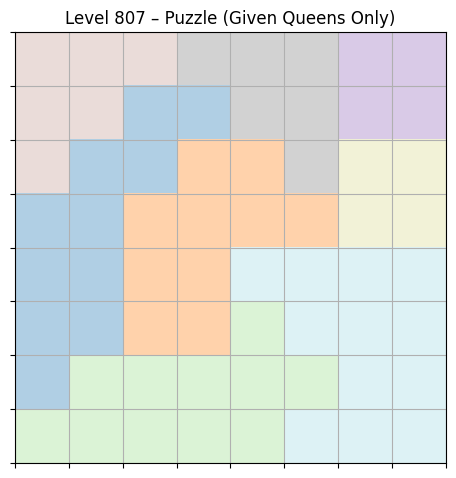

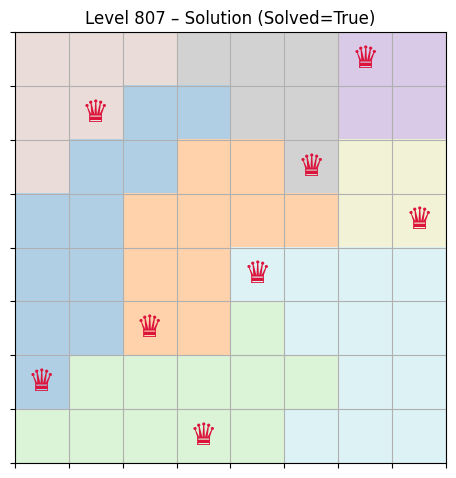

In [19]:
analyze_level("/Users/fanzichen/Downloads/LevelDump原始版.json", 807)


In [30]:
def analyze_level(json_path: str, level_index: int = 1, out_dir: str | None = None):
    import json
    import os
    import numpy as np
    from collections import Counter

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # ✅ 兼容三种格式：
    # 1) {"LevelOrder":[{...}, {...}]}
    # 2) [{...}, {...}]
    # 3) {...}  (单关就是一个 dict)
    if isinstance(data, dict) and "LevelOrder" in data:
        levels = data["LevelOrder"]
    elif isinstance(data, list):
        levels = data
    elif isinstance(data, dict):
        levels = [data]
    else:
        raise ValueError("Unsupported JSON format")

    if not (1 <= level_index <= len(levels)):
        raise ValueError(f"Level index out of range (1~{len(levels)})")

    level = levels[level_index - 1]

    print("=" * 80)
    print(f"Analyze Level {level_index}")
    print("=" * 80)

    # =========================
    # 1️⃣ Decode (Given only)
    # =========================
    H, W = int(level["SizeY"]), int(level["SizeX"])

    # GridColours: 你的历史代码是 column-major，因此这里保持一致
    # regions row-major shape = [H][W]
    regions = np.array(level["GridColours"], dtype=int).reshape(W, H).T

    # QueensGrid / PremarkGrid: 也按 column-major 的 index->(r,c) 解码
    queens_flat = level.get("QueensGrid", [0] * (H * W))
    premark_flat = level.get("PremarkGrid", [0] * (H * W))

    givens = {(i % H, i // H) for i, v in enumerate(queens_flat) if v == 2}
    premarks = {(i % H, i // H) for i, v in enumerate(premark_flat) if v == 1}

    # 你原本的 plot_level_fixed 需要的是 level dict（内部再自己取 GridColours/QueensGrid）
    # 这里额外给你打印一下解码结果，方便 sanity check
    print(f"Size: {H}x{W}")
    print(f"Given queens: {sorted(givens)}")
    print(f"Premarks   : {sorted(premarks)}")

    plot_level_fixed(
        level,
        solution=None,
        title=f"Level {level_index} – Puzzle "
    )

    # 如果你想把“对应关卡图片”保存出来
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
        save_path = os.path.join(out_dir, f"level_{level_index:04d}_puzzle.png")
        plot_level_fixed(
            level,
            solution=None,
            title=f"Level {level_index} – Puzzle",
            save_path=save_path
        )
        print(f"[Saved] {save_path}")

    # =========================
    # 2️⃣ Solve
    # =========================
    state = build_state_from_level(level)
    solved, steps = solve(state)
    print("Solved queens:", state.queens)

    # =========================
    # 3️⃣ Plot solution
    # =========================
    plot_level_fixed(
        level,
        solution=state.queens,
        title=f"Level {level_index} – Solution (Solved={solved})"
    )

    if out_dir:
        save_path = os.path.join(out_dir, f"level_{level_index:04d}_solution.png")
        plot_level_fixed(
            level,
            solution=state.queens,
            title=f"Level {level_index} – Solution (Solved={solved})",
            save_path=save_path
        )
        print(f"[Saved] {save_path}")

    # =========================
    # 4️⃣ Difficulty & stats
    # =========================
    score, breakdown = score_from_steps_v2(steps)
    tech_usage = Counter(s.tech for s in steps)

    highest = max(
        (s.tech for s in steps),
        default=None,
        key=lambda t: TECH_WEIGHTS.get(t, 0)
    )

    print("=" * 80)
    print(f"Solved            : {solved}")
    print(f"Difficulty Score  : {score:.2f}")
    print(f"Highest Technique : {highest}")
    print(f"Steps             : {len(steps)}")

    # =========================
    # 5️⃣ Steps
    # =========================
    show_steps(steps)

    # =========================
    # 6️⃣ Breakdown
    # =========================
    print("=" * 80)
    print("Breakdown:")
    for tech, b in sorted(breakdown.items(), key=lambda x: -x[1]["score"]):
        print(
            f"  {tech:28s} "
            f"count={b['count']:3d} "
            f"impact={b['impact']:5d} "
            f"score={b['score']:.3f}"
        )

    # =========================
    # 7️⃣ Technique usage
    # =========================
    print("=" * 80)
    print("Technique Usage:")
    for tech, cnt in sorted(tech_usage.items(), key=lambda x: TECH_WEIGHTS.get(x[0], 0), reverse=True):
        print(f"  {tech:28s} x {cnt}")

    print("=" * 80)

    return {
        "solved": solved,
        "score": score,
        "steps": len(steps),
        "highest": highest,
        "tech_usage": dict(tech_usage),
        "givens": sorted(givens),
        "premarks": sorted(premarks),
    }

Analyze Level 1
Size: 8x8
Given queens: []
Premarks   : []


TypeError: plot_level_fixed() got an unexpected keyword argument 'save_path'

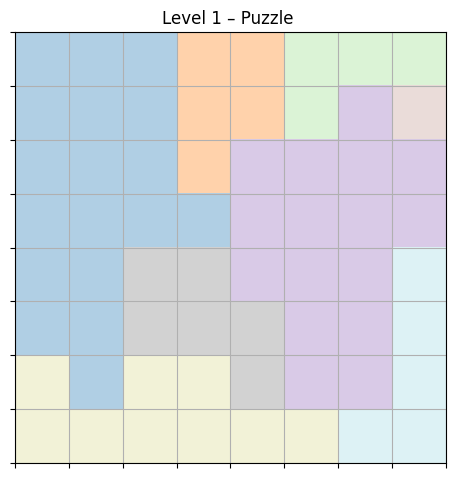

In [31]:
res = analyze_level("/Users/fanzichen/Downloads/8*8粉蓝黄.json", level_index=1, out_dir="/Users/fanzichen/Download/level_imgs")
res

# 转译特定关卡

In [12]:
# # =========================================================
# # Logic helpers (for backtracking & uniqueness)
# # =========================================================

def _run_logic_until_stable(state: State) -> None:
    propagate(state, steps=None)

    while True:
        progressed = False
        for rule in LOGIC_PIPELINE:
            if rule(state, []):   # 统一位置参数，兼容 lambda
                propagate(state, steps=None)
                progressed = True
                break
        if not progressed:
            break

    # 死路剪枝：未放置颜色必须仍有候选
    unplaced = state.all_colors() - state.placed_colors
    for col in unplaced:
        if not any(state.regions[r][c] == col for (r, c) in state.candidates):
            raise ValueError("Dead end")


def _pick_branch_color(state: State):
    unplaced = list(state.all_colors() - state.placed_colors)
    best_col, best_cells = None, None

    for col in unplaced:
        cells = [(r, c) for (r, c) in state.candidates if state.regions[r][c] == col]
        if not cells:
            raise ValueError("Dead end")
        if best_cells is None or len(cells) < len(best_cells):
            best_col, best_cells = col, cells
            if len(cells) == 1:
                break

    return best_col, best_cells


def count_solutions(state: State, limit=2) -> int:
    def dfs(st: State, found: int) -> int:
        if found >= limit:
            return found

        try:
            _run_logic_until_stable(st)
        except ValueError:
            return found

        if is_solved(st):
            return found + 1

        try:
            _, choices = _pick_branch_color(st)
        except ValueError:
            return found

        for (r, c) in choices:
            if found >= limit:
                break
            nxt = copy.deepcopy(st)
            try:
                place_queen(nxt, r, c)
                found = dfs(nxt, found)
            except ValueError:
                continue

        return found

    return dfs(copy.deepcopy(state), 0)


def find_one_solution(state: State) -> Optional[Set[Tuple[int, int]]]:
    def dfs(st: State):
        try:
            _run_logic_until_stable(st)
        except ValueError:
            return None

        if is_solved(st):
            return set(st.queens)

        _, choices = _pick_branch_color(st)
        for (r, c) in choices:
            nxt = copy.deepcopy(st)
            try:
                place_queen(nxt, r, c)
            except ValueError:
                continue
            res = dfs(nxt)
            if res is not None:
                return res
        return None

    return dfs(copy.deepcopy(state))


In [47]:
import json
import numpy as np
from collections import Counter

def rowmajor_to_colmajor_list(regions_rowmajor):
    """regions_rowmajor: List[List[int]]  shape [H][W]
       return: GridColours list in column-major (length H*W)
    """
    H = len(regions_rowmajor)
    W = len(regions_rowmajor[0])
    out = []
    for c in range(W):
        for r in range(H):
            out.append(int(regions_rowmajor[r][c]))
    return out

def make_level_from_demo_image():
    ##替换这个排面
    regions = [
        [0,1,1,1],
        [0,1,1,2],
        [0,1,1,4],
        [0,4,4,4],
    ]
    H, W = 4, 4

    level = {
        "SizeX": W,
        "SizeY": H,
        "GridColours": rowmajor_to_colmajor_list(regions),
        # 0=空 2=给定Queen（你代码里用 v==2 识别 givens）
        "QueensGrid": [0] * (H * W),
        "UsedColors": sorted(list({v for row in regions for v in row})),
        # 下面三项先占位，解完会写回
        "SolutionQueens": [],
        "Score": 0.0,
        "HighestTech": "",
        "IsUnique": True,   # 如果你后面有唯一解计数器，可在解完后更新
    }
    return level

def solve_and_write_back(level: dict):
    # 1) solve
    state = build_state_from_level(level)
    solved, steps = solve(state)

    # 2) difficulty
    score, breakdown = score_from_steps_v2(steps)
    tech_usage = Counter(s.tech for s in steps)
    highest = max(
        (s.tech for s in steps),
        default="",
        key=lambda t: TECH_WEIGHTS.get(t, 0)
    )

    # 3) write back (SolutionQueens 用 [r,c] 数组形式)
    #    你示例里也是 [ [r,c], ... ] :contentReference[oaicite:1]{index=1}
    solution = sorted([list(rc) for rc in state.queens])  # sort for stable output

    level2 = dict(level)
    level2["SolutionQueens"] = solution
    level2["Score"] = float(score)
    level2["HighestTech"] = highest
#     # 如果你有唯一解计数器，这里可以替换：
#     level2["IsUnique"] = (count_solutions(build_state_from_level(level2), limit=2) == 1)

    return level2, {
        "solved": solved,
        "score": score,
        "highest": highest,
        "steps": len(steps),
        "tech_usage": dict(tech_usage),
        
    }

def export_single_level_as_levelorder(level: dict, out_json_path: str):
    payload = {"LevelOrder": [level]}
    with open(out_json_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

# ====== 一键跑 ======
demo_level = make_level_from_demo_image()
demo_level_solved, info = solve_and_write_back(demo_level)

print("Solved:", info["solved"])
print("Score:", info["score"])
print("Highest:", info["highest"])
print("SolutionQueens:", demo_level_solved["SolutionQueens"])

out_path = "demo_4x4_from_image_solved.json"
export_single_level_as_levelorder(demo_level_solved, out_path)
print("Wrote:", out_path)


Solved: True
Score: 18.367071237899847
Highest: ForcedMove
SolutionQueens: [[0, 1], [1, 3], [2, 0], [3, 2]]
Wrote: demo_4x4_from_image_solved.json


In [32]:
import json

src = "/Users/fanzichen/广告变现/demo_4x4_from_image_solved.json"
dst = "/Users/fanzichen/广告变现/demo_4x4_from_image_solved.json"

with open(src, "r", encoding="utf-8") as f:
    obj = json.load(f)

level = obj["LevelOrder"][0]  # 取出单关

with open(dst, "w", encoding="utf-8") as f:
    json.dump(level, f, ensure_ascii=False, indent=2)

print("wrote:", dst)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/fanzichen/广告变现/demo_4x4_from_image_solved.json'

Solved: True
Queens: {(0, 1), (3, 2), (1, 3), (2, 0)}
Solved            : True
Difficulty Score  : 18.37
Highest Technique : ForcedMove
Steps             : 6
Solve Steps:
01. [ForcedMove] impact=9
    place: (1, 3)
    Color 2 has only one cell -> place (1,3)
    removed: r0:[2,3] | r1:[0,1,2,3] | r2:[2,3] | r3:[3]
02. [ColorToRowSetLock1] impact=1
    Colors (4,) are confined to rows [3] -> remove other colors from these rows
    removed: r3:[0]
03. [ColorToColSetLock1] impact=1
    Colors (1,) are confined to cols [1] -> remove other colors from these cols
    removed: r3:[1]
04. [ForcedMove] impact=2
    place: (3, 2)
    Color 4 has only one cell -> place (3,2)
    removed: r2:[1] | r3:[2]
05. [ForcedMove] impact=2
    place: (0, 1)
    Color 1 has only one cell -> place (0,1)
    removed: r0:[0,1]
06. [ForcedMove] impact=1
    place: (2, 0)
    Color 0 has only one cell -> place (2,0)
    removed: r2:[0]

Total steps: 6
Breakdown:
  ForcedMove                   count=  4 impact=  

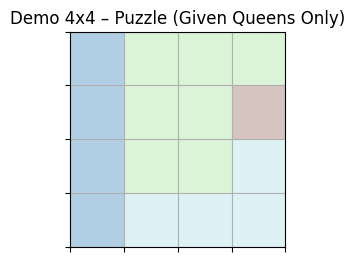

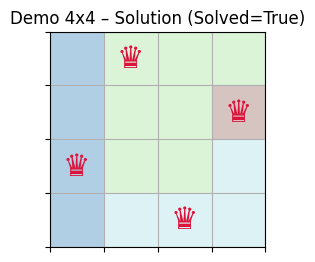

In [33]:
# 生成你图示的 5x5 关卡
level = make_level_from_demo_image()


# ========== 1️⃣ 只画题面（无解） ==========
plot_level_fixed(
    level,
    solution=None,
    title="Demo 4x4 – Puzzle (Given Queens Only)"
)

# ========== 2️⃣ 求解 ==========
state = build_state_from_level(level)
solved, steps = solve(state)

print("Solved:", solved)
print("Queens:", state.queens)

# ========== 3️⃣ 画解 ==========
plot_level_fixed(
    level,
    solution=state.queens,
    title=f"Demo 4x4 – Solution (Solved={solved})"
)


# =========================
# 4️⃣ Difficulty & stats
# =========================
score, breakdown = score_from_steps_v2(steps)
tech_usage = Counter(s.tech for s in steps)

highest = max(
    (s.tech for s in steps),
    default=None,
    key=lambda t: TECH_WEIGHTS.get(t, 0)
)

print("=" * 80)
print(f"Solved            : {solved}")
print(f"Difficulty Score  : {score:.2f}")
print(f"Highest Technique : {highest}")
print(f"Steps             : {len(steps)}")

# =========================
# 5️⃣ Steps
# =========================
show_steps(steps)

# =========================
# 6️⃣ Breakdown
# =========================
print("=" * 80)
print("Breakdown:")
for tech, b in sorted(
    breakdown.items(),
    key=lambda x: -x[1]["score"]
):
    print(
        f"  {tech:28s} "
        f"count={b['count']:3d} "
        f"impact={b['impact']:5d} "
        f"score={b['score']:.3f}"
    )

# =========================
# 7️⃣ Technique usage
# =========================
print("=" * 80)
print("Technique Usage:")
for tech, cnt in sorted(
    tech_usage.items(),
    key=lambda x: TECH_WEIGHTS.get(x[0], 0),
    reverse=True
):
    print(f"  {tech:28s} x {cnt}")

print("=" * 80)

# 转译特定关卡 premark

In [55]:
import json
import numpy as np
from collections import Counter

def rowmajor_to_colmajor_list(regions_rowmajor):
    """regions_rowmajor: List[List[int]]  shape [H][W]
       return: GridColours list in column-major (length H*W)
    """
    H = len(regions_rowmajor)
    W = len(regions_rowmajor[0])
    out = []
    for c in range(W):
        for r in range(H):
            out.append(int(regions_rowmajor[r][c]))
    return out

def rowmajor_to_colmajor_flat(grid_rowmajor):
    """grid_rowmajor: List[List[int]] shape [H][W] -> flat list column-major length H*W"""
    H = len(grid_rowmajor)
    W = len(grid_rowmajor[0])
    out = []
    for c in range(W):
        for r in range(H):
            out.append(int(grid_rowmajor[r][c]))
    return out

def make_level_from_demo_image():
    # =========================
    # (8x8) Regions for this image
    # =========================
    # =========================
    # (10x10) Regions for this image
    # =========================
    regions = [
        [0,0,0,0,1,1,1,1,1,2],
        [0,3,3,3,3,3,3,3,3,2],
        [4,4,4,3,5,5,5,5,3,2],
        [3,3,4,4,5,3,3,6,3,2],
        [3,3,3,3,3,3,6,6,3,2],
        [3,3,7,7,3,6,6,3,3,9],
        [3,3,7,3,3,8,3,3,3,9],
        [3,3,7,3,3,8,3,3,3,9],
        [3,3,7,8,8,8,3,3,9,9],
        [3,3,3,3,3,3,3,3,3,3],
    ]

    H, W = 10, 10


    # =========================
    # 2) QueensGrid（给定 Queen）
    # =========================
    queens_rowmajor = [
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
    ]
    queens_colmajor = rowmajor_to_colmajor_list(queens_rowmajor)


    # =========================
    # 3) PremarkGrid（预标记 X）
    # =========================
    premark_rowmajor = [
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
        [0]*10,
    ]
    premark_colmajor = rowmajor_to_colmajor_flat(premark_rowmajor)
    
    # ✅ 是否把 PremarkGrid 同步进 QueensGrid（逻辑排除）
    APPLY_PREMARK_TO_QUEENSGRID = True

    queens_grid = [0] * (H * W)
    if APPLY_PREMARK_TO_QUEENSGRID:
        queens_grid = [-1 if v == 1 else 0 for v in premark_colmajor]

    level = {
        "SizeX": W,
        "SizeY": H,
        "GridColours": rowmajor_to_colmajor_list(regions),

        # 0=空 2=给定Queen；（可选）-1=排除
        "QueensGrid": queens_colmajor,

        # ✅ 新增：1=预标记，0=不标记（column-major）
        "PremarkGrid": premark_colmajor,
        "UsedColors": sorted(list({v for row in regions for v in row})),
        "SolutionQueens": [],
        "Score": 0.0,
        "HighestTech": "",
        "IsUnique": True,
    }
    return level

def solve_and_write_back(level: dict):
    # 1) solve
    state = build_state_from_level(level)
    solved, steps = solve(state)

    # 2) difficulty
    score, breakdown = score_from_steps_v2(steps)
    tech_usage = Counter(s.tech for s in steps)
    highest = max(
        (s.tech for s in steps),
        default="",
        key=lambda t: TECH_WEIGHTS.get(t, 0)
    )

    # 3) write back (SolutionQueens 用 [r,c] 数组形式)
    solution = sorted([list(rc) for rc in state.queens])

    level2 = dict(level)
    level2["SolutionQueens"] = solution
    level2["Score"] = float(score)
    level2["HighestTech"] = highest
    return level2, {
        "solved": solved,
        "score": score,
        "highest": highest,
        "steps": len(steps),
        "tech_usage": dict(tech_usage),
    }

def export_single_level_as_levelorder(level: dict, out_json_path: str):
    payload = {"LevelOrder": [level]}
    with open(out_json_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

# ====== 一键跑 ======
demo_level = make_level_from_demo_image()
demo_level_solved, info = solve_and_write_back(demo_level)

print("Solved:", info["solved"])
print("Score:", info["score"])
print("Highest:", info["highest"])
print("SolutionQueens:", demo_level_solved["SolutionQueens"])

out_path = "/Users/fanzichen/Downloads/10*10_l2.json"
export_single_level_as_levelorder(demo_level_solved, out_path)
print("Wrote:", out_path)


Solved: True
Score: 45.94064100040748
Highest: ColorToRowSetLock2
SolutionQueens: [[0, 4], [1, 0], [2, 7], [3, 3], [4, 9], [5, 6], [6, 2], [7, 5], [8, 8], [9, 1]]
Wrote: /Users/fanzichen/Downloads/10*10_l2.json


{'SizeX': 8,
 'SizeY': 8,
 'GridColours': [0,
  0,
  0,
  0,
  0,
  0,
  6,
  6,
  0,
  0,
  0,
  0,
  5,
  5,
  0,
  6,
  0,
  0,
  0,
  0,
  5,
  5,
  6,
  6,
  1,
  1,
  1,
  3,
  5,
  5,
  6,
  6,
  1,
  1,
  3,
  3,
  3,
  3,
  5,
  6,
  2,
  2,
  3,
  3,
  3,
  3,
  3,
  6,
  2,
  3,
  3,
  3,
  3,
  3,
  3,
  7,
  2,
  4,
  3,
  3,
  7,
  7,
  7,
  7],
 'QueensGrid': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'PremarkGrid': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0

# 生成关卡1关（废弃）

In [43]:
# import numpy as np
# import matplotlib.pyplot as plt


# def parse_level(level):
#     H, W = level["SizeY"], level["SizeX"]

#     regions = np.zeros((H, W), dtype=int)
#     queens = np.zeros((H, W), dtype=int)

#     # column-major -> row-major
#     for i, v in enumerate(level["GridColours"]):
#         r = i % H
#         c = i // H
#         regions[r, c] = v

#     for i, v in enumerate(level.get("QueensGrid", [])):
#         if v == 2:
#             r = i % H
#             c = i // H
#             queens[r, c] = 1

#     return regions, queens


# def plot_initial_board(level, title="Initial Board"):
#     regions, queens = parse_level(level)
#     H, W = regions.shape

#     fig, ax = plt.subplots(figsize=(W, H))

#     # ===== 使用柔和色盘 =====
#     unique_regions = np.unique(regions)
#     base_cmap = plt.colormaps["Pastel1"]   # 👈 柔和
#     cmap = base_cmap.resampled(len(unique_regions))

#     ax.imshow(regions, cmap=cmap)

#     # ===== 网格线 =====
#     ax.set_xticks(np.arange(-0.5, W, 1), minor=True)
#     ax.set_yticks(np.arange(-0.5, H, 1), minor=True)
#     ax.grid(which="minor", color="gray", linewidth=1)

#     ax.set_xticks(np.arange(W))
#     ax.set_yticks(np.arange(H))
#     ax.set_xticklabels(range(W))
#     ax.set_yticklabels(range(H))

#     # ===== Queen（QueensGrid == 2）=====
#     for r in range(H):
#         for c in range(W):
#             if queens[r, c]:
#                 ax.text(
#                     c, r, "♛",
#                     ha="center",
#                     va="center",
#                     fontsize=28,
#                     color="black"
#                 )

#     # ===== 关键：只在显示层翻转一次 =====
# #     ax.invert_yaxis()

#     ax.set_title(title)
#     plt.tight_layout()
#     plt.show()

# import random
# import copy
# from collections import deque
# from typing import List, Tuple, Set, Optional

# # =========================================================
# # Logic helpers (for backtracking & uniqueness)
# # =========================================================

def _run_logic_until_stable(state: State) -> None:
    propagate(state, steps=None)

    while True:
        progressed = False
        for rule in LOGIC_PIPELINE:
            if rule(state, []):   # 统一位置参数，兼容 lambda
                propagate(state, steps=None)
                progressed = True
                break
        if not progressed:
            break

    # 死路剪枝：未放置颜色必须仍有候选
    unplaced = state.all_colors() - state.placed_colors
    for col in unplaced:
        if not any(state.regions[r][c] == col for (r, c) in state.candidates):
            raise ValueError("Dead end")


def _pick_branch_color(state: State):
    unplaced = list(state.all_colors() - state.placed_colors)
    best_col, best_cells = None, None

    for col in unplaced:
        cells = [(r, c) for (r, c) in state.candidates if state.regions[r][c] == col]
        if not cells:
            raise ValueError("Dead end")
        if best_cells is None or len(cells) < len(best_cells):
            best_col, best_cells = col, cells
            if len(cells) == 1:
                break

    return best_col, best_cells


def count_solutions(state: State, limit=2) -> int:
    def dfs(st: State, found: int) -> int:
        if found >= limit:
            return found

        try:
            _run_logic_until_stable(st)
        except ValueError:
            return found

        if is_solved(st):
            return found + 1

        try:
            _, choices = _pick_branch_color(st)
        except ValueError:
            return found

        for (r, c) in choices:
            if found >= limit:
                break
            nxt = copy.deepcopy(st)
            try:
                place_queen(nxt, r, c)
                found = dfs(nxt, found)
            except ValueError:
                continue

        return found

    return dfs(copy.deepcopy(state), 0)


def find_one_solution(state: State) -> Optional[Set[Tuple[int, int]]]:
    def dfs(st: State):
        try:
            _run_logic_until_stable(st)
        except ValueError:
            return None

        if is_solved(st):
            return set(st.queens)

        _, choices = _pick_branch_color(st)
        for (r, c) in choices:
            nxt = copy.deepcopy(st)
            try:
                place_queen(nxt, r, c)
            except ValueError:
                continue
            res = dfs(nxt)
            if res is not None:
                return res
        return None

    return dfs(copy.deepcopy(state))


# # =========================================================
# # Region generator (generic H x W, N colors, connected)
# # =========================================================

# def random_regions(H: int, W: int, n_colors: int, seed=None) -> List[List[int]]:
#     assert n_colors <= min(H, W)

#     rng = random.Random(seed)
#     regions = [[-1] * W for _ in range(H)]

#     cells = [(r, c) for r in range(H) for c in range(W)]
#     rng.shuffle(cells)
#     seeds = cells[:n_colors]

#     fronts = [deque() for _ in range(n_colors)]
#     for col, (r, c) in enumerate(seeds):
#         regions[r][c] = col
#         fronts[col].append((r, c))

#     def neighbors(r, c):
#         for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
#             rr, cc = r + dr, c + dc
#             if 0 <= rr < H and 0 <= cc < W:
#                 yield rr, cc

#     unfilled = H * W - n_colors
#     while unfilled > 0:
#         progress = False
#         for col in range(n_colors):
#             if not fronts[col]:
#                 continue
#             r, c = fronts[col][0]
#             opts = [(rr, cc) for rr, cc in neighbors(r, c) if regions[rr][cc] == -1]
#             if not opts:
#                 fronts[col].popleft()
#                 continue
#             rr, cc = rng.choice(opts)
#             regions[rr][cc] = col
#             fronts[col].append((rr, cc))
#             unfilled -= 1
#             progress = True
#             if unfilled == 0:
#                 break
#         if not progress:
#             return random_regions(H, W, n_colors, seed=rng.randint(1, 10**9))

#     return regions


# # =========================================================
# # Givens helpers
# # =========================================================

# def choose_givens(solution: Set[Tuple[int, int]], k_min, k_max, seed=None):
#     rng = random.Random(seed)
#     k = rng.randint(k_min, k_max)
#     return set(rng.sample(list(solution), k))


# def build_level(H, W, regions, givens):
#     colours = [regions[r][c] for c in range(W) for r in range(H)]
#     queens = [0] * (H * W)
#     for (r, c) in givens:
#         queens[r + c * H] = 2

#     return {
#         "SizeY": H,
#         "SizeX": W,
#         "GridColours": colours,
#         "QueensGrid": queens,
#     }


# # =========================================================
# # Main generator
# # =========================================================

# def generate_level(
#     H: int,
#     W: int,
#     n_colors: int,
#     score_min: float,
#     score_max: float,
#     *,
#     allow_givens=True,
#     givens_range=(0, 3),
#     max_tries=5000,
#     seed=None
# ):
#     rng = random.Random(seed)

#     for _ in range(max_tries):
#         regions = random_regions(H, W, n_colors, seed=rng.randint(1, 10**9))

#         base = State(H, W, regions)
#         solution = find_one_solution(base)
#         if solution is None:
#             continue

#         givens = set()
#         if allow_givens:
#             givens = choose_givens(solution, *givens_range, seed=rng.randint(1, 10**9))

#         level = build_level(H, W, regions, givens)
#         st = build_state_from_level(level)

#         if count_solutions(st, limit=2) != 1:
#             continue

#         ok, steps = solve(st)
#         if not ok:
#             continue

#         score, _ = score_from_steps_v2(steps)
#         if score_min <= score <= score_max:
#             return level, score

#     raise RuntimeError("Failed to generate level")


score: 19.96169176578514
{'SizeY': 8, 'SizeX': 8, 'GridColours': [6, 7, 7, 7, 2, 3, 3, 3, 6, 6, 7, 2, 2, 3, 3, 3, 4, 4, 4, 2, 2, 3, 3, 1, 4, 4, 4, 2, 2, 2, 1, 1, 5, 5, 5, 5, 2, 1, 1, 1, 5, 5, 5, 0, 0, 1, 1, 1, 5, 5, 0, 0, 0, 0, 1, 1, 5, 0, 0, 0, 0, 0, 0, 1], 'QueensGrid': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}
Difficulty score: 19.96
Total steps: 8

=== Detailed solving steps ===

01. [ColorToRowSetLock1] Colors (6,) are confined to rows [0] -> remove other colors from these rows | impact=2
02. [ColorToRowSetLock1] Colors (4,) are confined to rows [2] -> remove other colors from these rows | impact=2
03. [ForcedMove] Color 7 has only one cell -> place (3,0) | impact=9
04. [ForcedMove] Color 6 has only one cell -> place (0,1) | impact=3
05. [ForcedMove] Color 3 has only one cell -> place (6,2) | impact=7
06. [ForcedMove] Color 4 has o

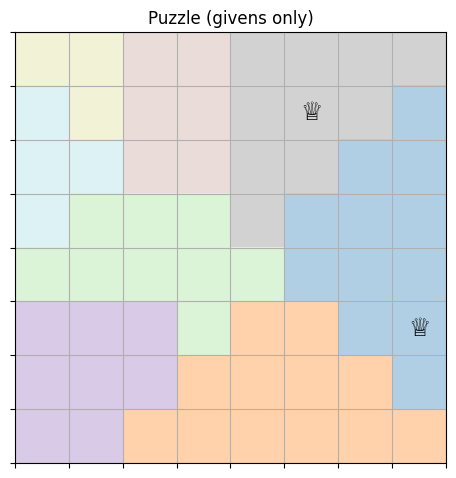

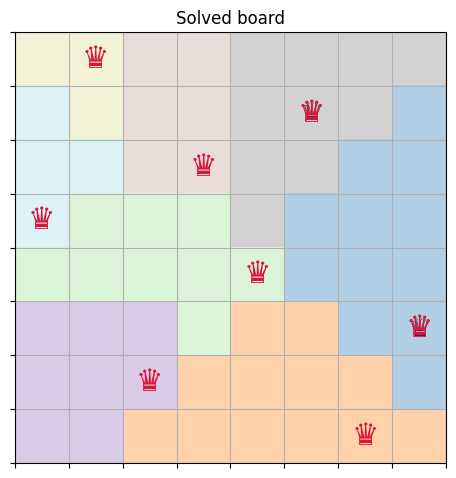

In [58]:
level, score = generate_level(
    H=8,
    W=8,
    n_colors=8,
    score_min=10,
    score_max=30,
    allow_givens=True,
    givens_range=(1, 3),
    seed=20251224
)

print("score:", score)
print(level)

state = build_state_from_level(level)
ok, steps = solve(state)

assert ok
solution = set(state.queens)

print(f"Difficulty score: {score:.2f}")
print("Total steps:", len(steps))

print("\n=== Detailed solving steps ===\n")
for i, st in enumerate(steps, 1):
    print(
        f"{i:02d}. [{st.tech}] "
        f"{st.desc} | "
        f"impact={st.impact}"
    )
    
plot_level_fixed(
    level,
    solution=None,
    title="Puzzle (givens only)"
)
plot_level_fixed(
    level,
    solution=solution,
    title="Solved board"
)



# 批量生成关卡1-200关

In [77]:
import copy
import os
import json
import matplotlib.pyplot as plt

def _save_failed_case(level, reason, level_id=None, out_dir="failed_cases"):
    os.makedirs(out_dir, exist_ok=True)

    tag = f"level_{level_id:03d}" if level_id is not None else "level_unknown"
    base = f"{tag}__{reason}"

    json_path = os.path.join(out_dir, base + ".json")
    png_path  = os.path.join(out_dir, base + ".png")

    # 保存 json（确保可序列化）
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(level, f, ensure_ascii=False, indent=2)

    # 保存 png（失败局面一般也能画）
    try:
        plot_level_fixed(level, solution=None, title=f"{tag} | FAIL: {reason}")
        plt.savefig(png_path, dpi=150, bbox_inches="tight")
        plt.close()
    except Exception:
        png_path = None

    return json_path, png_path


In [78]:
# import random
# import copy
# from collections import deque, Counter
# import numpy as np

# # ============================================================
# # 0) 基础工具：4邻域
# # ============================================================
# def n4(H, W, r, c):
#     for dr, dc in ((1,0),(-1,0),(0,1),(0,-1)):
#         rr, cc = r+dr, c+dc
#         if 0 <= rr < H and 0 <= cc < W:
#             yield rr, cc


# # ============================================================
# # 1) 连通块相关：找某颜色的所有连通块
# # ============================================================
# def connected_components_of_color(regions, color):
#     H, W = len(regions), len(regions[0])
#     seen = [[False]*W for _ in range(H)]
#     comps = []

#     for r in range(H):
#         for c in range(W):
#             if regions[r][c] == color and not seen[r][c]:
#                 q = deque([(r, c)])
#                 seen[r][c] = True
#                 comp = [(r, c)]
#                 while q:
#                     rr, cc = q.popleft()
#                     for r2, c2 in n4(H, W, rr, cc):
#                         if regions[r2][c2] == color and not seen[r2][c2]:
#                             seen[r2][c2] = True
#                             q.append((r2, c2))
#                             comp.append((r2, c2))
#                 comps.append(comp)
#     return comps


# def has_disconnected_color(regions, color_count):
#     for col in range(color_count):
#         comps = connected_components_of_color(regions, col)
#         if len(comps) > 1:
#             return True
#     return False


# def all_colors_present(regions, color_count):
#     cnt = Counter()
#     for row in regions:
#         cnt.update(row)
#     return all(cnt.get(col, 0) > 0 for col in range(color_count))


# # ============================================================
# # 2) 生成棋盘：种子生长（尽量连通）
# #    你之前说没有 generate_regions_compact 了，但 generate_regions_connected 里依赖它，
# #    所以这里我把 compact 版本也一起放回“完整代码”里。
# # ============================================================
# def generate_regions_compact(H, W, color_count, rng: random.Random, compact_bias=0.85):
#     """
#     从若干 seeds 开始向外生长填充，尽量紧凑。
#     输出 regions[H][W]，每格是 [0..color_count-1]
#     """
#     regions = [[-1] * W for _ in range(H)]
#     cells = [(r, c) for r in range(H) for c in range(W)]
#     rng.shuffle(cells)

#     # seeds
#     seeds = []
#     for col in range(color_count):
#         if not cells:
#             break
#         r, c = cells.pop()
#         regions[r][c] = col
#         seeds.append((r, c, col))

#     frontiers = {col: deque() for col in range(color_count)}

#     for (r, c, col) in seeds:
#         for rr, cc in n4(H, W, r, c):
#             if regions[rr][cc] == -1:
#                 frontiers[col].append((rr, cc))

#     unfilled = H * W - len(seeds)
#     colors = list(range(color_count))

#     while unfilled > 0:
#         rng.shuffle(colors)
#         progressed = False

#         for col in colors:
#             if not frontiers[col]:
#                 continue

#             candidates = list(frontiers[col])

#             if rng.random() < compact_bias and candidates:
#                 scored = []
#                 for (r, c) in candidates:
#                     same = sum(1 for rr, cc in n4(H, W, r, c) if regions[rr][cc] == col)
#                     scored.append((same, r, c))
#                 scored.sort(reverse=True)
#                 topk = scored[: max(1, len(scored)//3)]
#                 _, r, c = rng.choice(topk)
#             else:
#                 r, c = rng.choice(candidates)

#             # remove chosen from frontier
#             frontiers[col] = deque([(rr,cc) for rr,cc in frontiers[col] if (rr,cc)!=(r,c)])

#             if regions[r][c] != -1:
#                 continue

#             regions[r][c] = col
#             unfilled -= 1
#             progressed = True

#             for rr, cc in n4(H, W, r, c):
#                 if regions[rr][cc] == -1:
#                     frontiers[col].append((rr, cc))

#             if unfilled <= 0:
#                 break

#         if not progressed:
#             # fallback：极少发生
#             for r in range(H):
#                 for c in range(W):
#                     if regions[r][c] == -1:
#                         regions[r][c] = rng.randrange(color_count)
#                         unfilled -= 1
#                         if unfilled <= 0:
#                             break
#                 if unfilled <= 0:
#                     break

#     return regions


# # ============================================================
# # 3) 后处理：减少碎片（轻度平滑）
# # ============================================================
# def reduce_fragmentation(regions, rng: random.Random, passes=6, protect_singleton=True):
#     H, W = len(regions), len(regions[0])

#     def color_sizes():
#         cnt = Counter()
#         for row in regions:
#             cnt.update(row)
#         return cnt

#     for _ in range(passes):
#         changed = 0
#         order = [(r, c) for r in range(H) for c in range(W)]
#         rng.shuffle(order)

#         sizes = color_sizes() if protect_singleton else None

#         for r, c in order:
#             col = regions[r][c]

#             # singleton / tiny color 保护
#             if protect_singleton and sizes.get(col, 0) <= 2:
#                 continue

#             neigh = [regions[rr][cc] for rr, cc in n4(H, W, r, c)]
#             if not neigh:
#                 continue

#             if neigh.count(col) <= 1:
#                 new_col = Counter(neigh).most_common(1)[0][0]
#                 if new_col != col:
#                     regions[r][c] = new_col
#                     if protect_singleton:
#                         sizes[col] -= 1
#                         sizes[new_col] += 1
#                     changed += 1

#         if changed == 0:
#             break

#     return regions


# # ============================================================
# # 4) 修复连通：最短铺桥，把同色多个连通块连成一个
# # ============================================================
# def shortest_bridge_path(regions, compA, compB):
#     H, W = len(regions), len(regions[0])
#     target = set(compB)

#     q = deque()
#     parent = {}
#     dist = {}

#     for (r, c) in compA:
#         q.append((r, c))
#         parent[(r, c)] = None
#         dist[(r, c)] = 0

#     meet = None
#     while q:
#         cur = q.popleft()
#         if cur in target:
#             meet = cur
#             break
#         r, c = cur
#         for rr, cc in n4(H, W, r, c):
#             nxt = (rr, cc)
#             if nxt not in dist:
#                 dist[nxt] = dist[cur] + 1
#                 parent[nxt] = cur
#                 q.append(nxt)

#     if meet is None:
#         return None

#     path = []
#     x = meet
#     while x is not None:
#         path.append(x)
#         x = parent[x]
#     path.reverse()
#     return path


# def connect_color_components_inplace(regions, color):
#     comps = connected_components_of_color(regions, color)
#     if len(comps) <= 1:
#         return True

#     comps.sort(key=len, reverse=True)
#     main = comps[0]

#     for i in range(1, len(comps)):
#         other = comps[i]
#         path = shortest_bridge_path(regions, main, other)
#         if path is None:
#             return False

#         for (r, c) in path:
#             regions[r][c] = color

#         comps_now = connected_components_of_color(regions, color)
#         if len(comps_now) == 0:
#             return False
#         comps_now.sort(key=len, reverse=True)
#         main = comps_now[0]

#     return len(connected_components_of_color(regions, color)) == 1


# def enforce_all_colors_connected(regions, color_count, max_rounds=3):
#     for _ in range(max_rounds):
#         changed = False
#         for col in range(color_count):
#             comps = connected_components_of_color(regions, col)
#             if len(comps) > 1:
#                 ok = connect_color_components_inplace(regions, col)
#                 if not ok:
#                     return False
#                 changed = True
#         if not changed:
#             return True
#     return not has_disconnected_color(regions, color_count)


# # ============================================================
# # 5) 总生成器：生成 + 平滑 + 强制连通；失败则重来
# # ============================================================
# def generate_regions_connected(
#     H, W, color_count, rng: random.Random,
#     compact_bias=0.85,
#     reduce_passes=6,
#     max_regen=80,
#     max_fix_rounds=3
# ):
#     for _ in range(max_regen):
#         regions = generate_regions_compact(H, W, color_count, rng, compact_bias=compact_bias)
#         regions = reduce_fragmentation(regions, rng, passes=reduce_passes, protect_singleton=True)

#         ok = enforce_all_colors_connected(regions, color_count, max_rounds=max_fix_rounds)
#         if ok and all_colors_present(regions, color_count) and (not has_disconnected_color(regions, color_count)):
#             return regions

#     raise RuntimeError("生成失败：在 max_regen 次尝试内无法得到所有颜色都连通的棋盘。")


# # ============================================================
# # 6) GridColours 导出：你确认是 col-major
# #    idx = r + c*H
# # ============================================================
# def regions_to_gridcolours_col_major(regions):
#     H, W = len(regions), len(regions[0])
#     out = [0]*(H*W)
#     for r in range(H):
#         for c in range(W):
#             out[r + c*H] = int(regions[r][c])
#     return out


# def gridcolours_col_major_to_regions(grid, H, W):
#     # 用于 debug 校验：把 GridColours 还原回 regions[H][W]
#     regions = [[0]*W for _ in range(H)]
#     for c in range(W):
#         for r in range(H):
#             regions[r][c] = int(grid[r + c*H])
#     return regions


# # ============================================================
# # 7) 你原来的分数显示：保持不变
# # ============================================================
# def format_score_gap(target, actual):
#     """
#     返回 (文本, 是否严重偏离)
#     """
#     if target is None or actual is None:
#         return "score=NA", False

#     gap = actual - target
#     ratio = abs(gap) / max(1.0, target)

#     if abs(gap) <= 5:
#         badge = "✓"
#     elif abs(gap) <= 10:
#         badge = "↓" if gap < 0 else "↑"
#     else:
#         badge = "↓↓" if gap < 0 else "↑↑"

#     sign = "+" if gap >= 0 else ""
#     return f"score={actual:.1f} ({sign}{gap:.1f} vs {target}) {badge}", ratio > 0.3


# # ============================================================
# # 8) （可选）失败样例保存：你如果原来就有 _save_failed_case 可删这段
# # ============================================================
# def _save_failed_case(level, reason, level_id=None, out_dir="failed_cases"):
#     import os, json
#     os.makedirs(out_dir, exist_ok=True)
#     name = f"failed_L{level_id}_{reason}.json" if level_id is not None else f"failed_{reason}.json"
#     path = os.path.join(out_dir, name)
#     with open(path, "w", encoding="utf-8") as f:
#         json.dump(level, f, ensure_ascii=False, indent=2)


# # ============================================================
# # 9) 替换后的 generate_level_excavation
# # ============================================================
# def generate_level_excavation(
#     spec,
#     run_level_fn,
#     max_tries=500,
#     seed=None,
#     debug=True,
#     level_id=None,
#     # 你可以微调这些
#     compact_bias=0.85,
#     reduce_passes=6,
#     max_regen=80,
#     max_fix_rounds=3,
# ):
#     rng = random.Random(seed)

#     H = int(spec["rows"])
#     W = int(spec["cols"])
#     color_count = int(spec["color_count"])
#     target_score = spec.get("difficulty_bin")

#     fail_counter = Counter()
#     example_failed = None

#     def record_fail(reason, level=None):
#         nonlocal example_failed
#         fail_counter[reason] += 1
#         if example_failed is None and level is not None:
#             example_failed = (reason, copy.deepcopy(level))

#     for try_i in range(max_tries):
#         if debug and try_i % 20 == 0:
#             print(f"  [exc] try={try_i}/{max_tries}")
#         # ★ 新：生成“保证连通”的 regions
#         regions = generate_regions_connected(
#             H, W, color_count, rng,
#             compact_bias=compact_bias,
#             reduce_passes=reduce_passes,
#             max_regen=max_regen,
#             max_fix_rounds=max_fix_rounds,
#         )

#         level = {
#             "SizeX": W,
#             "SizeY": H,
#             # ★ 新：col-major 导出
#             "GridColours": regions_to_gridcolours_col_major(regions),
#             "QueensGrid": [0] * (H * W),
#             "UsedColors": list(range(color_count)),
#         }


#         # ★ debug 校验：避免 GridColours 顺序搞错导致“看起来不连通”
#         dbg_regions = gridcolours_col_major_to_regions(level["GridColours"], H, W)
#         if has_disconnected_color(dbg_regions, color_count):
#             record_fail("DISCONNECTED_AFTER_EXPORT", level)
#             continue
            
#         #✅ 这不会改变任何“应该成功的关卡”，只会把必死盘提前过滤掉，速度会明显提升。
#         if not quick_feasibility_prune(level):
#             record_fail("PRUNE_NO_CANDIDATE_COLOR", level)
#             continue

#         if debug:
#             print("    [solve] start")
#         result = run_level_fn(level, debug=debug)
#         if debug:
#             print(
#                 f"    [solve] done | "
#                 f"solved={result.get('solved')} "
#                 f"unique={result.get('is_unique')} "
#                 f"score={result.get('score')}"
#             )


#         if not result.get("solved", False):
#             record_fail("UNSOLVED_NO_GIVENS", level)
#             continue

#         if not result.get("is_unique", False):
#             record_fail("NOT_UNIQUE", level)
#             continue

#         score_txt, _ = format_score_gap(target_score, result.get("score"))
#         print(
#             f"[EXC L{level_id}] OK | "
#             f"{H}x{W} c{color_count} | "
#             f"{score_txt} tech={result.get('highest_tech')} unique"
#         )

#         return level, result

#     if debug:
#         print(f"[EXC L{level_id}] FAIL | {H}x{W} c{color_count} | target={target_score}")
#         for r, c in fail_counter.most_common():
#             print(f"  {r} x{c}")

#         if example_failed:
#             reason, failed_level = example_failed
#             _save_failed_case(
#                 failed_level,
#                 reason=reason,
#                 level_id=level_id,
#                 out_dir="failed_cases"
#             )

#     return None, None


# # ============================================================
# # 10) 替换后的 generate_level_activation
# # ============================================================
# def generate_level_activation(
#     spec,
#     run_level_fn,
#     max_tries=500,
#     seed=None,
#     debug=True,
#     level_id=None,
#     # 你可以微调这些
#     compact_bias=0.85,
#     reduce_passes=6,
#     max_regen=80,
#     max_fix_rounds=3,
# ):
#     rng = random.Random(seed)

#     H = int(spec["rows"])
#     W = int(spec["cols"])
#     color_count = int(spec["color_count"])
#     given_queens = int(spec["given_queens"])
#     target_score = spec.get("difficulty_bin")

#     fail_counter = Counter()
#     example_failed = None

#     def record_fail(reason, level=None):
#         nonlocal example_failed
#         fail_counter[reason] += 1
#         if example_failed is None and level is not None:
#             example_failed = (reason, copy.deepcopy(level))

#     center_r = (H - 1) / 2
#     center_c = (W - 1) / 2

#     for _ in range(max_tries):
#         # ★ 新：生成“保证连通”的 regions
#         regions = generate_regions_connected(
#             H, W, color_count, rng,
#             compact_bias=compact_bias,
#             reduce_passes=reduce_passes,
#             max_regen=max_regen,
#             max_fix_rounds=max_fix_rounds,
#         )

#         # 建 region->cells
#         region_cells = {}
#         for r in range(H):
#             for c in range(W):
#                 region_cells.setdefault(regions[r][c], []).append((r, c))

#         # 候选更偏中心 + 更偏大块
#         candidates = []
#         for col, cells in region_cells.items():
#             for r, c in cells:
#                 dist = abs(r - center_r) + abs(c - center_c)
#                 candidates.append((len(cells) - dist * 0.5, r, c))

#         candidates.sort(reverse=True)
#         cutoff = max(1, int(len(candidates) * 0.3))
#         candidate_cells = [(r, c) for _, r, c in candidates[:cutoff]]
#         rng.shuffle(candidate_cells)

#         givens = []
#         used_rows = set()
#         used_cols = set()
#         used_colors = set()

#         for r, c in candidate_cells:
#             if len(givens) >= given_queens:
#                 break
#             col = regions[r][c]
#             if r in used_rows or c in used_cols or col in used_colors:
#                 continue
#             if any(abs(r - rr) <= 1 and abs(c - cc) <= 1 for rr, cc in givens):
#                 continue
#             givens.append((r, c))
#             used_rows.add(r)
#             used_cols.add(c)
#             used_colors.add(col)

#         if len(givens) < given_queens:
#             record_fail("GIVENS_NOT_ENOUGH")
#             continue

#         qgrid = [0] * (H * W)
#         for r, c in givens:
#             qgrid[r + c * H] = 2  # col-major

#         level = {
#             "SizeX": W,
#             "SizeY": H,
#             # ★ 新：col-major 导出
#             "GridColours": regions_to_gridcolours_col_major(regions),
#             "QueensGrid": qgrid,
#             "UsedColors": list(range(color_count)),
#         }

#         # ★ debug 校验：避免 GridColours 顺序搞错导致“看起来不连通”
#         dbg_regions = gridcolours_col_major_to_regions(level["GridColours"], H, W)
#         if has_disconnected_color(dbg_regions, color_count):
#             record_fail("DISCONNECTED_AFTER_EXPORT", level)
#             continue
        
#         #✅ 这不会改变任何“应该成功的关卡”，只会把必死盘提前过滤掉，速度会明显提升。
#         if not quick_feasibility_prune(level):
#             record_fail("PRUNE_NO_CANDIDATE_COLOR", level)
#             continue


#         if debug:
#             print("    [solve] start")
#         result = run_level_fn(level, debug=debug)
#         if debug:
#             print(
#                 f"    [solve] done | "
#                 f"solved={result.get('solved')} "
#                 f"unique={result.get('is_unique')} "
#                 f"score={result.get('score')}"
#             )

#         if not result.get("solved", False):
#             record_fail("UNSOLVED_WITH_GIVENS", level)
#             continue

#         if not result.get("is_unique", False):
#             record_fail("NOT_UNIQUE", level)
#             continue

#         score_txt, _ = format_score_gap(target_score, result.get("score"))

#         print(
#             f"[ACT L{level_id}] OK | "
#             f"{H}x{W} c{color_count} g{given_queens} | "
#             f"{score_txt} tech={result.get('highest_tech')} unique"
#         )

#         return level, result

#     if debug:
#         print(
#             f"[ACT L{level_id}] FAIL | "
#             f"{H}x{W} c{color_count} g{given_queens} | "
#             f"target={target_score}"
#         )
#         for r, c in fail_counter.most_common():
#             print(f"  {r} x{c}")

#         if example_failed:
#             reason, failed_level = example_failed
#             _save_failed_case(
#                 failed_level,
#                 reason=reason,
#                 level_id=level_id,
#                 out_dir="failed_cases"
#             )

#     return None, None


In [79]:
# def generate_one_level_from_spec(
#     spec,
#     run_level_fn,
#     seed=None,
#     **_ignore_kwargs,   # ★ 吃掉 level_id / failed_dir / verbose_fail 等
# ):
#     given_queens = int(spec.get("given_queens", 0) or 0)

#     if given_queens == 0:
#         return generate_level_excavation(
#             spec,
#             run_level_fn=run_level_fn,
#             seed=seed,
#         )
#     else:
#         return generate_level_activation(
#             spec,
#             run_level_fn=run_level_fn,
#             seed=seed,
#         )

# def count_tech_steps(steps):
#     from collections import Counter
#     cnt = Counter()
#     for st in steps:
#         if st.tech:
#             cnt[st.tech] += 1
#     return cnt

# def generate_levels_batch(
#     specs_df,
#     run_level_fn,
#     out_levels_dir="generated_levels",
#     out_plots_dir="generated_plots",
#     out_summary_csv="generated_summary.csv",
#     seed=1234,
# ):
#     import os
#     import json
#     import random
#     import pandas as pd
#     import matplotlib.pyplot as plt
#     from collections import Counter

#     os.makedirs(out_levels_dir, exist_ok=True)
#     os.makedirs(out_plots_dir, exist_ok=True)

#     rng = random.Random(seed)
#     summary_rows = []

#     for _, spec in specs_df.iterrows():

#         level_id = int(spec["level_id"])
#         print(f"\n=== Generating Level {level_id} ===")

#         diff_bin = spec.get("difficulty_bin", None)
#         diff_lo, diff_hi = difficulty_range_from_bin(diff_bin)

#         level, result = generate_one_level_from_spec(
#             spec,
#             run_level_fn=run_level_fn,
#             seed=rng.randrange(10**9),
#             level_id=level_id,
#             dump_failed_on_total_fail=True,
#             failed_dir="failed_cases",
#             verbose_fail=False,
#             debug=True, 
#         )

#         # ================= FAILED =================
#         if level is None:
#             print("  ✗ failed")
#             summary_rows.append({
#                 "level_id": level_id,
#                 "rows": int(spec["rows"]),
#                 "cols": int(spec["cols"]),
#                 "color_count": int(spec["color_count"]),
#                 "given_queens": int(spec.get("given_queens", 0) or 0),
#                 "difficulty_bin": diff_bin,
#                 "target_diff_lo": diff_lo,
#                 "target_diff_hi": diff_hi,
#                 "generated_score": None,
#                 "highest_tech": None,
#                 "tech_set": "",
#                 "tech_steps": "",
#                 "tech_count": 0,
#                 "total_steps": 0,
#                 "is_unique": False,
#                 "solved": False,
#             })
#             continue

#         # ================= SUCCESS =================
#         out = dict(level)
#         out["SolutionQueens"] = result["solution"]
#         out["Score"] = result["score"]
#         out["HighestTech"] = result["highest_tech"]
#         out["IsUnique"] = result["is_unique"]

#         json_path = os.path.join(out_levels_dir, f"level_{level_id:03d}.json")
#         with open(json_path, "w", encoding="utf-8") as f:
#             json.dump(out, f, ensure_ascii=False, indent=2)

#         plot_level_fixed(
#             level,
#             solution=None,
#             title=f"Level {level_id} | score={out['Score']:.1f} | tech={out['HighestTech']}"
#         )

#         plot_path = os.path.join(out_plots_dir, f"level_{level_id:03d}.png")
#         plt.savefig(plot_path, dpi=150, bbox_inches="tight")
#         plt.close()

#         print(f"  ✓ saved | score={out['Score']:.1f} | unique={out['IsUnique']}")

#         # -------- tech step statistics --------
#         steps = result.get("breakdown", None)
#         step_list = result.get("steps", None)

#         tech_counter = Counter()
#         if step_list:
#             for st in step_list:
#                 if st.tech:
#                     tech_counter[st.tech] += 1

#         tech_set = sorted(tech_counter.keys())
#         tech_steps_str = "|".join(
#             f"{tech}:{cnt}" for tech, cnt in tech_counter.items()
#         )

#         summary_rows.append({
#             "level_id": level_id,
#             "rows": int(spec["rows"]),
#             "cols": int(spec["cols"]),
#             "color_count": int(spec["color_count"]),
#             "given_queens": int(spec.get("given_queens", 0) or 0),
#             "difficulty_bin": diff_bin,
#             "target_diff_lo": diff_lo,
#             "target_diff_hi": diff_hi,
#             "generated_score": float(result["score"]),
#             "highest_tech": result["highest_tech"],
#             "tech_set": ",".join(tech_set),
#             "tech_steps": tech_steps_str,
#             "tech_count": len(tech_set),
#             "total_steps": sum(tech_counter.values()),
#             "is_unique": bool(result["is_unique"]),
#             "solved": True,
#         })

#     # ================= SAVE SUMMARY =================
#     summary_df = pd.DataFrame(summary_rows)
#     summary_df.to_csv(out_summary_csv, index=False)

#     print(f"\n=== Summary saved to {out_summary_csv} ===")


In [394]:
specs_df = pd.read_csv("level_summary.csv")[:250]
generate_levels_batch(
    specs_df,
    run_level_fn=run_level_local,  # 你之前用的那个
)



=== Generating Level 1 ===
[ACT LNone] OK | 4x4 c3 g1 | score=6.0 (+6.0 vs 0) ↑ tech=ForcedMove unique
  ✓ saved | score=6.0 | unique=True

=== Generating Level 2 ===
[ACT LNone] OK | 4x4 c3 g1 | score=6.8 (+6.8 vs 0) ↑ tech=ForcedMove unique
  ✓ saved | score=6.8 | unique=True

=== Generating Level 3 ===
[ACT LNone] OK | 4x4 c3 g1 | score=9.8 (+9.8 vs 0) ↑ tech=ColorToColSetLock1 unique
  ✓ saved | score=9.8 | unique=True

=== Generating Level 4 ===
[ACT LNone] OK | 5x4 c4 g1 | score=12.7 (+12.7 vs 0) ↑↑ tech=ColorToColSetLock1 unique
  ✓ saved | score=12.7 | unique=True

=== Generating Level 5 ===
[ACT LNone] OK | 4x4 c3 g1 | score=9.8 (+9.8 vs 0) ↑ tech=ColorToColSetLock1 unique
  ✓ saved | score=9.8 | unique=True

=== Generating Level 6 ===
[ACT LNone] OK | 5x4 c4 g1 | score=8.5 (+8.5 vs 0) ↑ tech=ForcedMove unique
  ✓ saved | score=8.5 | unique=True

=== Generating Level 7 ===
[EXC LNone] OK | 4x4 c3 | score=17.7 (+7.7 vs 10) ↑ tech=ColorToRowSetLock1 unique
  ✓ saved | score=17.

  ✓ saved | score=34.2 | unique=True

=== Generating Level 62 ===
[EXC LNone] OK | 7x7 c7 | score=40.9 (+20.9 vs 20) ↑↑ tech=ColorToRowSetLock2 unique
  ✓ saved | score=40.9 | unique=True

=== Generating Level 63 ===
[EXC LNone] OK | 7x7 c7 | score=45.5 (-14.5 vs 60) ↓↓ tech=ColorToRowSetLock2 unique
  ✓ saved | score=45.5 | unique=True

=== Generating Level 64 ===
[EXC LNone] FAIL | 9x9 c9 | target=40
  UNSOLVED_NO_GIVENS x800
  ✗ failed

=== Generating Level 65 ===
[EXC LNone] OK | 7x7 c7 | score=28.2 (-11.8 vs 40) ↓↓ tech=KingBoxExclusion unique
  ✓ saved | score=28.2 | unique=True

=== Generating Level 66 ===
[EXC LNone] FAIL | 8x8 c8 | target=20
  UNSOLVED_NO_GIVENS x800
  ✗ failed

=== Generating Level 67 ===
[EXC LNone] OK | 7x7 c7 | score=22.8 (-67.2 vs 90) ↓↓ tech=ColorToRowSetLock1 unique
  ✓ saved | score=22.8 | unique=True

=== Generating Level 68 ===
[EXC LNone] OK | 8x8 c8 | score=95.6 (+55.6 vs 40) ↑↑ tech=EliminateByContradiction unique
  ✓ saved | score=95.6 | unique=T

[EXC LNone] OK | 7x7 c7 | score=37.8 (+7.8 vs 30) ↑ tech=ColorToRowSetLock2 unique
  ✓ saved | score=37.8 | unique=True

=== Generating Level 126 ===
[EXC LNone] OK | 8x8 c8 | score=21.8 (+1.8 vs 20) ✓ tech=ForcedMove unique
  ✓ saved | score=21.8 | unique=True

=== Generating Level 127 ===
[EXC LNone] OK | 7x7 c7 | score=37.5 (-2.5 vs 40) ✓ tech=ColorToRowSetLock2 unique
  ✓ saved | score=37.5 | unique=True

=== Generating Level 128 ===
[EXC LNone] FAIL | 8x8 c8 | target=30
  UNSOLVED_NO_GIVENS x800
  ✗ failed

=== Generating Level 129 ===
[EXC LNone] FAIL | 9x9 c9 | target=40
  UNSOLVED_NO_GIVENS x800
  ✗ failed

=== Generating Level 130 ===
[EXC LNone] OK | 7x7 c7 | score=47.6 (+17.6 vs 30) ↑↑ tech=ColorToRowSetLock3 unique
  ✓ saved | score=47.6 | unique=True

=== Generating Level 131 ===
[EXC LNone] OK | 8x8 c8 | score=79.0 (-11.0 vs 90) ↓↓ tech=EliminateByContradiction unique
  ✓ saved | score=79.0 | unique=True

=== Generating Level 132 ===
[EXC LNone] OK | 7x7 c7 | score=33.3 (

  ✓ saved | score=35.2 | unique=True

=== Generating Level 191 ===
[EXC LNone] FAIL | 8x8 c8 | target=40
  UNSOLVED_NO_GIVENS x800
  ✗ failed

=== Generating Level 192 ===
[EXC LNone] OK | 7x7 c7 | score=33.9 (+3.9 vs 30) ✓ tech=ColorToRowSetLock2 unique
  ✓ saved | score=33.9 | unique=True

=== Generating Level 193 ===
[EXC LNone] OK | 8x8 c8 | score=77.5 (+47.5 vs 30) ↑↑ tech=EliminateByContradiction unique
  ✓ saved | score=77.5 | unique=True

=== Generating Level 194 ===
[EXC LNone] FAIL | 9x9 c9 | target=50
  UNSOLVED_NO_GIVENS x800
  ✗ failed

=== Generating Level 195 ===
[EXC LNone] OK | 7x7 c7 | score=44.8 (+14.8 vs 30) ↑↑ tech=ColorToColSetLock2 unique
  ✓ saved | score=44.8 | unique=True

=== Generating Level 196 ===
[EXC LNone] FAIL | 8x8 c8 | target=50
  UNSOLVED_NO_GIVENS x800
  ✗ failed

=== Generating Level 197 ===
[EXC LNone] OK | 7x7 c7 | score=38.1 (-1.9 vs 40) ✓ tech=ColorToRowSetLock2 unique
  ✓ saved | score=38.1 | unique=True

=== Generating Level 198 ===
[EXC LNo

# 生成关卡库

In [80]:
import random
import copy
from collections import deque, Counter

# =========================================================
# 0) 4邻域
# =========================================================
def n4(H, W, r, c):
    for dr, dc in ((1,0),(-1,0),(0,1),(0,-1)):
        rr, cc = r+dr, c+dc
        if 0 <= rr < H and 0 <= cc < W:
            yield rr, cc


# =========================================================
# 1) 连通块
# =========================================================
def connected_components_of_color(regions, color):
    H, W = len(regions), len(regions[0])
    seen = [[False]*W for _ in range(H)]
    comps = []
    for r in range(H):
        for c in range(W):
            if regions[r][c] == color and not seen[r][c]:
                q = deque([(r, c)])
                seen[r][c] = True
                comp = [(r, c)]
                while q:
                    rr, cc = q.popleft()
                    for r2, c2 in n4(H, W, rr, cc):
                        if regions[r2][c2] == color and not seen[r2][c2]:
                            seen[r2][c2] = True
                            q.append((r2, c2))
                            comp.append((r2, c2))
                comps.append(comp)
    return comps


def has_disconnected_color(regions, color_count):
    for col in range(color_count):
        if len(connected_components_of_color(regions, col)) > 1:
            return True
    return False


# =========================================================
# 2) 铺桥：最短路径连通
# =========================================================
def shortest_bridge_path(regions, compA, compB):
    H, W = len(regions), len(regions[0])
    target = set(compB)

    q = deque()
    parent = {}
    dist = {}

    for (r, c) in compA:
        q.append((r, c))
        parent[(r, c)] = None
        dist[(r, c)] = 0

    meet = None
    while q:
        cur = q.popleft()
        if cur in target:
            meet = cur
            break
        r, c = cur
        for rr, cc in n4(H, W, r, c):
            nxt = (rr, cc)
            if nxt not in dist:
                dist[nxt] = dist[cur] + 1
                parent[nxt] = cur
                q.append(nxt)

    if meet is None:
        return None

    path = []
    x = meet
    while x is not None:
        path.append(x)
        x = parent[x]
    path.reverse()
    return path


def connect_color_components_inplace(regions, color):
    comps = connected_components_of_color(regions, color)
    if len(comps) <= 1:
        return True

    comps.sort(key=len, reverse=True)
    main = comps[0]

    for i in range(1, len(comps)):
        other = comps[i]
        path = shortest_bridge_path(regions, main, other)
        if path is None:
            return False

        # 铺桥：整条路径染成该颜色
        for (r, c) in path:
            regions[r][c] = color

        # 更新 main
        comps_now = connected_components_of_color(regions, color)
        if not comps_now:
            return False
        comps_now.sort(key=len, reverse=True)
        main = comps_now[0]

    return len(connected_components_of_color(regions, color)) == 1


def enforce_all_colors_connected(regions, color_count, max_rounds=3):
    for _ in range(max_rounds):
        changed = False
        for col in range(color_count):
            if len(connected_components_of_color(regions, col)) > 1:
                ok = connect_color_components_inplace(regions, col)
                if not ok:
                    return False
                changed = True
        if not changed:
            return True
    return not has_disconnected_color(regions, color_count)


# =========================================================
# 3) 一个“保证每色连通”的随机regions生成器（无需 compact/reduce）
#    逻辑：给每个颜色一个随机种子，然后用多源BFS扩张填满
# =========================================================
def generate_regions_connected(H, W, color_count, rng: random.Random, max_regen=200):
    """
    生成 HxW 的 regions，保证：
      - 每种颜色至少出现一次
      - 每种颜色都是单连通块
    """
    cells = [(r, c) for r in range(H) for c in range(W)]

    for _ in range(max_regen):
        regions = [[-1]*W for _ in range(H)]
        rng.shuffle(cells)

        # 1) 每色一个 seed
        seeds = cells[:color_count]
        if len(seeds) < color_count:
            raise ValueError("棋盘格子数不足以放置所有颜色种子。")

        q = deque()
        for col, (r, c) in enumerate(seeds):
            regions[r][c] = col
            q.append((r, c, col))

        # 2) 多源BFS扩张填满（天然保证每色连通：每个格子来源于某个seed的扩张树）
        while q:
            r, c, col = q.popleft()
            for rr, cc in n4(H, W, r, c):
                if regions[rr][cc] == -1:
                    regions[rr][cc] = col
                    q.append((rr, cc, col))

        # 3) 保险再修一轮（理论上不需要，但保底）
        if enforce_all_colors_connected(regions, color_count, max_rounds=2) and not has_disconnected_color(regions, color_count):
            return regions

    raise RuntimeError("生成失败：在 max_regen 次尝试内无法得到所有颜色都连通的棋盘。")


# =========================================================
# 4) col-major 写回 GridColours（你已确认需要这个）
# =========================================================
def regions_to_gridcolours_col_major(regions):
    H, W = len(regions), len(regions[0])
    out = [0]*(H*W)
    for r in range(H):
        for c in range(W):
            out[r + c*H] = int(regions[r][c])
    return out


# =========================================================
# 5) 你原有的 score 显示函数（原样保留）
# =========================================================
def format_score_gap(target, actual):
    """
    返回 (文本, 是否严重偏离)
    """
    if target is None or actual is None:
        return "score=NA", False

    gap = actual - target
    ratio = abs(gap) / max(1.0, target)

    if abs(gap) <= 5:
        badge = "✓"
    elif abs(gap) <= 10:
        badge = "↓" if gap < 0 else "↑"
    else:
        badge = "↓↓" if gap < 0 else "↑↑"

    sign = "+" if gap >= 0 else ""
    return f"score={actual:.1f} ({sign}{gap:.1f} vs {target}) {badge}", ratio > 0.3


# =========================================================
# 6) 【替换版】generate_level_excavation：用 generate_regions_connected + col-major
# =========================================================
def generate_level_excavation(
    spec,
    run_level_fn,
    max_tries=300,
    seed=None,
    debug=True,
    level_id=None,
    implicit_givens=0,   # ✅ 新增
):

    import copy
    from collections import Counter

    rng = random.Random(seed)

    H = int(spec["rows"])
    W = int(spec["cols"])
    color_count = int(spec["color_count"])
    target_score = spec.get("difficulty_bin")

    fail_counter = Counter()
    example_failed = None

    def record_fail(reason, level=None):
        nonlocal example_failed
        fail_counter[reason] += 1
        if example_failed is None and level is not None:
            example_failed = (reason, copy.deepcopy(level))

    for _ in range(max_tries):

        # ✅ 新：连通 regions 生成
        regions = generate_regions_connected(H, W, color_count, rng)

        level = {
            "SizeX": W,
            "SizeY": H,
            # ✅ col-major 写回
            "GridColours": regions_to_gridcolours_col_major(regions),
            "QueensGrid": [0] * (H * W),
            "UsedColors": list(range(color_count)),
        }
        
        # --- ✅ 隐式 givens：先求一个完整解，再把其中 k 个当 givens 写入 QueensGrid ---
        k = int(spec.get("implicit_givens", implicit_givens) or 0)
        if k > 0:
            st_tmp = build_state_from_level(level)
            sol = find_one_solution_state(st_tmp)
            if sol is None:
                record_fail("NO_FULL_SOLUTION_FOUND", level)
                continue

            rng.shuffle(sol)
            givens = sol[:k]

            # 写入 givens（保持你约定：2 = given）
            qgrid = level["QueensGrid"]
            for (r, c) in givens:
                qgrid[r + c * H] = 3

        
        if not quick_feasibility_prune(level):
            record_fail("QUICK_PRUNE")
            continue


        result = run_level_fn(level)

        if not result.get("solved", False):
            record_fail("UNSOLVED_NO_GIVENS", level)
            continue

        if not result.get("is_unique", False):
            record_fail("NOT_UNIQUE", level)
            continue

        actual = result.get("score")
        score_txt = f"score={actual:.1f}" if actual is not None else "score=None"

        print(
            f"[EXC L{level_id}] OK | "
            f"{H}x{W} c{color_count} | "
            f"{score_txt} tech={result.get('highest_tech')} unique"
        )


        return level, result

    if debug:
        print(f"[EXC L{level_id}] FAIL | {H}x{W} c{color_count} | target={target_score}")
        for r, c in fail_counter.most_common():
            print(f"  {r} x{c}")

        # 如果你之前有 _save_failed_case，这里仍然会兼容调用
        if example_failed and "_save_failed_case" in globals():
            reason, failed_level = example_failed
            _save_failed_case(
                failed_level,
                reason=reason,
                level_id=level_id,
                out_dir="failed_cases"
            )

    return None, None


# =========================================================
# 7) 【替换版】generate_level_activation：同样替换 regions 生成 + col-major
# =========================================================
def generate_level_activation(
    spec,
    run_level_fn,
    max_tries=300,
    seed=None,
    debug=True,
    level_id=None,
):
    import copy
    from collections import Counter

    rng = random.Random(seed)

    H = int(spec["rows"])
    W = int(spec["cols"])
    color_count = int(spec["color_count"])
    given_queens = int(spec["given_queens"])
    target_score = spec.get("difficulty_bin")

    fail_counter = Counter()
    example_failed = None

    def record_fail(reason, level=None):
        nonlocal example_failed
        fail_counter[reason] += 1
        if example_failed is None and level is not None:
            example_failed = (reason, copy.deepcopy(level))

    center_r = (H - 1) / 2
    center_c = (W - 1) / 2

    for _ in range(max_tries):

        # ✅ 新：连通 regions 生成
        regions = generate_regions_connected(H, W, color_count, rng)

        # build region_cells
        region_cells = {}
        for r in range(H):
            for c in range(W):
                region_cells.setdefault(regions[r][c], []).append((r, c))

        # 选给定皇后候选：偏中心、偏大块（保持你原逻辑）
        candidates = []
        for col, cells in region_cells.items():
            for r, c in cells:
                dist = abs(r - center_r) + abs(c - center_c)
                candidates.append((len(cells) - dist * 0.5, r, c))

        candidates.sort(reverse=True)
        cutoff = max(1, int(len(candidates) * 0.3))
        candidate_cells = [(r, c) for _, r, c in candidates[:cutoff]]
        rng.shuffle(candidate_cells)

        givens = []
        used_rows = set()
        used_cols = set()
        used_colors = set()

        for r, c in candidate_cells:
            if len(givens) >= given_queens:
                break
            col = regions[r][c]
            if r in used_rows or c in used_cols or col in used_colors:
                continue
            if any(abs(r - rr) <= 1 and abs(c - cc) <= 1 for rr, cc in givens):
                continue
            givens.append((r, c))
            used_rows.add(r)
            used_cols.add(c)
            used_colors.add(col)

        if len(givens) < given_queens:
            record_fail("GIVENS_NOT_ENOUGH")
            continue

        qgrid = [0] * (H * W)
        for r, c in givens:
            qgrid[r + c * H] = 2  # col-major

        level = {
            "SizeX": W,
            "SizeY": H,
            # ✅ col-major 写回
            "GridColours": regions_to_gridcolours_col_major(regions),
            "QueensGrid": qgrid,
            "UsedColors": list(range(color_count)),
        }
        
        if not quick_feasibility_prune(level):
            record_fail("QUICK_PRUNE")
            continue

        result = run_level_fn(level)

        if not result.get("solved", False):
            record_fail("UNSOLVED_WITH_GIVENS", level)
            continue

        if not result.get("is_unique", False):
            record_fail("NOT_UNIQUE", level)
            continue

        actual = result.get("score")
        score_txt = f"score={actual:.1f}" if actual is not None else "score=None"

        print(
            f"[EXC L{level_id}] OK | "
            f"{H}x{W} c{color_count} | "
            f"{score_txt} tech={result.get('highest_tech')} unique"
        )


        return level, result

    if debug:
        print(
            f"[ACT L{level_id}] FAIL | "
            f"{H}x{W} c{color_count} g{given_queens} | "
            f"target={target_score}"
        )
        for r, c in fail_counter.most_common():
            print(f"  {r} x{c}")

        if example_failed and "_save_failed_case" in globals():
            reason, failed_level = example_failed
            _save_failed_case(
                failed_level,
                reason=reason,
                level_id=level_id,
                out_dir="failed_cases"
            )

    return None, None


# =========================================================
# 8) 兼容你原调用：generate_one_level_from_spec
#    - 给定 given_queens == 0 用 excavation，否则用 activation
#    - 参数/返回值保持你现在库生成代码的预期
# =========================================================
def generate_one_level_from_spec(
    spec,
    run_level_fn,
    seed=None,
    max_tries=300,
    debug=False,
    level_id=None,
):
    given_queens = int(spec.get("given_queens", 0) or 0)
    if given_queens <= 0:
        return generate_level_excavation(
            spec=spec,
            run_level_fn=run_level_fn,
            max_tries=max_tries,
            seed=seed,
            debug=debug,
            level_id=level_id,
            implicit_givens=int(spec.get("implicit_givens", 0) or 0),  # ✅ 新增
        )
    else:
        return generate_level_activation(
            spec=spec,
            run_level_fn=run_level_fn,
            max_tries=max_tries,
            seed=seed,
            debug=debug,
            level_id=level_id,
        )


In [81]:
import os
import json
import random
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import re


def tech_abbrev(tech_name: str) -> str:
    if not tech_name:
        return ""
    parts = re.split(r"[_\s]+", tech_name)
    letters = []
    for part in parts:
        subs = re.findall(r"[A-Z][a-z]*|\d+", part)
        if subs:
            for s in subs:
                letters.append(s[0].upper())
        else:
            letters.append(part[0].upper())
    return "".join(letters)

import copy

def strip_implicit_givens(level: dict) -> dict:
    """
    返回一个新 level：把 QueensGrid 里值==3 的格子清成 0
    （不影响题面真正 givens=2）
    """
    lv = copy.deepcopy(level)
    q = lv.get("QueensGrid", None)
    if q is None:
        return lv
    lv["QueensGrid"] = [0 if v == 3 else v for v in q]
    return lv

import csv
import os

def append_row_csv(csv_path: str, row: dict, fieldnames: list[str]):
    file_exists = os.path.exists(csv_path)
    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            w.writeheader()
        w.writerow({k: row.get(k, "") for k in fieldnames})
        f.flush()

def generate_level_library_from_spec(
    library_spec,
    run_level_fn,
    base_out_dir="generated_libraries",
    seed=1234,
    max_tries_per_level=300,
    
):
    rng = random.Random(seed)
    print("### LIB GEN VERSION 2025-12-31 A ###", flush=True)


    # -------- spec unpack --------
    H = int(library_spec["rows"])
    W = int(library_spec["cols"])
    color_count = int(library_spec["color_count"])
    given_queens = int(library_spec.get("given_queens", 0) or 0)
    diff_lo = float(library_spec["difficulty_lo"])
    diff_hi = float(library_spec["difficulty_hi"])

    highest_tech_target = library_spec.get("highest_tech", None)
    implicit_givens = int(library_spec.get("implicit_givens", 0) or 0)

    # 允许传 None / "A" / ["A","B"]
    if highest_tech_target is None:
        required_techs = None
    elif isinstance(highest_tech_target, (list, tuple, set)):
        required_techs = set(highest_tech_target)
    else:
        required_techs = {highest_tech_target}

    target_count = int(library_spec["count"])

    # -------- auto folder name --------
    folder_name = f"{H}x{W}_c{color_count}_g{given_queens}_d{int(diff_lo)}-{int(diff_hi)}"
    if required_techs:
        tech_tag = tech_abbrev(sorted(required_techs)[0])
        folder_name += f"_tech-{tech_tag}"

    out_dir = os.path.join(base_out_dir, folder_name)
    json_dir = os.path.join(out_dir, "levels")
    png_dir = os.path.join(out_dir, "plots")
    os.makedirs(json_dir, exist_ok=True)
    os.makedirs(png_dir, exist_ok=True)

    print(f"\n=== Generating Library: {folder_name} ===")

#     summary_rows = []
#     generated = 0
#     attempt = 0
    
    summary_path = os.path.join(out_dir, "summary.csv")

    # ✅ 固定列顺序（之后每关 append 都按这个）
    summary_fields = [
        "level_id","rows","cols","color_count","given_queens",
        "difficulty_lo","difficulty_hi","generated_score","highest_tech",
        "tech_set","tech_steps","tech_count","total_steps",
        "is_unique","solved",
    ]

    generated = 0
    attempt = 0

    while generated < target_count:
        attempt += 1
        
        if attempt % 200 == 0:
            print(
                f"  ...attempt={attempt}, "
                f"generated={generated}/{target_count}, "
                f"pass_rate={generated/max(1,attempt):.2%}"
            )


        if attempt > target_count * max_tries_per_level:
            print("⚠️  reached global attempt limit, stop.")
            break

        spec = {
            "rows": H,
            "cols": W,
            "color_count": color_count,
            "given_queens": given_queens,
            "difficulty_bin": None,
            "highest_tech": highest_tech_target,  # 你原本传给生成器的就留着
            "implicit_givens": implicit_givens,   # ✅ 新增
        }

        level, gen_result = generate_one_level_from_spec(
            spec,
            run_level_fn=run_level_fn,
            seed=rng.randrange(10**9),
            debug=True,
        )

        if level is None or not gen_result.get("solved", False):
            continue
        
#         print("GEN QueensGrid counts:", Counter(level["QueensGrid"]), flush=True)
        # ✅ 真实评估：去掉 implicit givens 再跑一次
        level_public = strip_implicit_givens(level)
#         print("PUB QueensGrid counts:", Counter(level_public["QueensGrid"]), flush=True)
        
        result = run_level_fn(level_public, verbose=False, debug=False)

        pub_solved = bool(result.get("solved", False))
        pub_unique = bool(result.get("is_unique", False))
        pub_score  = result.get("score", None)
        pub_tech   = result.get("highest_tech", None)

        print(
            f"    [PUBLIC CHECK] solved={pub_solved} unique={pub_unique} "
            f"score={pub_score} tech={pub_tech}"
        )

        if not pub_solved:
            print("    [DROP] public unsolved")
            continue
        if not pub_unique:
            print("    [DROP] public not unique")
            continue

        score = float(pub_score)
        if not (diff_lo <= score <= diff_hi):
            print(f"    [DROP] score {score:.1f} not in [{diff_lo:.1f}, {diff_hi:.1f}]")
            continue




        # ====== 先算 tech_set，再做 required_techs 判断 ======
        steps = result.get("steps", []) or []
        tech_counter = Counter()
        for st in steps:
            tech = getattr(st, "tech", None)
            if tech:
                tech_counter[tech] += 1

        tech_steps = dict(tech_counter)
        tech_set = sorted(tech_steps.keys())  # list[str]
        tech_set_set = set(tech_set)

        # ✅ 新筛选：只要目标最高技巧在 tech_set 里即可
        if required_techs:
            # 只要命中任意一个目标tech就接受（你要“必须都包含”也可以改成issubset）
            if required_techs.isdisjoint(tech_set_set):
                continue

        tech_count = len(tech_steps)
        total_steps = sum(tech_steps.values())

        level_id = generated + 1

        # -------- save JSON --------
        out = dict(level_public)  # ✅ 存玩家版本（不含 implicit）
        out["SolutionQueens"] = result["solution"]
        out["Score"] = score
        out["HighestTech"] = result.get("highest_tech")
        out["IsUnique"] = result.get("is_unique")

        # 可选：把 implicit givens 单独记录下来（方便你调参/复盘）
        # out["ImplicitGivensCount"] = library_spec.get("implicit_givens", 0)


        json_path = os.path.join(json_dir, f"level_{level_id:03d}.json")
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(out, f, ensure_ascii=False, indent=2)

        # -------- save PNG --------
        plot_level_fixed(level_public, solution=None, title=f"{folder_name} | L{level_id} | score={score:.1f}")
        png_path = os.path.join(png_dir, f"level_{level_id:03d}.png")
        plt.savefig(png_path, dpi=150, bbox_inches="tight")
        plt.close()

        # -------- summary row --------
        
        row = {
            "level_id": level_id,
            "rows": H,
            "cols": W,
            "color_count": color_count,
            "given_queens": given_queens,
            "difficulty_lo": diff_lo,
            "difficulty_hi": diff_hi,
            "generated_score": score,
            "highest_tech": result.get("highest_tech"),
            "tech_set": ",".join(tech_set),
            "tech_steps": json.dumps(tech_steps, ensure_ascii=False),
            "tech_count": tech_count,
            "total_steps": total_steps,
            "is_unique": result.get("is_unique"),
            "solved": True,
        }

        # ✅ 立刻写入 CSV（append）
        append_row_csv(summary_path, row, summary_fields)

        generated += 1
        print(f"  ✓ [{generated}/{target_count}] score={score:.1f} tech={result.get('highest_tech')}", flush=True)

    # ✅ 最后不需要 summary_rows / pandas 了
    if os.path.exists(summary_path):
        print(f"\n✓ Library saved: {out_dir}")
        return generated
    else:
        print("\n✗ No valid levels generated.")
        return 0
    
#         summary_rows.append({
#             "level_id": level_id,
#             "rows": H,
#             "cols": W,
#             "color_count": color_count,
#             "given_queens": given_queens,

#             "difficulty_lo": diff_lo,
#             "difficulty_hi": diff_hi,
#             "generated_score": score,
#             "highest_tech": result.get("highest_tech"),

#             "tech_set": ",".join(tech_set),
#             "tech_steps": json.dumps(tech_steps, ensure_ascii=False),
#             "tech_count": tech_count,
#             "total_steps": total_steps,

#             "is_unique": result.get("is_unique"),
#             "solved": True,
#         })

#         generated += 1
#         print(f"  ✓ [{generated}/{target_count}] score={score:.1f} tech={result.get('highest_tech')}")

#     # -------- save summary --------
#     if summary_rows:
#         summary_df = pd.DataFrame(summary_rows)
#         summary_path = os.path.join(out_dir, "summary.csv")
#         summary_df.to_csv(summary_path, index=False)
#         print(f"\n✓ Library saved: {out_dir}")
#         return len(summary_rows)
#     else:
#         print("\n✗ No valid levels generated.")
#         return 0


## 单独生成某种结构

In [82]:
# =========================================================
# 评估器：完全基于你的基础 solver（solve + score_from_steps_v2）
# - 产出：solved / score / highest_tech / solution(list[(r,c)]) / is_unique
# =========================================================

def _highest_tech_from_steps(steps):
    # “最高技巧”定义：按 TECH_WEIGHTS 最大的那一步的 tech
    if not steps:
        return None
    best = None
    best_w = -1e9
    for st in steps:
        w = TECH_WEIGHTS.get(st.tech, 0.0)
        if w > best_w:
            best_w = w
            best = st.tech
    return best

def _solve_and_score(level, debug=False):
    # 1) 用纯 level 重建 state（不带生成阶段的任何隐式信息）
    st = build_state_from_level(level)

    # 2) 只跑正式 solver
    solved, steps = solve(st, debug=debug)

    if not solved:
        return {"solved": False, "score": None, "steps": steps, "solution": None, "highest_tech": None}

    score, breakdown = score_from_steps_v2(steps)
    sol = sorted(list(st.queens))
    highest = _highest_tech_from_steps(steps)
    return {
        "solved": True,
        "score": float(score),
        "steps": steps,
        "solution": sol,
        "highest_tech": highest,
        "breakdown": breakdown,
    }

def find_one_solution_state(state: "State"):
    """
    找到一个完整解（返回 sorted list[(r,c)]），找不到返回 None
    用 MRV + propagate，尽量快。
    """
    st0 = copy.deepcopy(state)
    propagate(st0, steps=None)

    all_colors = st0.all_colors()

    def dfs(st):
        # 成功：所有颜色都放完
        if st.placed_colors == all_colors:
            return sorted(list(st.queens))

        unplaced = all_colors - st.placed_colors
        if not unplaced:
            return None

        # MRV 选颜色
        best_color = None
        best_cells = None
        best_len = None
        for col in unplaced:
            cells = [(r, c) for (r, c) in st.candidates if st.regions[r][c] == col]
            if not cells:
                return None
            if best_len is None or len(cells) < best_len:
                best_color = col
                best_cells = cells
                best_len = len(cells)

        # 试探
        for (r, c) in best_cells:
            st2 = copy.deepcopy(st)
            try:
                place_queen(st2, r, c)
                propagate(st2, steps=None)
            except Exception:
                continue
            sol = dfs(st2)
            if sol is not None:
                return sol

        return None

    return dfs(st0)


def count_solutions_state(state: "State", limit=2):
    """
    统计当前 state 的完整解个数（最多到 limit 停止）
    规则完全由 State / place_queen / propagate 定义：
    - 每种颜色恰好 1 个 queen
    - 行 / 列 / box 唯一
    - king 邻域不相邻
    """

    # 所有需要放 queen 的颜色
    all_colors = state.all_colors()

    # 复制一份，避免污染外部
    st0 = copy.deepcopy(state)

    # 先做一次传播
    propagate(st0, steps=None)

    count = 0

    def dfs(st):
        nonlocal count
        if count >= limit:
            return

        # 全部颜色已放完 → 找到一个完整解
        if st.placed_colors == all_colors:
            count += 1
            return

        # 选一个未放颜色（MRV：候选最少）
        unplaced = all_colors - st.placed_colors
        if not unplaced:
            return

        best_color = None
        best_cells = None
        best_len = None

        for col in unplaced:
            cells = [
                (r, c)
                for (r, c) in st.candidates
                if st.regions[r][c] == col
            ]
            if not cells:
                return  # 该颜色无候选，剪枝

            if best_len is None or len(cells) < best_len:
                best_color = col
                best_cells = cells
                best_len = len(cells)

        # 尝试该颜色的每个候选
        for (r, c) in best_cells:
            if count >= limit:
                return

            st2 = copy.deepcopy(st)
            try:
                place_queen(st2, r, c)
                propagate(st2, steps=None)
            except Exception:
                continue

            dfs(st2)

    dfs(st0)
    return count


def is_unique_solution_level(level, debug=False):
    st = build_state_from_level(level)
    if debug:
        print("      [unique] counting solutions...")
    n = count_solutions_state(st, limit=2)
    if debug:
        print(f"      [unique] count={n}")
    return n == 1

import time

def run_level_local(level, verbose=False, debug=False):
    # --- A) 逻辑求解 ---
    t0 = time.perf_counter()
    eva = _solve_and_score(level, debug=debug)   # ✅ 确保 eva 在这里定义
    t1 = time.perf_counter()

    if verbose or debug:
        print(f"      [logic] solved={eva['solved']} dt={t1-t0:.3f}s highest={eva.get('highest_tech')} score={eva.get('score')}")

    if not eva["solved"]:
        return {
            "solved": False,
            "score": None,
            "highest_tech": None,
            "is_unique": False,
            "solution": None,
            "steps": eva.get("steps", []),
        }

    # --- B) 唯一解检测 ---
    t2 = time.perf_counter()
    uniq = is_unique_solution_level(level)
    t3 = time.perf_counter()

    if verbose or debug:
        print(f"      [uniq] unique={bool(uniq)} dt={t3-t2:.3f}s")

    return {
        "solved": True,
        "score": eva["score"],
        "highest_tech": eva["highest_tech"],
        "is_unique": bool(uniq),
        "solution": eva["solution"],
        "breakdown": eva.get("breakdown", {}),
        "steps": eva.get("steps", []),
    }

#✅ 改 1：加一个“极快的可行性预筛”（不会改变结果，只是更早 continue）
def quick_feasibility_prune(level: dict) -> bool:
    """
    True 表示“看起来还有希望”，False 表示“必无解，直接跳过”
    只做超便宜的传播 + 每色候选存在性检查，不会误杀可解关卡。
    """
    st = build_state_from_level(level)
    propagate(st, steps=None)

    all_colors = st.all_colors()
    unplaced = all_colors - st.placed_colors
    # 每个未放颜色必须还有至少一个 candidate
    for col in unplaced:
        if not any(st.regions[r][c] == col for (r, c) in st.candidates):
            return False
    return True

In [87]:
library_spec = {
    "rows":4,
    "cols": 4,
    "color_count": 4,
    "given_queens": 0,
#     "implicit_givens": 1,   
    "difficulty_lo": 0,
    "difficulty_hi": 100,
    "highest_tech": None,  
#     "highest_tech": ["ColorToRowSetLock3"], 
#     "highest_tech": ["KingBoxExclusion"], # ← 支持 list、LocalColorBlockContradiction、、
#                     KingBoxExclusion、ColorToColSetLock3、EliminateByContradiction
    "count": 200,
}

generate_level_library_from_spec(
    library_spec,
    run_level_fn=run_level_local,
)

### LIB GEN VERSION 2025-12-31 A ###

=== Generating Library: 4x4_c4_g0_d0-100 ===
[EXC LNone] OK | 4x4 c4 | score=31.5 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=31.473943989686838 tech=ColorToRowSetLock2
  ✓ [1/200] score=31.5 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=18.4 tech=ForcedMove unique
    [PUBLIC CHECK] solved=True unique=True score=18.367071237899847 tech=ForcedMove
  ✓ [2/200] score=18.4 tech=ForcedMove
[EXC LNone] OK | 4x4 c4 | score=22.6 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=22.639778117556595 tech=ColorToRowSetLock2
  ✓ [3/200] score=22.6 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=19.6 tech=ColorToRowSetLock1 unique
    [PUBLIC CHECK] solved=True unique=True score=19.589074789602368 tech=ColorToRowSetLock1
  ✓ [4/200] score=19.6 tech=ColorToRowSetLock1
[EXC LNone] OK | 4x4 c4 | score=29.4 tech=ColorToColSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True sc

  ✓ [40/200] score=26.7 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=53.9 tech=LocalColorBlockContradiction unique
    [PUBLIC CHECK] solved=True unique=True score=53.912455951336405 tech=LocalColorBlockContradiction
  ✓ [41/200] score=53.9 tech=LocalColorBlockContradiction
[EXC LNone] OK | 4x4 c4 | score=26.8 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=26.82693520362299 tech=ColorToRowSetLock2
  ✓ [42/200] score=26.8 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=32.4 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=32.37141698686603 tech=ColorToRowSetLock2
  ✓ [43/200] score=32.4 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=28.5 tech=ColorToColSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=28.549560704123454 tech=ColorToColSetLock2
  ✓ [44/200] score=28.5 tech=ColorToColSetLock2
[EXC LNone] OK | 4x4 c4 | score=27.8 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solve

[EXC LNone] OK | 4x4 c4 | score=21.7 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=21.674956987827287 tech=ColorToRowSetLock2
  ✓ [80/200] score=21.7 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=20.1 tech=ColorToColSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=20.05602693350721 tech=ColorToColSetLock2
  ✓ [81/200] score=20.1 tech=ColorToColSetLock2
[EXC LNone] OK | 4x4 c4 | score=29.7 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=29.717273832602885 tech=ColorToRowSetLock2
  ✓ [82/200] score=29.7 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=29.4 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=29.4491269837873 tech=ColorToRowSetLock2
  ✓ [83/200] score=29.4 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=23.7 tech=KingBoxExclusion unique
    [PUBLIC CHECK] solved=True unique=True score=23.736631910960448 tech=KingBoxExclusion
  ✓ [84/200] sc

  ✓ [119/200] score=22.6 tech=KingBoxExclusion
[EXC LNone] OK | 4x4 c4 | score=31.4 tech=ColorToColSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=31.379541487099416 tech=ColorToColSetLock2
  ✓ [120/200] score=31.4 tech=ColorToColSetLock2
[EXC LNone] OK | 4x4 c4 | score=26.5 tech=KingBoxExclusion unique
    [PUBLIC CHECK] solved=True unique=True score=26.452269795891247 tech=KingBoxExclusion
  ✓ [121/200] score=26.5 tech=KingBoxExclusion
[EXC LNone] OK | 4x4 c4 | score=30.3 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=30.254940546275357 tech=ColorToRowSetLock2
  ✓ [122/200] score=30.3 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=29.8 tech=ColorToColSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=29.839506217503075 tech=ColorToColSetLock2
  ✓ [123/200] score=29.8 tech=ColorToColSetLock2
[EXC LNone] OK | 4x4 c4 | score=28.6 tech=ColorToColSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=28.643

  ✓ [159/200] score=24.8 tech=KingBoxExclusion
[EXC LNone] OK | 4x4 c4 | score=27.9 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=27.89000083699832 tech=ColorToRowSetLock2
  ✓ [160/200] score=27.9 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=29.2 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=29.216434173925578 tech=ColorToRowSetLock2
  ✓ [161/200] score=29.2 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=15.5 tech=ColorToRowSetLock1 unique
    [PUBLIC CHECK] solved=True unique=True score=15.508236802881935 tech=ColorToRowSetLock1
  ✓ [162/200] score=15.5 tech=ColorToRowSetLock1
[EXC LNone] OK | 4x4 c4 | score=27.8 tech=ColorToRowSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=27.771787868378905 tech=ColorToRowSetLock2
  ✓ [163/200] score=27.8 tech=ColorToRowSetLock2
[EXC LNone] OK | 4x4 c4 | score=31.4 tech=ColorToColSetLock2 unique
    [PUBLIC CHECK] solved=True unique=True score=3

  ✓ [199/200] score=30.1 tech=ColorToRowSetLock2
  ...attempt=200, generated=199/200, pass_rate=99.50%
[EXC LNone] OK | 4x4 c4 | score=20.5 tech=KingBoxExclusion unique
    [PUBLIC CHECK] solved=True unique=True score=20.46090042414224 tech=KingBoxExclusion
  ✓ [200/200] score=20.5 tech=KingBoxExclusion

✓ Library saved: generated_libraries/4x4_c4_g0_d0-100


200

In [ ]:
# ls = pd.read_csv("/Users/fanzichen/广告变现/level_summary.csv")
# lib_name = ls[['rows', 'cols', 'color_count', 'given_queens','highest_tech']].drop_duplicates()

# grouped = ls.groupby(
#     ['rows', 'cols', 'color_count', 'given_queens', 'highest_tech'],
#     dropna=False
# )

# for key, df in grouped:
#     rows, cols, color_count, given_queens, highest_tech = key

#     print("\n" + "="*80)
#     print(
#         f"{rows}x{cols} "
#         f"c{color_count} "
#         f"g{given_queens} "
#         f"tech={highest_tech} "
#         f"| levels={len(df)}"
#     )
#     print("="*80)

#     display(df.reset_index(drop=True))


# 版本拼接

In [49]:
import os
import glob
import shutil
import json
from collections import Counter

import pandas as pd


# =========================
# 0) CONFIG
# =========================
OUT_ROOT = r"/Users/fanzichen/queen_master/g5b_复刻1000关"
OUT_LEVELS_DIR = os.path.join(OUT_ROOT, "levels")
OUT_PLOTS_DIR  = os.path.join(OUT_ROOT, "plots")
OUT_SUMMARY    = os.path.join(OUT_ROOT, "g5b_1000_summary.csv")

# A: 1-5 (Alternative b)
A_JSON_DIR = r"/Users/fanzichen/queen_master/qs_AlternativeLevelsb版/json"
A_PNG_DIR  = r"/Users/fanzichen/queen_master/qs_AlternativeLevelsb版/png"
A_RANGE    = (1, 5)

# B: 6-50 (group3 b)
B_JSON_DIR = r"/Users/fanzichen/queen_master/qm_group3复刻b版/levels"
B_PNG_DIR  = r"/Users/fanzichen/queen_master/qm_group3复刻b版/plots"
B_RANGE    = (6, 50)

# C: 51-1000 (group1000)
C_JSON_DIR = r"/Users/fanzichen/queen_master/qm_group1000/levels"
C_PNG_DIR  = r"/Users/fanzichen/queen_master/qm_group1000/plots"
C_RANGE    = (51, 1000)


# =========================
# 你已有的难度分析函数/常量（确保可用）
# build_state_from_level, solve, score_from_steps_v2, difficulty_bucket, TECH_WEIGHTS
# =========================


# =========================
# helpers
# =========================
def pad3(i: int) -> str:
    return str(i).zfill(3)

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)

def must_exist(path: str, hint=""):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing: {path}\n{hint}")

def copy2(src: str, dst: str):
    ensure_dir(os.path.dirname(dst))
    shutil.copy2(src, dst)

def find_png_for_level(png_dir: str, level_no: int) -> str:
    # 支持 level_001.png / level_001_score_5.png
    pattern = os.path.join(png_dir, f"level_{pad3(level_no)}*.png")
    cands = sorted(glob.glob(pattern))
    if not cands:
        raise FileNotFoundError(f"PNG not found for level_{pad3(level_no)} in {png_dir}")
    score_cands = [x for x in cands if "score" in os.path.basename(x).lower()]
    return score_cands[0] if score_cands else cands[0]

def load_level_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


# =========================
# Step 1) copy json/png
# =========================
def stitch_files_only():
    ensure_dir(OUT_LEVELS_DIR)
    ensure_dir(OUT_PLOTS_DIR)

    def do_range(name, json_dir, png_dir, rng):
        lo, hi = rng
        for lv in range(lo, hi + 1):
            src_json = os.path.join(json_dir, f"level_{pad3(lv)}.json")
            must_exist(src_json, hint=f"[{name}] json missing for level {lv}")
            dst_json = os.path.join(OUT_LEVELS_DIR, f"level_{pad3(lv)}.json")
            copy2(src_json, dst_json)

            src_png = find_png_for_level(png_dir, lv)
            dst_png = os.path.join(OUT_PLOTS_DIR, f"level_{pad3(lv)}.png")
            copy2(src_png, dst_png)

    do_range("A", A_JSON_DIR, A_PNG_DIR, A_RANGE)
    do_range("B", B_JSON_DIR, B_PNG_DIR, B_RANGE)
    do_range("C", C_JSON_DIR, C_PNG_DIR, C_RANGE)

    print("✅ Files stitched:", OUT_ROOT)


# =========================
# Step 2) generate unified summary from OUT levels
# =========================
def generate_summary_from_out_levels(n=1000):
    rows = []
    for lv in range(1, n + 1):
        json_path = os.path.join(OUT_LEVELS_DIR, f"level_{pad3(lv)}.json")
        png_path  = os.path.join(OUT_PLOTS_DIR,  f"level_{pad3(lv)}.png")
        must_exist(json_path, hint="OUT levels missing")
        # png 你也要求有；如果想允许缺图就注释下一行
        must_exist(png_path, hint="OUT plots missing")

        level = load_level_json(json_path)

        state = build_state_from_level(level)
        solved, steps = solve(state)

        score, _ = score_from_steps_v2(steps)
        diff_bin = difficulty_bucket(score)

        tech_steps = [s.tech for s in steps]
        tech_set = list(dict.fromkeys(tech_steps))
        highest = max(tech_set, default=None, key=lambda t: TECH_WEIGHTS.get(t, 0))

        rows.append({
            "level_id": lv,
            "level_json_path": json_path,
            "image_path": png_path,

            "solved": bool(solved),
            "generated_score": float(score),
            "score": round(float(score), 2),
            "difficulty_bin": diff_bin,

            "highest_tech": highest,
            "tech_set": tech_set,
            "tech_steps": tech_steps,
            "tech_count": int(len(set(tech_steps))),
            "total_steps": int(len(steps)),
        })

    df = pd.DataFrame(rows)
    df.to_csv(OUT_SUMMARY, index=False, encoding="utf-8-sig")
    print("✅ Summary generated:", OUT_SUMMARY)
    return df

In [50]:
stitch_files_only()
generate_summary_from_out_levels(1000)

✅ Files stitched: /Users/fanzichen/queen_master/g5b_复刻1000关
✅ Summary generated: /Users/fanzichen/queen_master/g5b_复刻1000关/g5b_1000_summary.csv


,level_id,level_json_path,image_path,solved,generated_score,score,difficulty_bin,highest_tech,tech_set,tech_steps,tech_count,total_steps
0,1,/Users/fanzichen/queen_master/g5b_复刻1000关/leve...,/Users/fanzichen/queen_master/g5b_复刻1000关/plot...,True,5.974108,5.97,0,ForcedMove,[ForcedMove],"[ForcedMove, ForcedMove]",1,2
1,2,/Users/fanzichen/queen_master/g5b_复刻1000关/leve...,/Users/fanzichen/queen_master/g5b_复刻1000关/plot...,True,5.974108,5.97,0,ForcedMove,[ForcedMove],"[ForcedMove, ForcedMove]",1,2
2,3,/Users/fanzichen/queen_master/g5b_复刻1000关/leve...,/Users/fanzichen/queen_master/g5b_复刻1000关/plot...,True,8.946718,8.95,0,ForcedMove,[ForcedMove],"[ForcedMove, ForcedMove, ForcedMove]",1,3
3,4,/Users/fanzichen/queen_master/g5b_复刻1000关/leve...,/Users/fanzichen/queen_master/g5b_复刻1000关/plot...,False,84.656363,84.66,80,EliminateByContradiction,"[ColorToColSetLock2, LocalColorBlockContradict...","[ColorToColSetLock2, ColorToColSetLock2, Local...",3,5
4,5,/Users/fanzichen/queen_master/g5b_复刻1000关/leve...,/Users/fanzichen/queen_master/g5b_复刻1000关/plot...,True,7.445575,7.45,0,ForcedMove,[ForcedMove],"[ForcedMove, ForcedMove, ForcedMove]",1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,/Users/fanzichen/queen_master/g5b_复刻1000关/leve...,/Users/fanzichen/queen_master/g5b_复刻1000关/plot...,True,78.099284,78.10,70,EliminateByContradiction,"[ColorToRowSetLock1, ColorToRowSetLock2, KingB...","[ColorToRowSetLock1, ColorToRowSetLock1, Color...",6,19
996,997,/Users/fanzichen/queen_master/g5b_复刻1000关/leve...,/Users/fanzichen/queen_master/g5b_复刻1000关/plot...,True,47.654298,47.65,40,ColorToColSetLock2,"[ColorToRowSetLock1, ColorToColSetLock1, KingB...","[ColorToRowSetLock1, ColorToColSetLock1, KingB...",6,19
997,998,/Users/fanzichen/queen_master/g5b_复刻1000关/leve...,/Users/fanzichen/queen_master/g5b_复刻1000关/plot...,True,44.705645,44.71,40,RowToColorSetLock2,"[ForcedMove, KingBoxExclusion, RowToColorSetLo...","[ForcedMove, KingBoxExclusion, RowToColorSetLo...",5,13
998,999,/Users/fanzichen/queen_master/g5b_复刻1000关/leve...,/Users/fanzichen/queen_master/g5b_复刻1000关/plot...,True,77.639984,77.64,70,EliminateByContradiction,"[ColorToRowSetLock1, ColorToColSetLock2, Force...","[ColorToRowSetLock1, ColorToRowSetLock1, Color...",7,17


In [51]:
import os
import glob
import shutil
import json
from collections import Counter
import pandas as pd


# =========================
# 0) CONFIG
# =========================
OUT_ROOT = r"/Users/fanzichen/queen_master/g4_复刻1000关"
OUT_LEVELS_DIR = os.path.join(OUT_ROOT, "levels")
OUT_PLOTS_DIR  = os.path.join(OUT_ROOT, "plots")
OUT_SUMMARY    = os.path.join(OUT_ROOT, "g4_1000_summary.csv")

# Part A: level 1-5 (qs1000关难度更新版)
A_JSON_DIR = r"/Users/fanzichen/queen_master/qs1000关难度更新版/json"
A_PNG_DIR  = r"/Users/fanzichen/queen_master/qs1000关难度更新版/png"
A_RANGE    = (1, 5)

# Part B: level 6-1000 (qm_group1000)
B_JSON_DIR = r"/Users/fanzichen/queen_master/qm_group1000/levels"
B_PNG_DIR  = r"/Users/fanzichen/queen_master/qm_group1000/plots"
B_RANGE    = (6, 1000)

# =========================
# 你已有的难度分析函数/常量（确保可用）
# build_state_from_level, solve, score_from_steps_v2, difficulty_bucket, TECH_WEIGHTS
# =========================


# =========================
# helpers
# =========================
def pad3(i: int) -> str:
    return str(i).zfill(3)

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)

def must_exist(path: str, hint=""):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing: {path}\n{hint}")

def copy2(src: str, dst: str):
    ensure_dir(os.path.dirname(dst))
    shutil.copy2(src, dst)

def find_png_for_level(png_dir: str, level_no: int) -> str:
    # 支持 level_001.png / level_001_score_5.png / level_001_anything.png
    pattern = os.path.join(png_dir, f"level_{pad3(level_no)}*.png")
    cands = sorted(glob.glob(pattern))
    if not cands:
        raise FileNotFoundError(f"PNG not found for level_{pad3(level_no)} in {png_dir}")
    score_cands = [x for x in cands if "score" in os.path.basename(x).lower()]
    return score_cands[0] if score_cands else cands[0]

def load_level_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


# =========================
# Step 1) stitch files
# =========================
def stitch_files_only():
    ensure_dir(OUT_LEVELS_DIR)
    ensure_dir(OUT_PLOTS_DIR)

    def do_range(name, json_dir, png_dir, rng):
        lo, hi = rng
        for lv in range(lo, hi + 1):
            src_json = os.path.join(json_dir, f"level_{pad3(lv)}.json")
            must_exist(src_json, hint=f"[{name}] json missing for level {lv}")
            dst_json = os.path.join(OUT_LEVELS_DIR, f"level_{pad3(lv)}.json")
            copy2(src_json, dst_json)

            src_png = find_png_for_level(png_dir, lv)
            dst_png = os.path.join(OUT_PLOTS_DIR, f"level_{pad3(lv)}.png")
            copy2(src_png, dst_png)

    do_range("A_qs1000_updated_1_5", A_JSON_DIR, A_PNG_DIR, A_RANGE)
    do_range("B_group1000_6_1000",  B_JSON_DIR, B_PNG_DIR, B_RANGE)

    print("✅ Files stitched:", OUT_ROOT)


# =========================
# Step 2) generate unified summary
# =========================
def generate_summary_from_out_levels(n=1000):
    rows = []
    for lv in range(1, n + 1):
        json_path = os.path.join(OUT_LEVELS_DIR, f"level_{pad3(lv)}.json")
        png_path  = os.path.join(OUT_PLOTS_DIR,  f"level_{pad3(lv)}.png")
        must_exist(json_path, hint="OUT levels missing")
        must_exist(png_path, hint="OUT plots missing")

        level = load_level_json(json_path)

        state = build_state_from_level(level)
        solved, steps = solve(state)

        score, _ = score_from_steps_v2(steps)
        diff_bin = difficulty_bucket(score)

        tech_steps = [s.tech for s in steps]
        tech_set = list(dict.fromkeys(tech_steps))
        highest = max(tech_set, default=None, key=lambda t: TECH_WEIGHTS.get(t, 0))

        rows.append({
            "level_id": lv,
            "level_json_path": json_path,
            "image_path": png_path,

            "solved": bool(solved),
            "generated_score": float(score),
            "score": round(float(score), 2),
            "difficulty_bin": diff_bin,

            "highest_tech": highest,
            "tech_set": tech_set,
            "tech_steps": tech_steps,
            "tech_count": int(len(set(tech_steps))),
            "total_steps": int(len(steps)),
        })

    df = pd.DataFrame(rows)
    df.to_csv(OUT_SUMMARY, index=False, encoding="utf-8-sig")
    print("✅ Summary generated:", OUT_SUMMARY)
    return df


if __name__ == "__main__":
    stitch_files_only()
    generate_summary_from_out_levels(1000)


✅ Files stitched: /Users/fanzichen/queen_master/g4_复刻1000关
✅ Summary generated: /Users/fanzichen/queen_master/g4_复刻1000关/g4_1000_summary.csv


In [52]:
import os
import json
import re


# ========= 要更新的目录 =========
TARGET_DIRS = [
    r"/Users/fanzichen/queen_master/g5b_复刻1000关/levels",
    r"/Users/fanzichen/queen_master/g4_复刻1000关/levels",
]


def extract_level_no(filename):
    m = re.search(r"level_(\d+)\.json", filename)
    if not m:
        return None
    return int(m.group(1))


def update_level_ids_in_dir(levels_dir):
    print(f"\nProcessing: {levels_dir}")

    files = sorted(os.listdir(levels_dir))
    count = 0

    for fn in files:
        if not fn.lower().endswith(".json"):
            continue

        level_no = extract_level_no(fn)
        if level_no is None:
            continue

        path = os.path.join(levels_dir, fn)

        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        old_id = data.get("LevelId")

        if old_id != level_no:
            data["LevelId"] = level_no

            with open(path, "w", encoding="utf-8") as f:
                json.dump(data, f, ensure_ascii=False, indent=2)

#             print(f"Updated {fn}: {old_id} -> {level_no}")
            count += 1

    print(f"Done. Updated {count} files.")


if __name__ == "__main__":
    for d in TARGET_DIRS:
        update_level_ids_in_dir(d)



Processing: /Users/fanzichen/queen_master/g5b_复刻1000关/levels
Done. Updated 995 files.

Processing: /Users/fanzichen/queen_master/g4_复刻1000关/levels
Done. Updated 995 files.


# 替换关卡

In [56]:
import os
import json
import hashlib
import shutil
from pathlib import Path

import pandas as pd
import numpy as np


# =========================
# 0) 路径配置
# =========================
G5B_ROOT = r"/Users/fanzichen/queen_master/g5b_复刻1000关"
G5B_SUMMARY = os.path.join(G5B_ROOT, "g5b_1000_summary.csv")

LIB_ROOT = r"/Users/fanzichen/广告变现/queen_master_merged_library_dedup"
LIB_SUMMARY = os.path.join(LIB_ROOT, "summary_dedup_clean.csv")

OUT_ROOT = os.path.join(Path(G5B_ROOT).parent, Path(G5B_ROOT).name + "_replace_no_EBC")
OUT_LEVELS = os.path.join(OUT_ROOT, "levels")
OUT_PLOTS = os.path.join(OUT_ROOT, "plots")
OUT_SUMMARY = os.path.join(OUT_ROOT, "g5b_1000_summary_replaced.csv")
OUT_REPLACE_MAP = os.path.join(OUT_ROOT, "replace_map.csv")
OUT_ERRORS = os.path.join(OUT_ROOT, "errors.csv")

# =========================
# 0.1) 软惩罚权重（你可以调）
# 解释：最终排序 key = abs(score_diff) + mismatch_penalty * SCORE_UNIT
# SCORE_UNIT 用来把“规格惩罚”换算到“分数尺度”上
# =========================
SCORE_UNIT = 1.0  # 你的 score 大概在什么量级，就设多少；默认 1.0
PENALTY_ROWS = 3.0
PENALTY_COLS = 3.0
PENALTY_COLOR_COUNT = 2.0
PENALTY_GIVEN_QUEENS = 1.5

# 如果你希望“尺寸不匹配也完全无所谓”，就把这些 penalty 调小或设 0


# =========================
# 1) 工具函数
# =========================
def ensure_dir(p: str):
    Path(p).mkdir(parents=True, exist_ok=True)

def resolve_path_maybe_relative(root: str, p: str) -> str:
    if not p:
        return ""
    pp = Path(str(p))
    return str(pp) if pp.is_absolute() else str(Path(root) / pp)

def read_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def json_fingerprint(level_json: dict) -> str:
    s = json.dumps(level_json, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.md5(s.encode("utf-8")).hexdigest()

def safe_num(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan

def get_level_shape_and_colorcount(level_json: dict):
    rows = cols = None
    if "SizeY" in level_json and "SizeX" in level_json:
        rows, cols = int(level_json["SizeY"]), int(level_json["SizeX"])
    elif "H" in level_json and "W" in level_json:
        rows, cols = int(level_json["H"]), int(level_json["W"])
    elif "rows" in level_json and "cols" in level_json:
        rows, cols = int(level_json["rows"]), int(level_json["cols"])

    color_count = None
    reg = level_json.get("Regions", None)
    if reg is None:
        reg = level_json.get("regions", None)

    if isinstance(reg, list) and len(reg) > 0:
        s = set()
        if isinstance(reg[0], list):
            for r in reg:
                for v in r:
                    try:
                        s.add(int(v))
                    except Exception:
                        pass
        else:
            for v in reg:
                try:
                    s.add(int(v))
                except Exception:
                    pass
        if len(s) > 0:
            color_count = len(s)
        if rows is None and isinstance(reg[0], list):
            rows = len(reg)
        if cols is None and isinstance(reg[0], list):
            cols = len(reg[0])

    return rows, cols, color_count

def count_given_queens(level_json: dict) -> int:
    candidates = ["QueensGrid", "QueensGridRowMajor", "queens_rowmajor", "queens", "Queens", "QueensRowMajor"]
    grid = None
    for k in candidates:
        if k in level_json and isinstance(level_json[k], list):
            grid = level_json[k]
            break
    if grid is None:
        return 0
    cnt = 0
    if len(grid) > 0 and isinstance(grid[0], list):
        for row in grid:
            for v in row:
                try:
                    if int(v) != 0:
                        cnt += 1
                except Exception:
                    pass
    else:
        for v in grid:
            try:
                if int(v) != 0:
                    cnt += 1
            except Exception:
                pass
    return cnt

def compute_target_score(row: pd.Series) -> float:
    # g5b：优先 score，否则 generated_score，否则 difficulty 中点
    s = safe_num(row.get("score", np.nan))
    if not np.isnan(s):
        return s
    s = safe_num(row.get("generated_score", np.nan))
    if not np.isnan(s):
        return s
    lo = safe_num(row.get("difficulty_lo", np.nan))
    hi = safe_num(row.get("difficulty_hi", np.nan))
    if not np.isnan(lo) and not np.isnan(hi):
        return (lo + hi) / 2.0
    return np.nan

def compute_lib_score(row: pd.Series) -> float:
    # lib：优先 generated_score，否则 difficulty 中点，否则 score
    s = safe_num(row.get("generated_score", np.nan))
    if not np.isnan(s):
        return s
    lo = safe_num(row.get("difficulty_lo", np.nan))
    hi = safe_num(row.get("difficulty_hi", np.nan))
    if not np.isnan(lo) and not np.isnan(hi):
        return (lo + hi) / 2.0
    s = safe_num(row.get("score", np.nan))
    return s


def mismatch_penalty(rows_t, cols_t, cc_t, gq_t, rows_c, cols_c, cc_c, gq_c) -> float:
    """
    规格不匹配的软惩罚（不是硬过滤）
    """
    pen = 0.0
    if rows_t is not None and rows_c is not None and rows_t != rows_c:
        pen += PENALTY_ROWS
    if cols_t is not None and cols_c is not None and cols_t != cols_c:
        pen += PENALTY_COLS
    if cc_t is not None and cc_c is not None and cc_t != cc_c:
        pen += PENALTY_COLOR_COUNT
    if gq_t is not None and gq_c is not None and gq_t != gq_c:
        pen += PENALTY_GIVEN_QUEENS
    return pen


# =========================
# 2) 读取 summary
# =========================
g5b = pd.read_csv(G5B_SUMMARY)
lib = pd.read_csv(LIB_SUMMARY)

for df in (g5b, lib):
    for col in ["highest_tech", "level_json_path", "image_path", "json_path", "plot_path"]:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str).str.strip()

mask_ebc = (g5b["highest_tech"] == "EliminateByContradiction")
ebc_rows = g5b[mask_ebc].copy()

print(f"[INFO] Total levels: {len(g5b)}")
print(f"[INFO] Need replace (EBC): {len(ebc_rows)}")

# =========================
# 3) 读出原 1000 关指纹，用于去重
# =========================
existing_fps = set()
errors = []

for idx, row in g5b.iterrows():
    jp = resolve_path_maybe_relative(G5B_ROOT, row.get("level_json_path", ""))
    if not jp or not Path(jp).exists():
        errors.append({"type": "G5B_JSON_MISSING", "row_index": int(idx), "path": jp})
        continue
    try:
        j = read_json(jp)
        existing_fps.add(json_fingerprint(j))
    except Exception as e:
        errors.append({"type": "G5B_JSON_READ_FAIL", "row_index": int(idx), "path": jp, "err": repr(e)})

print(f"[INFO] Existing fingerprints loaded: {len(existing_fps)}")

# =========================
# 4) 候选库：只做“非EBC + 有json/plot + (可选 solved/json_exists)”
#     不再按 rows/cols/color_count/given_queens 硬过滤
# =========================
cand = lib.copy()
cand = cand[cand["highest_tech"] != "EliminateByContradiction"].copy()

if "json_exists" in cand.columns:
    cand = cand[cand["json_exists"] == True].copy()
if "solved" in cand.columns:
    cand = cand[cand["solved"].astype(str).isin(["True", "1", "true"])].copy()

cand = cand[(cand["json_path"].astype(str).str.len() > 0) & (cand["plot_path"].astype(str).str.len() > 0)].copy()

# 预计算候选难度分
cand["_lib_score"] = cand.apply(compute_lib_score, axis=1)

print(f"[INFO] Library candidates after base filter: {len(cand)}")

# =========================
# 5) 替换：优先 abs(score diff)，规格只做 penalty / tie-break
# =========================
used_lib_level_ids = set()
used_new_fps = set()

replace_map = []
g5b_new = g5b.copy()

for idx, row in ebc_rows.iterrows():
    g5b_level_id = int(row["level_id"])

    old_json = resolve_path_maybe_relative(G5B_ROOT, row.get("level_json_path", ""))
    rows_t = cols_t = cc_t = gq_t = None
    if old_json and Path(old_json).exists():
        try:
            j0 = read_json(old_json)
            rows_t, cols_t, cc_t = get_level_shape_and_colorcount(j0)
            gq_t = count_given_queens(j0)
        except Exception as e:
            errors.append({"type": "OLD_JSON_PARSE_FAIL", "level_id": g5b_level_id, "path": old_json, "err": repr(e)})

    target_score = compute_target_score(row)

    pool = cand[~cand["level_id"].isin(used_lib_level_ids)].copy()
    if len(pool) == 0:
        errors.append({"type": "NO_CANDIDATE_LEFT", "level_id": g5b_level_id})
        continue

    # 计算排序 key：abs(score diff) + 规格 penalty * SCORE_UNIT
    # 如果 target_score 缺失，则按 penalty/其它字段排序（尽量不崩）
    if np.isnan(target_score):
        pool["_d_score"] = 0.0
    else:
        pool["_d_score"] = (pool["_lib_score"] - target_score).abs()

    # 规格 penalty：候选库 summary 里如果有 rows/cols/color_count/given_queens 就用；没有也无所谓
    def _penalty(r):
        return mismatch_penalty(
            rows_t, cols_t, cc_t, gq_t,
            r.get("rows", None), r.get("cols", None), r.get("color_count", None), r.get("given_queens", None)
        )

    pool["_pen"] = pool.apply(_penalty, axis=1)
    pool["_key"] = pool["_d_score"] + pool["_pen"] * SCORE_UNIT

    # 次排序：steps差（如果有）
    if "total_steps" in pool.columns:
        tsteps = safe_num(row.get("total_steps", np.nan))
        pool["_d_steps"] = 0.0 if np.isnan(tsteps) else (pool["total_steps"].apply(safe_num) - tsteps).abs()
    else:
        pool["_d_steps"] = 0.0

    pool = pool.sort_values(by=["_key", "_d_steps"], ascending=[True, True], kind="mergesort")

    chosen = None
    chosen_fp = None

    # 逐个尝试，直到通过：json存在 + 指纹不重复
    for _, rbest in pool.iterrows():
        lib_json_abs = resolve_path_maybe_relative(LIB_ROOT, rbest["json_path"])
        if not Path(lib_json_abs).exists():
            continue
        try:
            j = read_json(lib_json_abs)
            fp = json_fingerprint(j)
        except Exception:
            continue

        if fp in existing_fps:
            continue
        if fp in used_new_fps:
            continue

        chosen = rbest
        chosen_fp = fp
        break

    if chosen is None:
        errors.append({
            "type": "NO_REPLACEMENT_FOUND",
            "level_id": g5b_level_id,
            "target_score": target_score,
            "rows": rows_t, "cols": cols_t, "color_count": cc_t, "given_queens": gq_t
        })
        continue

    used_lib_level_ids.add(chosen["level_id"])
    used_new_fps.add(chosen_fp)
    existing_fps.add(chosen_fp)

    replace_map.append({
        "g5b_level_id": g5b_level_id,
        "old_json": old_json,
        "old_score": row.get("score", row.get("generated_score", "")),
        "target_score_used": target_score,
        "lib_level_id": chosen.get("level_id", ""),
        "lib_score": chosen.get("_lib_score", ""),
        "abs_score_diff": chosen.get("_d_score", ""),
        "mismatch_penalty": chosen.get("_pen", ""),
        "sort_key": chosen.get("_key", ""),
        "lib_highest_tech": chosen.get("highest_tech", ""),
        "lib_json_path": chosen.get("json_path", ""),
        "lib_plot_path": chosen.get("plot_path", ""),
        "target_rows": rows_t, "target_cols": cols_t, "target_color_count": cc_t, "target_given_queens": gq_t,
        "cand_rows": chosen.get("rows", ""), "cand_cols": chosen.get("cols", ""),
        "cand_color_count": chosen.get("color_count", ""), "cand_given_queens": chosen.get("given_queens", "")
    })

    # 更新 summary 行：复制候选的各列（保留 level_id、路径列稍后统一重写）
    for col in g5b_new.columns:
        if col in chosen.index and col not in ["level_id", "level_json_path", "image_path"]:
            g5b_new.at[idx, col] = chosen[col]
    g5b_new.at[idx, "highest_tech"] = chosen.get("highest_tech", "")

print(f"[INFO] Replacement success: {len(replace_map)} / {len(ebc_rows)}")
if errors:
    print(f"[WARN] Errors: {len(errors)}")


# =========================
# 6) 输出：levels/plots/summary
# =========================
ensure_dir(OUT_LEVELS)
ensure_dir(OUT_PLOTS)

def out_level_json_path(level_id: int) -> str:
    return os.path.join(OUT_LEVELS, f"level_{level_id:03d}.json")

def out_plot_path(level_id: int) -> str:
    return os.path.join(OUT_PLOTS, f"level_{level_id:03d}.png")

replace_by_id = {int(x["g5b_level_id"]): x for x in replace_map}

for _, row in g5b.iterrows():
    lid = int(row["level_id"])
    dst_json = out_level_json_path(lid)
    dst_png = out_plot_path(lid)

    if lid in replace_by_id:
        m = replace_by_id[lid]
        src_json = resolve_path_maybe_relative(LIB_ROOT, m["lib_json_path"])
        src_png = resolve_path_maybe_relative(LIB_ROOT, m["lib_plot_path"])

        if not Path(src_json).exists():
            errors.append({"type": "LIB_JSON_MISSING_WHEN_COPY", "level_id": lid, "path": src_json})
            continue
        if not Path(src_png).exists():
            errors.append({"type": "LIB_PLOT_MISSING_WHEN_COPY", "level_id": lid, "path": src_png})
            continue

        shutil.copy2(src_json, dst_json)
        shutil.copy2(src_png, dst_png)

    else:
        src_json = resolve_path_maybe_relative(G5B_ROOT, row.get("level_json_path", ""))
        src_png = resolve_path_maybe_relative(G5B_ROOT, row.get("image_path", ""))

        if not Path(src_json).exists():
            errors.append({"type": "G5B_JSON_MISSING_WHEN_COPY", "level_id": lid, "path": src_json})
            continue
        if not Path(src_png).exists():
            errors.append({"type": "G5B_PLOT_MISSING_WHEN_COPY", "level_id": lid, "path": src_png})
            continue

        shutil.copy2(src_json, dst_json)
        shutil.copy2(src_png, dst_png)

# summary 路径指向新目录
g5b_new["level_json_path"] = g5b_new["level_id"].astype(int).apply(out_level_json_path)
g5b_new["image_path"] = g5b_new["level_id"].astype(int).apply(out_plot_path)

g5b_new.to_csv(OUT_SUMMARY, index=False, encoding="utf-8-sig")
pd.DataFrame(replace_map).to_csv(OUT_REPLACE_MAP, index=False, encoding="utf-8-sig")
if errors:
    pd.DataFrame(errors).to_csv(OUT_ERRORS, index=False, encoding="utf-8-sig")

print("=== DONE ===")
print(f"OUT_ROOT    : {OUT_ROOT}")
print(f"OUT_SUMMARY : {OUT_SUMMARY}")
print(f"REPLACE_MAP : {OUT_REPLACE_MAP}")
if errors:
    print(f"ERRORS      : {OUT_ERRORS}")

[INFO] Total levels: 1000
[INFO] Need replace (EBC): 114
[INFO] Existing fingerprints loaded: 1000
[INFO] Library candidates after base filter: 3384
[INFO] Replacement success: 114 / 114
=== DONE ===
OUT_ROOT    : /Users/fanzichen/queen_master/g5b_复刻1000关_replace_no_EBC
OUT_SUMMARY : /Users/fanzichen/queen_master/g5b_复刻1000关_replace_no_EBC/g5b_1000_summary_replaced.csv
REPLACE_MAP : /Users/fanzichen/queen_master/g5b_复刻1000关_replace_no_EBC/replace_map.csv


In [64]:
import os
import json
import hashlib
import shutil
from pathlib import Path

import pandas as pd
import numpy as np


# =========================================================
# 0) 路径配置
# =========================================================
G5B_ROOT = r"/Users/fanzichen/queen_master/g5b_复刻1000关"
G5B_SUMMARY = os.path.join(G5B_ROOT, "g5b_1000_summary.csv")

LIB_ROOT = r"/Users/fanzichen/广告变现/queen_master_merged_library_dedup"
LIB_SUMMARY = os.path.join(LIB_ROOT, "summary_dedup_clean.csv")

OUT_ROOT = os.path.join(Path(G5B_ROOT).parent, Path(G5B_ROOT).name + "_replace_no_EBC_le10")
OUT_LEVELS = os.path.join(OUT_ROOT, "levels")
OUT_PLOTS = os.path.join(OUT_ROOT, "plots")
OUT_SUMMARY = os.path.join(OUT_ROOT, "g5b_1000_summary_replaced.csv")
OUT_REPLACE_MAP = os.path.join(OUT_ROOT, "replace_map.csv")
OUT_ERRORS = os.path.join(OUT_ROOT, "errors.csv")


# =========================================================
# 1) 参数
# =========================================================
SCORE_UNIT = 1.0
PENALTY_ROWS = 0.8
PENALTY_COLS = 0.8
PENALTY_COLOR_COUNT = 0.5
PENALTY_GIVEN_QUEENS = 0.3

MAX_SIDE = 10  # ✅ 不允许任何一边 > 9

SPEC_COLS = ["rows", "cols", "color_count", "given_queens"]
PATH_COLS_AT_END = ["level_json_path", "image_path"]


# =========================================================
# 2) 工具函数
# =========================================================
def ensure_dir(p: str):
    Path(p).mkdir(parents=True, exist_ok=True)

def resolve_path_maybe_relative(root: str, p: str) -> str:
    if not p:
        return ""
    pp = Path(str(p))
    return str(pp) if pp.is_absolute() else str(Path(root) / pp)

def read_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def json_fingerprint(level_json: dict) -> str:
    s = json.dumps(level_json, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.md5(s.encode("utf-8")).hexdigest()

def safe_num(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan

def ensure_level_id_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    确保存在 level_id 列（自动识别常见列名，必要时用行号生成）
    """
    if "level_id" in df.columns:
        pass
    else:
        # 常见替代列名
        candidates = ["id", "level", "levelIndex", "index", "lvl_id", "LevelID"]
        found = None
        for c in candidates:
            if c in df.columns:
                found = c
                break
        if found is not None:
            df = df.rename(columns={found: "level_id"})
        else:
            # 兜底：用行号生成（从1开始）
            df = df.copy()
            df["level_id"] = np.arange(1, len(df) + 1)

    # 强制为 int（避免 merge 对不上）
    df["level_id"] = pd.to_numeric(df["level_id"], errors="coerce").astype("Int64")
    if df["level_id"].isna().any():
        # 再兜底：用行号补齐缺失
        df = df.copy()
        nan_idx = df["level_id"].isna()
        df.loc[nan_idx, "level_id"] = np.arange(1, nan_idx.sum() + 1)
        df["level_id"] = df["level_id"].astype(int)
    else:
        df["level_id"] = df["level_id"].astype(int)

    return df

def is_int_grid_2d(x):
    if not isinstance(x, list) or len(x) == 0:
        return False
    if not isinstance(x[0], list) or len(x[0]) == 0:
        return False
    # 采样检查：是否主要为数值
    cnt = 0
    ok = 0
    for r in x[:3]:
        if not isinstance(r, list):
            return False
        for v in r[:6]:
            cnt += 1
            try:
                int(v)
                ok += 1
            except Exception:
                pass
    return cnt > 0 and ok / cnt >= 0.8

def grid_unique_count(grid):
    s = set()
    for r in grid:
        for v in r:
            try:
                s.add(int(v))
            except Exception:
                pass
    return len(s)

def get_level_shape_and_colorcount(level_json: dict):
    """
    更强的兼容：
    1) 先用 SizeY/SizeX 或 H/W
    2) color_count：优先 Regions/regions；没有就自动找最像 region 的二维整数网格
    """
    rows = cols = None
    if "SizeY" in level_json and "SizeX" in level_json:
        rows, cols = int(level_json["SizeY"]), int(level_json["SizeX"])
    elif "H" in level_json and "W" in level_json:
        rows, cols = int(level_json["H"]), int(level_json["W"])
    elif "rows" in level_json and "cols" in level_json:
        rows, cols = int(level_json["rows"]), int(level_json["cols"])

    # 优先 Regions/regions
    reg = level_json.get("Regions", None)
    if reg is None:
        reg = level_json.get("regions", None)

    best_grid = None
    if is_int_grid_2d(reg):
        best_grid = reg
    else:
        # 自动扫描：挑一个“不同值最多”的二维整数网格作为 region grid
        candidates = []
        for k, v in level_json.items():
            if is_int_grid_2d(v):
                candidates.append((k, v, grid_unique_count(v)))
        if candidates:
            candidates.sort(key=lambda t: t[2], reverse=True)
            best_grid = candidates[0][1]

    color_count = None
    if best_grid is not None:
        color_count = grid_unique_count(best_grid)
        if rows is None:
            rows = len(best_grid)
        if cols is None:
            cols = len(best_grid[0]) if len(best_grid[0]) else None

    return rows, cols, color_count

def count_given_queens(level_json: dict) -> int:
    candidates = ["QueensGrid", "QueensGridRowMajor", "queens_rowmajor", "queens", "Queens", "QueensRowMajor"]
    grid = None
    for k in candidates:
        if k in level_json and isinstance(level_json[k], list):
            grid = level_json[k]
            break
    if grid is None:
        return 0
    cnt = 0
    if len(grid) > 0 and isinstance(grid[0], list):
        for row in grid:
            for v in row:
                try:
                    if int(v) != 0:
                        cnt += 1
                except Exception:
                    pass
    else:
        for v in grid:
            try:
                if int(v) != 0:
                    cnt += 1
            except Exception:
                pass
    return cnt

def compute_target_score(row: pd.Series) -> float:
    s = safe_num(row.get("score", np.nan))
    if not np.isnan(s):
        return s
    s = safe_num(row.get("generated_score", np.nan))
    if not np.isnan(s):
        return s
    lo = safe_num(row.get("difficulty_lo", np.nan))
    hi = safe_num(row.get("difficulty_hi", np.nan))
    if not np.isnan(lo) and not np.isnan(hi):
        return (lo + hi) / 2.0
    return np.nan

def compute_lib_score(row: pd.Series) -> float:
    s = safe_num(row.get("generated_score", np.nan))
    if not np.isnan(s):
        return s
    lo = safe_num(row.get("difficulty_lo", np.nan))
    hi = safe_num(row.get("difficulty_hi", np.nan))
    if not np.isnan(lo) and not np.isnan(hi):
        return (lo + hi) / 2.0
    s = safe_num(row.get("score", np.nan))
    return s

def mismatch_penalty(rows_t, cols_t, cc_t, gq_t, rows_c, cols_c, cc_c, gq_c) -> float:
    pen = 0.0
    if rows_t is not None and rows_c is not None and rows_t != rows_c:
        pen += PENALTY_ROWS
    if cols_t is not None and cols_c is not None and cols_t != cols_c:
        pen += PENALTY_COLS
    if cc_t is not None and cc_c is not None and cc_t != cc_c:
        pen += PENALTY_COLOR_COUNT
    if gq_t is not None and gq_c is not None and gq_t != gq_c:
        pen += PENALTY_GIVEN_QUEENS
    return pen

def reorder_summary_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = list(df.columns)
    front = [c for c in SPEC_COLS if c in cols]
    # 你要 level_id 也靠前的话，放在 specs 后面
    front2 = front + (["level_id"] if "level_id" in cols else [])

    end = [c for c in PATH_COLS_AT_END if c in cols]
    middle = [c for c in cols if c not in set(front2 + end)]
    new_cols = front2 + middle + end
    return df[new_cols]


# =========================================================
# 3) 读取 summary，并确保 level_id 存在
# =========================================================
g5b = pd.read_csv(G5B_SUMMARY)
lib = pd.read_csv(LIB_SUMMARY)

g5b = ensure_level_id_column(g5b)
lib = ensure_level_id_column(lib)  # lib 里本来可能也有 level_id，但这样更安全

for df in (g5b, lib):
    for col in ["highest_tech", "level_json_path", "image_path", "json_path", "plot_path"]:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str).str.strip()

mask_ebc = (g5b["highest_tech"] == "EliminateByContradiction")
ebc_rows = g5b[mask_ebc].copy()

print(f"[INFO] Total levels: {len(g5b)}")
print(f"[INFO] Need replace (EBC): {len(ebc_rows)}")


# =========================================================
# 4) 原 1000 关指纹（去重） + 原规格缓存
# =========================================================
existing_fps = set()
errors = []
g5b_specs = {}  # level_id -> (rows, cols, color_count, given_queens)

for _, row in g5b.iterrows():
    lid = int(row["level_id"])
    jp = resolve_path_maybe_relative(G5B_ROOT, row.get("level_json_path", ""))
    if not jp or not Path(jp).exists():
        errors.append({"type": "G5B_JSON_MISSING", "level_id": lid, "path": jp})
        g5b_specs[lid] = (None, None, None, None)
        continue
    try:
        j = read_json(jp)
        existing_fps.add(json_fingerprint(j))
        r, c, cc = get_level_shape_and_colorcount(j)
        gq = count_given_queens(j)
        g5b_specs[lid] = (r, c, cc, gq)
    except Exception as e:
        errors.append({"type": "G5B_JSON_READ_FAIL", "level_id": lid, "path": jp, "err": repr(e)})
        g5b_specs[lid] = (None, None, None, None)

print(f"[INFO] Existing fingerprints loaded: {len(existing_fps)}")


# =========================================================
# 5) 候选库：非EBC + 文件存在（json/plot） + 先粗过滤 <=9x9（后面强校验）
# =========================================================
cand = lib.copy()
cand = cand[cand["highest_tech"] != "EliminateByContradiction"].copy()

if "json_exists" in cand.columns:
    cand = cand[cand["json_exists"] == True].copy()
if "solved" in cand.columns:
    cand = cand[cand["solved"].astype(str).isin(["True", "1", "true"])].copy()

cand = cand[(cand["json_path"].astype(str).str.len() > 0) & (cand["plot_path"].astype(str).str.len() > 0)].copy()

# 粗过滤（如果 rows/cols 列存在）
if "rows" in cand.columns and "cols" in cand.columns:
    cand["rows"] = pd.to_numeric(cand["rows"], errors="coerce")
    cand["cols"] = pd.to_numeric(cand["cols"], errors="coerce")
    cand = cand[(cand["rows"] <= MAX_SIDE) & (cand["cols"] <= MAX_SIDE)].copy()

cand["_lib_score"] = cand.apply(compute_lib_score, axis=1)
print(f"[INFO] Library candidates after base filter: {len(cand)}")


# =========================================================
# 6) JSON 强校验缓存：<=9x9 + 指纹 + 规格
# =========================================================
_dim_cache = {}  # abs_json_path -> (rows, cols, color_count, given_queens, ok_le9, fp)

def get_candidate_info_cached(lib_json_path: str):
    lib_json_abs = resolve_path_maybe_relative(LIB_ROOT, lib_json_path)
    if lib_json_abs in _dim_cache:
        return _dim_cache[lib_json_abs]
    try:
        j = read_json(lib_json_abs)
        r, c, cc = get_level_shape_and_colorcount(j)
        gq = count_given_queens(j)
        ok = (r is not None and c is not None and r <= MAX_SIDE and c <= MAX_SIDE)
        fp = json_fingerprint(j)
        _dim_cache[lib_json_abs] = (r, c, cc, gq, ok, fp)
        return r, c, cc, gq, ok, fp
    except Exception:
        _dim_cache[lib_json_abs] = (None, None, None, None, False, None)
        return None, None, None, None, False, None


# =========================================================
# 7) 替换：难度优先；规格软惩罚；去重；<=9x9 强约束
# =========================================================
used_lib_level_ids = set()
used_new_fps = set()
replace_map = []
g5b_new = g5b.copy()

new_specs = dict(g5b_specs)

for idx, row in ebc_rows.iterrows():
    g5b_level_id = int(row["level_id"])

    old_json = resolve_path_maybe_relative(G5B_ROOT, row.get("level_json_path", ""))
    rows_t = cols_t = cc_t = gq_t = None
    if old_json and Path(old_json).exists():
        try:
            j0 = read_json(old_json)
            rows_t, cols_t, cc_t = get_level_shape_and_colorcount(j0)
            gq_t = count_given_queens(j0)
        except Exception as e:
            errors.append({"type": "OLD_JSON_PARSE_FAIL", "level_id": g5b_level_id, "path": old_json, "err": repr(e)})

    target_score = compute_target_score(row)

    pool = cand[~cand["level_id"].isin(used_lib_level_ids)].copy()
    if len(pool) == 0:
        errors.append({"type": "NO_CANDIDATE_LEFT", "level_id": g5b_level_id})
        continue

    pool["_d_score"] = 0.0 if np.isnan(target_score) else (pool["_lib_score"] - target_score).abs()

    if "total_steps" in pool.columns:
        tsteps = safe_num(row.get("total_steps", np.nan))
        pool["_d_steps"] = 0.0 if np.isnan(tsteps) else (pool["total_steps"].apply(safe_num) - tsteps).abs()
    else:
        pool["_d_steps"] = 0.0

    pool["_pen"] = pool.apply(
        lambda r: mismatch_penalty(
            rows_t, cols_t, cc_t, gq_t,
            r.get("rows", None), r.get("cols", None), r.get("color_count", None), r.get("given_queens", None)
        ),
        axis=1
    )
    pool["_key"] = pool["_d_score"] + pool["_pen"] * SCORE_UNIT
    pool = pool.sort_values(by=["_key", "_d_steps"], ascending=[True, True], kind="mergesort")

    chosen = None
    chosen_info = None

    for _, rbest in pool.iterrows():
        lib_json_path = str(rbest.get("json_path", "")).strip()
        lib_plot_path = str(rbest.get("plot_path", "")).strip()
        if not lib_json_path or not lib_plot_path:
            continue

        lib_json_abs = resolve_path_maybe_relative(LIB_ROOT, lib_json_path)
        lib_plot_abs = resolve_path_maybe_relative(LIB_ROOT, lib_plot_path)
        if not Path(lib_json_abs).exists() or not Path(lib_plot_abs).exists():
            continue

        rj, cj, ccj, gqj, ok_le9, fp = get_candidate_info_cached(lib_json_path)
        if not ok_le9:
            continue
        if fp is None:
            continue
        if fp in existing_fps:
            continue
        if fp in used_new_fps:
            continue

        chosen = rbest
        chosen_info = (rj, cj, ccj, gqj, ok_le9, fp, lib_json_path, lib_plot_path)
        break

    if chosen is None:
        errors.append({"type": "NO_REPLACEMENT_FOUND", "level_id": g5b_level_id, "target_score": target_score})
        continue

    used_lib_level_ids.add(int(chosen["level_id"]))
    used_new_fps.add(chosen_info[5])
    existing_fps.add(chosen_info[5])

    # 覆盖行内容（保留 level_id；路径列最后统一改）
    for col in g5b_new.columns:
        if col in chosen.index and col not in ["level_id", "level_json_path", "image_path"]:
            g5b_new.at[idx, col] = chosen[col]
    g5b_new.at[idx, "highest_tech"] = chosen.get("highest_tech", "")

    # 记录最终规格
    new_specs[g5b_level_id] = (chosen_info[0], chosen_info[1], chosen_info[2], chosen_info[3])

    replace_map.append({
        "g5b_level_id": g5b_level_id,
        "lib_level_id": int(chosen["level_id"]),
        "lib_json_path": chosen_info[6],
        "lib_plot_path": chosen_info[7],
        "target_score": target_score,
        "lib_score": chosen.get("_lib_score", ""),
        "rows": chosen_info[0],
        "cols": chosen_info[1],
        "color_count": chosen_info[2],
        "given_queens": chosen_info[3],
    })

print(f"[INFO] Replacement success: {len(replace_map)} / {len(ebc_rows)}")


# =========================================================
# 8) 输出：levels/plots + summary（补规格列 + 调整列顺序）
# =========================================================
ensure_dir(OUT_LEVELS)
ensure_dir(OUT_PLOTS)

def out_level_json_path(level_id: int) -> str:
    return os.path.join(OUT_LEVELS, f"level_{level_id:03d}.json")

def out_plot_path(level_id: int) -> str:
    return os.path.join(OUT_PLOTS, f"level_{level_id:03d}.png")

replace_by_id = {int(x["g5b_level_id"]): x for x in replace_map}

# 复制文件
for _, row in g5b.iterrows():
    lid = int(row["level_id"])
    dst_json = out_level_json_path(lid)
    dst_png = out_plot_path(lid)

    if lid in replace_by_id:
        m = replace_by_id[lid]
        src_json = resolve_path_maybe_relative(LIB_ROOT, m["lib_json_path"])
        src_png = resolve_path_maybe_relative(LIB_ROOT, m["lib_plot_path"])

        if not Path(src_json).exists():
            errors.append({"type": "LIB_JSON_MISSING_WHEN_COPY", "level_id": lid, "path": src_json})
            continue
        if not Path(src_png).exists():
            errors.append({"type": "LIB_PLOT_MISSING_WHEN_COPY", "level_id": lid, "path": src_png})
            continue

        rj, cj, _, _, ok_le9, _fp = get_candidate_info_cached(m["lib_json_path"])
        if not ok_le9:
            errors.append({"type": "LIB_DIM_GT9_WHEN_COPY", "level_id": lid, "rows": rj, "cols": cj})
            continue

        shutil.copy2(src_json, dst_json)
        shutil.copy2(src_png, dst_png)
    else:
        src_json = resolve_path_maybe_relative(G5B_ROOT, row.get("level_json_path", ""))
        src_png = resolve_path_maybe_relative(G5B_ROOT, row.get("image_path", ""))

        if not Path(src_json).exists():
            errors.append({"type": "G5B_JSON_MISSING_WHEN_COPY", "level_id": lid, "path": src_json})
            continue
        if not Path(src_png).exists():
            errors.append({"type": "G5B_PLOT_MISSING_WHEN_COPY", "level_id": lid, "path": src_png})
            continue

        shutil.copy2(src_json, dst_json)
        shutil.copy2(src_png, dst_png)

# 更新路径列
g5b_new["level_json_path"] = g5b_new["level_id"].astype(int).apply(out_level_json_path)
g5b_new["image_path"] = g5b_new["level_id"].astype(int).apply(out_plot_path)

# 补最终规格列（覆盖同名列）
spec_df = pd.DataFrame([
    {"level_id": int(lid), "rows": spec[0], "cols": spec[1], "color_count": spec[2], "given_queens": spec[3]}
    for lid, spec in sorted(new_specs.items(), key=lambda x: int(x[0]))
])
g5b_new = g5b_new.drop(columns=[c for c in SPEC_COLS if c in g5b_new.columns], errors="ignore")
g5b_new = g5b_new.merge(spec_df, on="level_id", how="left")

# 调整列顺序（spec在最前，level_id也靠前，路径在最后）
g5b_new = reorder_summary_columns(g5b_new)

# 写文件
g5b_new.to_csv(OUT_SUMMARY, index=False, encoding="utf-8-sig")
pd.DataFrame(replace_map).to_csv(OUT_REPLACE_MAP, index=False, encoding="utf-8-sig")
if errors:
    pd.DataFrame(errors).to_csv(OUT_ERRORS, index=False, encoding="utf-8-sig")

print("=== DONE ===")
print(f"OUT_ROOT    : {OUT_ROOT}")
print(f"OUT_SUMMARY : {OUT_SUMMARY}")
print(f"REPLACE_MAP : {OUT_REPLACE_MAP}")
if errors:
    print(f"ERRORS      : {OUT_ERRORS}")

[INFO] Total levels: 1000
[INFO] Need replace (EBC): 114
[INFO] Existing fingerprints loaded: 1000
[INFO] Library candidates after base filter: 3288
[INFO] Replacement success: 114 / 114
=== DONE ===
OUT_ROOT    : /Users/fanzichen/queen_master/g5b_复刻1000关_replace_no_EBC_le10
OUT_SUMMARY : /Users/fanzichen/queen_master/g5b_复刻1000关_replace_no_EBC_le10/g5b_1000_summary_replaced.csv
REPLACE_MAP : /Users/fanzichen/queen_master/g5b_复刻1000关_replace_no_EBC_le10/replace_map.csv
